[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Favioleiva/gpubma/blob/main/examples/BFG_Canonical_p30_Shell_Recovery.ipynb)


# Post-BFG Monotone Hybrid Shell Recovery: Canonical p30 Benchmark

This notebook develops and validates a scalable architecture for Bayesian model averaging in enormous discrete model spaces.

The workflow separates five distinct tasks:

1. **BFG discovery** targets champions and other high-evidence models under a small hard search budget.
2. **Monotone hybrid shell recovery** reconstructs the bulk of each model-size shell using exact census when cheap, then a monotone probability-sampling ramp, and finally a per-shell cap.
3. **Frozen exact p30 references** validate the reconstructed shell distributions, elite-model recovery, and normalization.
4. **Normalizer reconstruction** compares three estimators of the global model-space normalizing constant \(Z\): direct stratified recovery, histogram integration, and truncated weighted KDE.
5. **Extremal PIP bounds** use the exact posterior-numerator mass of explicitly evaluated models together with an estimated \(Z\) to bound posterior inclusion probabilities under worst-case assumptions about all unvisited models.

For \(P\) candidate variables, shell \(k\) contains

$$
N_k=\binom{P}{k},
\qquad
\sum_{k=0}^{P}N_k=2^P.
$$

Because

$$
\binom{P}{k}=\binom{P}{P-k},
$$

the shell geometry is symmetric around the center of Pascal's triangle.

Let

$$
r=\min(k,P-k)
$$

denote the distance of shell \(k\) from its nearest edge. Given a proportional increment \(f\) and maximum per-shell cap \(C\), the recovery target is

$$
T_r=
\begin{cases}
N_r, & N_r\le C,\\[6pt]
\min\left\{
C,\;
T_{r-1}+\left\lceil fN_r\right\rceil
\right\},
& N_r>C.
\end{cases}
$$

If BFG has already discovered \(D_k\) models in shell \(k\), the additional recovery workload is

$$
R_k=
\min\left\{
N_k-D_k,\;
\max(0,T_k-D_k)
\right\}.
$$

Thus the allocation follows

$$
\boxed{
\text{exact census}
\;\longrightarrow\;
\text{monotone ramp}
\;\longrightarrow\;
\text{per-shell cap}
}
$$

from either edge toward the center.

The canonical production run remains deliberately modest so that the shell-recovery benchmark is reproducible. Separate experiments later in the notebook increase the BFG budget and vary the random seed to study elite-set stability, posterior-mass capture, and the width of PIP bounds.


## 1. Clean Colab bootstrap

The notebook is executable from a fresh Colab runtime. It installs `gpubma` from public `main` only when needed, downloads the canonical p30 data through the package helper, and writes all current-run artifacts under `outputs/shell_recovery`.


In [1]:
from pathlib import Path
from urllib.request import urlopen
from urllib.parse import quote
import gc
import importlib
import importlib.metadata
import importlib.util
import json
import math
import subprocess
import sys
import time

import numpy as np
import pandas as pd
from IPython.display import display, Image


# ============================================================
# Resolve repository-like working root
# ============================================================

roots = [
    Path.cwd(),
    *Path.cwd().parents,
]

ROOT = next(
    (
        p
        for p in roots
        if (
            p
            / "benchmark/exact_p30/reference/REFERENCE_MANIFEST.json"
        ).is_file()
    ),
    Path.cwd(),
)


# ============================================================
# Frozen gpubma revision
# ============================================================

GPUBMA_REF = "be6437911f35964bfe56b0974008d12ae366c7c6"


# ============================================================
# Runtime dependencies
# ============================================================

requirements = {
    "numpy": "numpy>=1.26",
    "pandas": "pandas>=2.1",
    "scipy": "scipy>=1.11",
    "torch": "torch>=2.2",
    "matplotlib": "matplotlib>=3.7",
    "pyarrow": "pyarrow>=14",
}

missing = [
    req
    for module, req in requirements.items()
    if importlib.util.find_spec(module) is None
]

if missing:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            *missing,
        ],
        check=True,
    )


# ============================================================
# Verify / install exact frozen gpubma commit
# ============================================================

installed_sha = None

if importlib.util.find_spec("gpubma") is not None:

    try:
        dist = importlib.metadata.distribution("gpubma")
        direct_url = dist.read_text("direct_url.json")

        if direct_url:
            info = json.loads(direct_url)

            installed_sha = (
                info
                .get("vcs_info", {})
                .get("commit_id")
            )

    except Exception:
        installed_sha = None


if installed_sha != GPUBMA_REF:

    print(
        "Installing frozen gpubma revision:"
    )

    print(
        GPUBMA_REF
    )

    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "--force-reinstall",
            "--no-deps",
            (
                "gpubma @ "
                "git+https://github.com/Favioleiva/"
                f"gpubma.git@{GPUBMA_REF}"
            ),
        ],
        check=True,
    )

    importlib.invalidate_caches()


# ============================================================
# Import frozen package
# ============================================================

import gpubma

from gpubma.bfg import shell_recovery as sr
from gpubma.bfg.example_workflow import (
    ensure_public_data,
    load_example_data,
    fit_example,
)


# ============================================================
# Hard verification of installed commit
# ============================================================

dist = importlib.metadata.distribution(
    "gpubma"
)

direct_url = dist.read_text(
    "direct_url.json"
)

if direct_url is None:

    raise RuntimeError(
        "gpubma direct_url.json not found; "
        "cannot verify frozen Git revision."
    )

info = json.loads(
    direct_url
)

actual_sha = (
    info
    .get("vcs_info", {})
    .get("commit_id")
)


print(
    "Expected gpubma SHA:",
    GPUBMA_REF,
)

print(
    "Installed gpubma SHA:",
    actual_sha,
)


if actual_sha != GPUBMA_REF:

    raise RuntimeError(
        "Installed gpubma revision does not match "
        "the frozen notebook revision."
    )


print(
    "PASS: frozen gpubma revision verified."
)


# ============================================================
# Paths
# ============================================================

DATA_PATH = (
    ROOT
    / "data/synthetic/panel_30_center15.parquet"
)

EXACT_REF_DIR = (
    ROOT
    / "benchmark/exact_p30/reference"
)

OUTPUT_DIR = (
    ROOT
    / "outputs/shell_recovery"
)

RECOVERY_RUN_DIR = (
    OUTPUT_DIR
    / "recovery_shell_scores"
)


OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

RECOVERY_RUN_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ============================================================
# Environment report
# ============================================================

print(
    "gpubma version:",
    importlib.metadata.version(
        "gpubma"
    ),
)

print(
    "Working root:",
    ROOT.resolve(),
)

Installing frozen gpubma revision:
be6437911f35964bfe56b0974008d12ae366c7c6
Expected gpubma SHA: be6437911f35964bfe56b0974008d12ae366c7c6
Installed gpubma SHA: be6437911f35964bfe56b0974008d12ae366c7c6
PASS: frozen gpubma revision verified.
gpubma version: 0.3.0rc1
Working root: /content


## 2. Canonical data and baseline BFG discovery

The production shell-recovery benchmark begins with a **5,000-model BFG baseline**. This value is retained as a deliberately small reference budget so that later experiments can measure the marginal value of larger BFG searches without silently changing the benchmark being validated.

BFG is used as an **extreme-value discovery mechanism**: its purpose is to find the MAP, shell champions, and other high-evidence models. The probability-based recovery stage handles the bulk of each shell.

Later sections independently evaluate BFG budgets of 5k–100k and multiple random seeds. Those experiments do **not** overwrite the baseline `bfg_result`.


In [2]:
DATA_PATH = ensure_public_data("canonical_p30", DATA_PATH)

y, X, controls = load_example_data(
    DATA_PATH,
    "y",
    [f"x{i}" for i in range(1, 31)],
    ["w1", "w2"],
)

BFG_BUDGET = 5_000
BFG_SEED = 12_345

t0 = time.perf_counter()
bfg_result, bfg_metrics = fit_example(
    y,
    X,
    controls,
    budget=BFG_BUDGET,
    seed=BFG_SEED,
    device="auto",
)
discovery_wall_s = time.perf_counter() - t0

best = bfg_result.best_model
print(f"Dataset: n={len(y):,}, p={X.shape[1]}, controls={controls.shape[1]}")
print(f"BFG unique evaluations: {bfg_result.n_models_evaluated:,}")
print(f"BFG algorithm runtime: {bfg_result.elapsed_seconds:.6f} s")
print(f"BFG fit-call wall time: {discovery_wall_s:.6f} s")
print(f"Best discovered model: {best['model_id']} | k={best['model_size']} | score={best['log_score']:.6f}")
print("Variables:", best["variable_names"])


Candidate predictors p = 30
Full model universe = 1,073,741,824 models
BFG evaluation budget = 5,000 unique model evaluations
Maximum explored fraction = 0.000466%
Requested BUDGET: 5,000; actual unique evaluations: 5,000
Actual fraction evaluated: 0.000466%
BFG algorithm runtime: 1.550646 s; fit-call wall time: 1.777101 s
Dataset: n=2,000, p=30, controls=2
BFG unique evaluations: 5,000
BFG algorithm runtime: 1.550646 s
BFG fit-call wall time: 1.777712 s
Best discovered model: 536887295 | k=15 | score=1118.521781
Variables: ['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'x10', 'x11', 'x12', 'x13', 'x14', 'x30']


## 3. General monotone Pascal-shell allocation

The allocation rule is defined **once** and reused for both the production run and every cap-sensitivity counterfactual. This prevents the production and validation stages from silently using different sampling rules.

With \(f=1\%\) and maximum per-shell target \(C=1{,}000{,}000\):

- census a shell when its entire population fits under the cap;
- otherwise add 1% of the **current** shell population to the previous inward target;
- truncate at the cap;
- mirror the target symmetrically across the Pascal triangle.


In [3]:
P = len(bfg_result.candidate_names)
RECOVERY_FRACTION = 0.01
MAX_RECOVERY_CAP = 1_000_000
CAPS = [10_000, 25_000, 50_000, 100_000, 250_000, 500_000, 1_000_000]
RECOVERY_SEED = 2026091401
ALLOCATION_SCHEMA = "monotone_pascal_v1"

records_df = pd.DataFrame(bfg_result.records)
discovered_by_k = (
    records_df.groupby("model_size").size().reindex(range(P + 1), fill_value=0).astype(int)
)


def build_monotone_recovery_plan(P, discovered_by_k, *, fraction=0.01, cap=1_000_000):
    """Build symmetric census -> monotone ramp -> cap shell targets."""
    shell_population = {k: sr.shell_population_size(P, k) for k in range(P + 1)}
    max_distance = P // 2
    target_by_distance = {}
    previous_target = None

    for r in range(max_distance + 1):
        N_r = shell_population[r]
        if N_r <= cap:
            target_r = N_r
            base_rule = "census"
        else:
            if previous_target is None:
                raise RuntimeError("Monotone ramp has no previous edge target")
            increment = math.ceil(fraction * N_r)
            target_r = min(cap, N_r, previous_target + increment)
            base_rule = "cap" if target_r >= cap else "monotone_ramp"
        target_by_distance[r] = (int(target_r), base_rule)
        previous_target = int(target_r)

    inward_targets = [target_by_distance[r][0] for r in range(max_distance + 1)]
    assert all(b >= a for a, b in zip(inward_targets[:-1], inward_targets[1:])), (
        "Allocation target is not monotone toward the center"
    )

    rows = []
    for k in range(P + 1):
        N_k = int(shell_population[k])
        D_k = int(discovered_by_k.loc[k])
        remainder_k = N_k - D_k
        r = min(k, P - k)
        target_total, base_rule = target_by_distance[r]
        recovery_evaluations = min(remainder_k, max(0, target_total - D_k))
        planned_total = D_k + recovery_evaluations

        if remainder_k == 0:
            binding_rule = "fully_discovered"
        elif target_total == N_k:
            binding_rule = "census"
        elif target_total >= cap:
            binding_rule = "cap"
        else:
            binding_rule = "monotone_ramp"

        rows.append(
            {
                "k": k,
                "distance_from_edge": r,
                "N_k": N_k,
                "D_k": D_k,
                "remainder_k": remainder_k,
                "target_total_evaluations": target_total,
                "recovery_evaluations": int(recovery_evaluations),
                # Historical alias retained for existing renderer compatibility.
                "n_k_random": int(recovery_evaluations),
                "planned_total_evaluated": int(planned_total),
                "recovery_fraction_of_shell": recovery_evaluations / N_k if N_k else 0.0,
                "total_coverage_fraction": planned_total / N_k if N_k else 0.0,
                "remainder_fraction": recovery_evaluations / remainder_k if remainder_k else 0.0,
                "binding_rule": binding_rule,
                "base_allocation_rule": base_rule,
            }
        )

    plan = pd.DataFrame(rows)
    for k in range(P + 1):
        mirror = P - k
        a = int(plan.loc[plan.k.eq(k), "target_total_evaluations"].iloc[0])
        b = int(plan.loc[plan.k.eq(mirror), "target_total_evaluations"].iloc[0])
        assert a == b, f"Target symmetry failure at k={k}"
    return plan


shell_counts = build_monotone_recovery_plan(
    P,
    discovered_by_k,
    fraction=RECOVERY_FRACTION,
    cap=MAX_RECOVERY_CAP,
)

shell_counts.to_csv(OUTPUT_DIR / "POST_BFG_RANDOM_SHELL_COUNTS.csv", index=False)

display(
    shell_counts[
        [
            "k", "distance_from_edge", "N_k", "D_k", "remainder_k",
            "target_total_evaluations", "recovery_evaluations",
            "planned_total_evaluated", "total_coverage_fraction", "binding_rule",
        ]
    ]
)

recovery_total = int(shell_counts.recovery_evaluations.sum())
combined_total = recovery_total + int(bfg_result.n_models_evaluated)
print(f"BFG discoveries: {bfg_result.n_models_evaluated:,}")
print(f"Planned recovery evaluations: {recovery_total:,}")
print(f"Planned total evaluations: {combined_total:,}")
print(f"Fraction of full 2^P universe: {100 * combined_total / (2 ** P):.6f}%")
print("Allocation path from one edge to the center:")
for r in range(P // 2 + 1):
    row = shell_counts.loc[shell_counts.distance_from_edge.eq(r)].iloc[0]
    print(
        f"  r={r:2d} | N={int(row.N_k):>15,} | "
        f"target={int(row.target_total_evaluations):>10,} | {row.binding_rule}"
    )


,k,distance_from_edge,N_k,D_k,remainder_k,target_total_evaluations,recovery_evaluations,planned_total_evaluated,total_coverage_fraction,binding_rule
0,0,0,1,1,0,1,0,1,1.000000,fully_discovered
1,1,1,30,30,0,30,0,30,1.000000,fully_discovered
2,2,2,435,435,0,435,0,435,1.000000,fully_discovered
3,3,3,4060,165,3895,4060,3895,4060,1.000000,census
4,4,4,27405,166,27239,27405,27239,27405,1.000000,census
5,5,5,142506,166,142340,142506,142340,142506,1.000000,census
6,6,6,593775,163,593612,593775,593612,593775,1.000000,census
7,7,7,2035800,167,2035633,614133,613966,614133,0.301667,monotone_ramp
8,8,8,5852925,162,5852763,672663,672501,672663,0.114928,monotone_ramp
9,9,9,14307150,181,14306969,815735,815554,815735,0.057016,monotone_ramp


BFG discoveries: 5,000
Planned recovery evaluations: 16,736,486
Planned total evaluations: 16,741,486
Fraction of full 2^P universe: 1.559172%
Allocation path from one edge to the center:
  r= 0 | N=              1 | target=         1 | fully_discovered
  r= 1 | N=             30 | target=        30 | fully_discovered
  r= 2 | N=            435 | target=       435 | fully_discovered
  r= 3 | N=          4,060 | target=     4,060 | census
  r= 4 | N=         27,405 | target=    27,405 | census
  r= 5 | N=        142,506 | target=   142,506 | census
  r= 6 | N=        593,775 | target=   593,775 | census
  r= 7 | N=      2,035,800 | target=   614,133 | monotone_ramp
  r= 8 | N=      5,852,925 | target=   672,663 | monotone_ramp
  r= 9 | N=     14,307,150 | target=   815,735 | monotone_ramp
  r=10 | N=     30,045,015 | target= 1,000,000 | cap
  r=11 | N=     54,627,300 | target= 1,000,000 | cap
  r=12 | N=     86,493,225 | target= 1,000,000 | cap
  r=13 | N=    119,759,850 | target= 1,000

## 4. Remainder-sampling integrity check

`RemainderSampler` draws uniformly without replacement from models **not already discovered by BFG**. The check below verifies rank/unrank consistency and zero overlap for one representative shell before the production run.


In [4]:
k_demo = min(10, P // 2)
row_demo = shell_counts.loc[shell_counts.k.eq(k_demo)].iloc[0]
N_demo = int(row_demo.N_k)
D_demo = int(row_demo.D_k)
planned_demo = int(row_demo.recovery_evaluations)

name_to_index = {name: i for i, name in enumerate(bfg_result.candidate_names)}
records_demo = [r for r in bfg_result.records if int(r["model_size"]) == k_demo]
excluded_demo = []
for record in records_demo:
    indices = sorted(name_to_index[name] for name in record["variable_names"])
    rank = int(sr.rank_indices(indices))
    recovered = list(sr.unrank_combination(rank, P, k_demo))
    assert recovered == indices
    excluded_demo.append(rank)
excluded_demo = sorted(set(excluded_demo))
assert len(excluded_demo) == D_demo

sampler_demo = sr.RemainderSampler(P, k_demo, excluded_ranks=excluded_demo, seed=RECOVERY_SEED)
demo_ranks = np.asarray(sampler_demo.extend(min(10, planned_demo)), dtype=np.int64)
assert not set(demo_ranks).intersection(excluded_demo)

print(f"Shell k={k_demo}: N={N_demo:,}, BFG discovered={D_demo:,}, planned recovery={planned_demo:,}")
print("First sampled remainder ranks:", demo_ranks)
for rank in demo_ranks[:3]:
    idx = list(sr.unrank_combination(int(rank), P, k_demo))
    names = [bfg_result.candidate_names[i] for i in idx]
    print(f"  rank {int(rank):>10,} -> {names}")
print("PASS — rank/unrank and BFG-exclusion checks succeeded.")


Shell k=10: N=30,045,015, BFG discovered=186, planned recovery=999,814
First sampled remainder ranks: [30036701 10942595 10843219 30037291 21425730 12738243 19158989  2558225
 16613850 29288961]
  rank 30,036,701 -> ['x2', 'x10', 'x16', 'x17', 'x25', 'x26', 'x27', 'x28', 'x29', 'x30']
  rank 10,942,595 -> ['x2', 'x3', 'x6', 'x7', 'x10', 'x20', 'x22', 'x23', 'x26', 'x28']
  rank 10,843,219 -> ['x2', 'x13', 'x14', 'x15', 'x16', 'x17', 'x19', 'x23', 'x26', 'x28']
PASS — rank/unrank and BFG-exclusion checks succeeded.


## 5. Reconstruct the canonical scorer and validate it

`fit_example()` returns the discovery result but not the internal scorer. For recovery we reconstruct the **same mathematical scorer** used by `BFGEngine.fit`, disable its discovery-budget ceiling, and validate it against an already evaluated BFG model before scoring millions of probability-sample models.


In [5]:
from gpubma.bfg.engine import BFGEngine

_engine_globals = BFGEngine.fit.__globals__
validate_inputs = _engine_globals["validate_inputs"]
resolve_g = _engine_globals["resolve_g"]
log_model_prior_function = _engine_globals["log_model_prior_function"]
BFGScorer = _engine_globals["BFGScorer"]
BFGConfig = fit_example.__globals__["BFGConfig"]
resolve_device = fit_example.__globals__["resolve_device"]

recovery_config = BFGConfig(
    budget_models=BFG_BUDGET,
    seed=BFG_SEED,
    device=resolve_device("auto"),
    beam_width=5,
)

y_raw, X_raw, names, A_raw = validate_inputs(
    y=y,
    X=X,
    candidate_names=None,
    always_in=controls,
)
n, p = X_raw.shape
assert p == P
assert names == list(bfg_result.candidate_names)

if A_raw is not None:
    A = np.column_stack([np.ones(n, dtype=np.float64), A_raw])
    k_always = A_raw.shape[1]
else:
    A = np.ones((n, 1), dtype=np.float64)
    k_always = 0

Q, _ = np.linalg.qr(A)
y_r = y_raw - Q @ (Q.T @ y_raw)
X_r = X_raw - Q @ (Q.T @ X_raw)
y_c = y_raw - y_raw.mean()

if recovery_config.always_prior == "shrink":
    tss_norm = float(y_c @ y_c)
    df_resid = n - 1
else:
    tss_norm = float(y_r @ y_r)
    df_resid = n - A.shape[1]

g_spec = resolve_g(recovery_config.g, n_obs=n, n_predictors=p)
log_prior_fn, prior_desc = log_model_prior_function(
    recovery_config.model_prior,
    n_predictors=p,
)

recovery_base_scorer = BFGScorer(
    X_r=X_r,
    y_r=y_r,
    df_resid=df_resid,
    g=g_spec.g,
    log_model_prior=log_prior_fn,
    prior_description=prior_desc,
    tss_norm=tss_norm,
    k_always=k_always,
    device=recovery_config.device,
    max_eval_budget=None,
)
recovery_scorer = sr.RecoveryScorer(recovery_base_scorer, batch_size=65_536)

# Exact score-equivalence check on a previously discovered model.
test_record = bfg_result.records[min(100, len(bfg_result.records) - 1)]
test_k = int(test_record["model_size"])
test_indices = sorted(name_to_index[name] for name in test_record["variable_names"])
test_rank = int(sr.rank_indices(test_indices))
test_scores, _ = recovery_scorer.score_ranks([test_rank], test_k)
diff = abs(float(test_scores[0]) - float(test_record["log_score"]))
assert np.isclose(float(test_scores[0]), float(test_record["log_score"]), rtol=0.0, atol=1e-10)

print("Recovery scorer ready on", recovery_config.device)
print("Validation model:", test_record["model_id"], "| absolute score difference:", diff)
print("PASS — recovery scorer reproduces canonical BFG scoring.")


Recovery scorer ready on cuda
Validation model: 32772 | absolute score difference: 0.0
PASS — recovery scorer reproduces canonical BFG scoring.


## 6. Production monotone hybrid shell recovery

The maximum-cap run is executed once. Each shell is sampled deterministically from the BFG-excluded remainder and saved immediately as a compact `.npz`. Smaller cap experiments later reuse prefixes of these nested samples rather than rerunning the GPU scorer.


In [6]:
# Build excluded shell ranks from current BFG discoveries.
excluded_by_k = {k: [] for k in range(P + 1)}
for record in bfg_result.records:
    k = int(record["model_size"])
    indices = sorted(name_to_index[name] for name in record["variable_names"])
    excluded_by_k[k].append(int(sr.rank_indices(indices)))
for k in range(P + 1):
    excluded_by_k[k] = sorted(set(excluded_by_k[k]))
    expected = int(shell_counts.loc[shell_counts.k.eq(k), "D_k"].iloc[0])
    assert len(excluded_by_k[k]) == expected
print("BFG exclusion ledger validated:", sum(map(len, excluded_by_k.values())), "models")


def valid_existing_shell(path, *, k, N_k, D_k, n_recovery):
    if not path.is_file():
        return False
    try:
        with np.load(path, allow_pickle=False) as z:
            schema_ok = "allocation_schema" in z and str(z["allocation_schema"]) == ALLOCATION_SCHEMA
            return all(
                [
                    schema_ok,
                    int(z["k"]) == k,
                    int(z["N_k"]) == N_k,
                    int(z["D_k"]) == D_k,
                    int(z["n_recovery"]) == n_recovery,
                    int(z["seed"]) == RECOVERY_SEED,
                    int(z["cap"]) == MAX_RECOVERY_CAP,
                    np.isclose(float(z["fraction"]), RECOVERY_FRACTION, rtol=0.0, atol=0.0),
                    len(z["ranks"]) == n_recovery,
                    len(z["masks"]) == n_recovery,
                    len(z["scores"]) == n_recovery,
                ]
            )
    except Exception:
        return False


timing_rows = []
production_start = time.perf_counter()
actual_random_scored = 0

print("=" * 88)
print("POST-BFG MONOTONE HYBRID SHELL RECOVERY")
print("=" * 88)
print(f"fraction={RECOVERY_FRACTION:.2%} | cap={MAX_RECOVERY_CAP:,} | planned={recovery_total:,}")

for k in range(P + 1):
    row = shell_counts.loc[shell_counts.k.eq(k)].iloc[0]
    N_k = int(row.N_k)
    D_k = int(row.D_k)
    remainder_k = int(row.remainder_k)
    n_recovery = int(row.recovery_evaluations)
    shell_path = RECOVERY_RUN_DIR / f"shell_k{k:02d}.npz"

    if n_recovery == 0:
        timing_rows.append(
            dict(
                k=k, N_k=N_k, D_k=D_k, remainder_k=remainder_k, n_recovery=0,
                sampling_seconds=0.0, scoring_seconds=0.0, save_seconds=0.0,
                total_seconds=0.0, models_per_s=np.nan, status="fully_discovered", file="",
            )
        )
        print(f"k={k:2d} | target already covered by BFG")
        continue

    if valid_existing_shell(shell_path, k=k, N_k=N_k, D_k=D_k, n_recovery=n_recovery):
        with np.load(shell_path, allow_pickle=False) as z:
            sampling_s = float(z["sampling_seconds"])
            scoring_s = float(z["scoring_seconds"])
        actual_random_scored += n_recovery
        timing_rows.append(
            dict(
                k=k, N_k=N_k, D_k=D_k, remainder_k=remainder_k, n_recovery=n_recovery,
                sampling_seconds=sampling_s, scoring_seconds=scoring_s, save_seconds=np.nan,
                total_seconds=sampling_s + scoring_s,
                models_per_s=n_recovery / scoring_s if scoring_s > 0 else np.nan,
                status="resumed", file=shell_path.name,
            )
        )
        print(f"k={k:2d} | recovery={n_recovery:>9,} | already complete — skipped")
        continue

    sampler = sr.RemainderSampler(P, k, excluded_ranks=excluded_by_k[k], seed=RECOVERY_SEED)
    t = time.perf_counter()
    ranks = np.asarray(sampler.extend(n_recovery), dtype=np.int64)
    sampling_s = time.perf_counter() - t
    assert len(ranks) == n_recovery

    t = time.perf_counter()
    scores, masks = recovery_scorer.score_ranks(ranks, k)
    scoring_s = time.perf_counter() - t
    scores = np.asarray(scores, dtype=np.float64)
    masks = np.asarray(masks, dtype=np.int64)
    assert len(scores) == len(masks) == n_recovery
    assert np.isfinite(scores).all()

    t = time.perf_counter()
    np.savez(
        shell_path,
        allocation_schema=np.array(ALLOCATION_SCHEMA),
        k=np.int64(k), N_k=np.int64(N_k), D_k=np.int64(D_k),
        remainder_k=np.int64(remainder_k), n_recovery=np.int64(n_recovery),
        seed=np.int64(RECOVERY_SEED), cap=np.int64(MAX_RECOVERY_CAP),
        fraction=np.float64(RECOVERY_FRACTION), ranks=ranks, masks=masks, scores=scores,
        sampling_seconds=np.float64(sampling_s), scoring_seconds=np.float64(scoring_s),
    )
    save_s = time.perf_counter() - t
    throughput = n_recovery / scoring_s if scoring_s > 0 else np.nan
    actual_random_scored += n_recovery
    timing_rows.append(
        dict(
            k=k, N_k=N_k, D_k=D_k, remainder_k=remainder_k, n_recovery=n_recovery,
            sampling_seconds=sampling_s, scoring_seconds=scoring_s, save_seconds=save_s,
            total_seconds=sampling_s + scoring_s + save_s, models_per_s=throughput,
            status="completed", file=shell_path.name,
        )
    )
    print(
        f"k={k:2d} | recovery={n_recovery:>9,} | sample={sampling_s:7.3f}s | "
        f"score={scoring_s:7.3f}s | {throughput:>10,.0f} models/s"
    )
    del ranks, scores, masks, sampler
    gc.collect()

recovery_wall_seconds = time.perf_counter() - production_start
recovery_timing = pd.DataFrame(timing_rows)
recovery_timing.to_csv(OUTPUT_DIR / "MONOTONE_SHELL_RECOVERY_TIMING.csv", index=False)
assert actual_random_scored == recovery_total

print("=" * 88)
print("RECOVERY COMPLETE")
print("=" * 88)
print(f"Recovery models accounted for: {actual_random_scored:,}")
print(f"Production wall time: {recovery_wall_seconds:.3f} s")
print(f"Sampling time: {recovery_timing.sampling_seconds.sum():.3f} s")
print(f"GPU scoring time: {recovery_timing.scoring_seconds.sum():.3f} s")
if recovery_timing.scoring_seconds.sum() > 0:
    print(
        "Aggregate scoring throughput:",
        f"{actual_random_scored / recovery_timing.scoring_seconds.sum():,.0f} models/s",
    )


BFG exclusion ledger validated: 5000 models
POST-BFG MONOTONE HYBRID SHELL RECOVERY
fraction=1.00% | cap=1,000,000 | planned=16,736,486
k= 0 | target already covered by BFG
k= 1 | target already covered by BFG
k= 2 | target already covered by BFG
k= 3 | recovery=    3,895 | sample=  0.016s | score=  0.003s |  1,462,271 models/s
k= 4 | recovery=   27,239 | sample=  0.239s | score=  0.005s |  5,137,966 models/s
k= 5 | recovery=  142,340 | sample= 10.575s | score=  0.064s |  2,226,968 models/s
k= 6 | recovery=  593,612 | sample= 79.192s | score=  0.126s |  4,702,103 models/s
k= 7 | recovery=  613,966 | sample=  0.347s | score=  0.114s |  5,362,586 models/s
k= 8 | recovery=  672,501 | sample=  0.360s | score=  0.142s |  4,729,049 models/s
k= 9 | recovery=  815,554 | sample=  0.393s | score=  0.163s |  4,999,535 models/s
k=10 | recovery=  999,814 | sample=  0.469s | score=  0.187s |  5,338,993 models/s
k=11 | recovery=  999,764 | sample=  0.465s | score=  0.188s |  5,305,692 models/s
k=12 |

## 7. Frozen exact p30 validation artifacts

The exact enumeration remains the immutable gold standard for this benchmark. The notebook downloads the reference manifest and all listed artifacts into the clean runtime; it does **not** use historical shell-recovery outputs as inputs.


In [7]:
REFERENCE_REPO_PATH = "benchmark/exact_p30/reference"
BASE_URL = (
    "https://raw.githubusercontent.com/Favioleiva/gpubma/"
    f"{GPUBMA_REF}/{REFERENCE_REPO_PATH}/"
)
EXACT_REF_DIR.mkdir(parents=True, exist_ok=True)
manifest_path = EXACT_REF_DIR / "REFERENCE_MANIFEST.json"
if not manifest_path.is_file():
    with urlopen(BASE_URL + "REFERENCE_MANIFEST.json", timeout=90) as response:
        manifest_path.write_bytes(response.read())
manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
files_section = manifest.get("files", {})
manifest_files = list(files_section.keys()) if isinstance(files_section, dict) else list(files_section)
prefix = REFERENCE_REPO_PATH + "/"

for entry in manifest_files:
    entry = str(entry).replace("\\", "/")
    local_name = entry[len(prefix):] if entry.startswith(prefix) else entry.lstrip("/")
    target = EXACT_REF_DIR / local_name
    target.parent.mkdir(parents=True, exist_ok=True)
    if target.is_file():
        continue
    with urlopen(BASE_URL + quote(local_name, safe="/"), timeout=90) as response:
        target.write_bytes(response.read())

required_exact = [
    "exact_shell_histograms.npz",
    "exhaustive_reticular_summary.csv",
    "exact_map.json",
    "exact_top10_models.csv",
    "exact_top100_models.csv",
]
for name in required_exact:
    assert (EXACT_REF_DIR / name).is_file(), f"Missing exact reference: {name}"
print("Exact p30 reference ready:", len([p for p in EXACT_REF_DIR.rglob("*") if p.is_file()]), "files")


Exact p30 reference ready: 18 files


## 8. Cap sensitivity and reconstruction error

For each cap in the sensitivity ladder we rebuild the **same monotone allocation rule**. Because `RemainderSampler` is deterministic and nested, smaller-cap experiments use prefixes of the already scored maximum-cap samples.

The frozen exact shell histogram uses a common 2,000-bin grid. We compare reconstructed and exact shell CDFs with:

- **Kolmogorov–Smirnov distance (KS):** maximum vertical CDF discrepancy;
- **Wasserstein-1 distance (W1):** integrated absolute CDF discrepancy in score units.

For censused shells, BFG discoveries plus the full remainder receive equal population weight \(1/N_k\), so reconstruction is exact up to numerical/binning tolerance.


In [8]:
with np.load(EXACT_REF_DIR / "exact_shell_histograms.npz", allow_pickle=False) as h:
    exact_edges = np.asarray(h["edges"], dtype=np.float64)
    exact_counts = np.asarray(h["counts"], dtype=np.int64)
assert exact_counts.shape == (P + 1, len(exact_edges) - 1)
bin_widths = np.diff(exact_edges)


def weighted_histogram(values, weights, edges):
    hist, _ = np.histogram(values, bins=edges, weights=weights)
    hist = np.asarray(hist, dtype=np.float64)
    total = hist.sum()
    return hist / total if total > 0 else hist


def histogram_distances(exact_prob, reconstructed_prob, widths):
    exact_cdf = np.cumsum(np.asarray(exact_prob, dtype=np.float64))
    rec_cdf = np.cumsum(np.asarray(reconstructed_prob, dtype=np.float64))
    diff = np.abs(exact_cdf - rec_cdf)
    return float(diff.max()), float(np.sum(diff * widths))


discovered_scores_by_k = {
    k: records_df.loc[records_df.model_size.eq(k), "log_score"].to_numpy(dtype=np.float64)
    for k in range(P + 1)
}

cap_shell_rows = []
reconstructed_histograms = {}
cap_plans = {}
sensitivity_start = time.perf_counter()

for cap in CAPS:
    plan = build_monotone_recovery_plan(P, discovered_by_k, fraction=RECOVERY_FRACTION, cap=int(cap))
    cap_plans[int(cap)] = plan
    reconstructed_histograms[str(cap)] = np.zeros_like(exact_counts, dtype=np.float64)
    print(f"CAP = {cap:,} | planned recovery = {int(plan.recovery_evaluations.sum()):,}")

    for k in range(P + 1):
        row = plan.loc[plan.k.eq(k)].iloc[0]
        N_k = int(row.N_k)
        D_k = int(row.D_k)
        remainder_k = int(row.remainder_k)
        n_used = int(row.recovery_evaluations)
        discovered_scores = discovered_scores_by_k[k]

        if n_used == 0:
            values = discovered_scores
            weights = np.full(len(values), 1.0 / N_k, dtype=np.float64)
        else:
            shell_file = RECOVERY_RUN_DIR / f"shell_k{k:02d}.npz"
            if not shell_file.is_file():
                raise FileNotFoundError(f"Missing maximum-cap recovery file: {shell_file}")
            with np.load(shell_file, allow_pickle=False) as z:
                all_scores = np.asarray(z["scores"], dtype=np.float64)
            if len(all_scores) < n_used:
                raise RuntimeError(
                    f"Shell k={k}: cap {cap:,} needs {n_used:,} scores; only {len(all_scores):,} available"
                )
            sample_scores = all_scores[:n_used]
            values, weights = sr.reconstruct_shell_mixture(
                discovered_scores,
                sample_scores,
                N_k=N_k,
            )

        rec_hist = weighted_histogram(values, weights, exact_edges)
        reconstructed_histograms[str(cap)][k] = rec_hist
        exact_row = exact_counts[k].astype(np.float64)
        exact_prob = exact_row / exact_row.sum()
        ks, w1 = histogram_distances(exact_prob, rec_hist, bin_widths)
        rec_mean = float(np.sum(values * weights))
        rec_var = float(np.sum(weights * (values - rec_mean) ** 2))

        cap_shell_rows.append(
            {
                "cap": int(cap),
                "k": k,
                "N_k": N_k,
                "D_k": D_k,
                "remainder_k": remainder_k,
                "target_total_evaluations": int(row.target_total_evaluations),
                "recovery_evaluations": n_used,
                # Historical aliases expected by the figure helper.
                "n_k_random": n_used,
                "sample_fraction": n_used / N_k if N_k else 0.0,
                "binding_rule": row.binding_rule,
                "KS": ks,
                "W1": w1,
                "Wasserstein_1": w1,
                "reconstructed_mean": rec_mean,
                "reconstructed_sd": math.sqrt(max(0.0, rec_var)),
            }
        )

cap_by_shell = pd.DataFrame(cap_shell_rows)
exact_reticular = pd.read_csv(EXACT_REF_DIR / "exhaustive_reticular_summary.csv")
exact_small = exact_reticular[
    ["k", "mean_log_numerator", "median_log_numerator", "champion_log_numerator", "shell_posterior_mass"]
].rename(
    columns={
        "mean_log_numerator": "exact_mean",
        "median_log_numerator": "exact_median",
        "champion_log_numerator": "exact_champion",
        "shell_posterior_mass": "exact_shell_posterior_mass",
    }
)
cap_by_shell = cap_by_shell.merge(exact_small, on="k", how="left", validate="many_to_one")
cap_by_shell.to_csv(OUTPUT_DIR / "RANDOM_SHELL_CAP_SENSITIVITY_BY_SHELL.csv", index=False)

# Runtime estimates for smaller nested caps are computed shell-by-shell from the observed maximum-cap run.
max_timing = recovery_timing.set_index("k")
summary_rows = []
for cap in CAPS:
    sub = cap_by_shell.loc[cap_by_shell.cap.eq(cap)].copy()
    central = sub.loc[sub.k.between(9, 21)]
    plan = cap_plans[int(cap)]
    recovery_evals = int(plan.recovery_evaluations.sum())

    estimated_compute_s = 0.0
    for _, prow in plan.iterrows():
        k = int(prow.k)
        n_small = int(prow.recovery_evaluations)
        n_max = int(shell_counts.loc[shell_counts.k.eq(k), "recovery_evaluations"].iloc[0])
        if n_max <= 0 or n_small <= 0:
            continue
        observed = float(max_timing.loc[k, "sampling_seconds"] + max_timing.loc[k, "scoring_seconds"])
        estimated_compute_s += observed * (n_small / n_max)

    is_max = int(cap) == int(MAX_RECOVERY_CAP)
    summary_rows.append(
        {
            "cap": int(cap),
            "random_evaluations": recovery_evals,  # historical alias
            "recovery_evaluations": recovery_evals,
            "total_evaluations": recovery_evals + int(bfg_result.n_models_evaluated),
            "recovery_runtime_s": estimated_compute_s,
            "runtime_semantics": (
                "observed maximum-cap shellwise sampling+scoring time"
                if is_max
                else "shellwise proportional estimate from nested maximum-cap run"
            ),
            "central_KS_mean": float(central.KS.mean()),
            "central_W1_mean": float(central.W1.mean()),
            "KS_mean": float(sub.KS.mean()),
            "KS_median": float(sub.KS.median()),
            "KS_max": float(sub.KS.max()),
            "W1_mean": float(sub.W1.mean()),
            "W1_median": float(sub.W1.median()),
            "W1_max": float(sub.W1.max()),
            "census_shells": int(sub.binding_rule.eq("census").sum()),
        }
    )

cap_summary = pd.DataFrame(summary_rows)
cap_summary.to_csv(OUTPUT_DIR / "RANDOM_SHELL_CAP_SENSITIVITY.csv", index=False)
np.savez(
    OUTPUT_DIR / "RECONSTRUCTED_HISTOGRAMS.npz",
    edges=exact_edges,
    exact_counts=exact_counts,
    **{f"cap_{cap}": reconstructed_histograms[str(cap)] for cap in CAPS},
)

max_row = cap_summary.loc[cap_summary.cap.eq(MAX_RECOVERY_CAP)].iloc[0]
assert int(max_row.recovery_evaluations) == int(shell_counts.recovery_evaluations.sum())

print(f"Cap-sensitivity reconstruction runtime: {time.perf_counter() - sensitivity_start:.3f} s")
display(
    cap_summary[
        [
            "cap", "recovery_evaluations", "total_evaluations", "recovery_runtime_s",
            "central_KS_mean", "central_W1_mean", "KS_median", "W1_median", "census_shells",
        ]
    ]
)


CAP = 10,000 | planned recovery = 214,244
CAP = 25,000 | planned recovery = 472,642
CAP = 50,000 | planned recovery = 1,036,062
CAP = 100,000 | planned recovery = 1,796,316
CAP = 250,000 | planned recovery = 4,683,030
CAP = 500,000 | planned recovery = 7,673,838
CAP = 1,000,000 | planned recovery = 16,736,486
Cap-sensitivity reconstruction runtime: 2.748 s


,cap,recovery_evaluations,total_evaluations,recovery_runtime_s,central_KS_mean,central_W1_mean,KS_median,W1_median,census_shells
0,10000,214244,219244,3.419475,0.009923,1.636187,0.008538,1.146559,2
1,25000,472642,477642,4.098354,0.006220,0.987651,0.005009,0.695771,2
2,50000,1036062,1041062,13.286309,0.004726,0.753635,0.002929,0.438684,4
3,100000,1796316,1801316,13.974474,0.002919,0.468781,0.002260,0.332292,4
4,250000,4683030,4688030,57.704398,0.001605,0.238418,0.001430,0.153768,6
5,500000,7673838,7678838,60.330686,0.001217,0.180968,0.001022,0.131832,6
6,1000000,16736486,16741486,184.219502,0.000791,0.130572,0.000602,0.081356,8


## 9. Evaluation accounting and extreme-model recovery

The distribution-recovery stage and BFG discovery serve different purposes. The table below reports actual BFG discovery, the observed maximum-cap recovery run, and exact-reference overlap for MAP / Top-10 / Top-100 models.


In [9]:
exact_map = json.loads((EXACT_REF_DIR / "exact_map.json").read_text(encoding="utf-8"))
exact_top10 = pd.read_csv(EXACT_REF_DIR / "exact_top10_models.csv")
exact_top100 = pd.read_csv(EXACT_REF_DIR / "exact_top100_models.csv")

bfg_ids = {int(r["model_id"]) for r in bfg_result.records}
map_id = int(exact_map["model_id"])
top10_ids = set(exact_top10["model_id"].astype(np.int64).tolist())
top100_ids = set(exact_top100["model_id"].astype(np.int64).tolist())

# Check whether exact top models appeared anywhere in BFG + maximum-cap recovery without building a huge Python set.
def recovered_hits(target_ids):
    remaining = set(int(x) for x in target_ids if int(x) not in bfg_ids)
    hits = set(int(x) for x in target_ids if int(x) in bfg_ids)
    if not remaining:
        return hits
    for k in range(P + 1):
        path = RECOVERY_RUN_DIR / f"shell_k{k:02d}.npz"
        if not path.is_file() or not remaining:
            continue
        with np.load(path, allow_pickle=False) as z:
            masks = np.asarray(z["masks"], dtype=np.int64)
        wanted = np.fromiter(remaining, dtype=np.int64)
        present = wanted[np.isin(wanted, masks)] if wanted.size else np.array([], dtype=np.int64)
        for value in present:
            hits.add(int(value))
            remaining.discard(int(value))
    return hits

combined_top10_hits = recovered_hits(top10_ids)
combined_top100_hits = recovered_hits(top100_ids)
max_quality = cap_summary.loc[cap_summary.cap.eq(MAX_RECOVERY_CAP)].iloc[0]

bfg_runtime = float(bfg_result.elapsed_seconds)
combined_runtime = bfg_runtime + float(recovery_wall_seconds)
combined_evals = int(bfg_result.n_models_evaluated + shell_counts.recovery_evaluations.sum())

timing_comp = pd.DataFrame(
    [
        {
            "Method": "BFG discovery only",
            "Discovery_evaluations": int(bfg_result.n_models_evaluated),
            "Recovery_evaluations": 0,
            "Total_evaluations": int(bfg_result.n_models_evaluated),
            "Runtime_s": bfg_runtime,
            "Models_per_s": int(bfg_result.n_models_evaluated) / bfg_runtime,
            "MAP_found": map_id in bfg_ids,
            "Top10_overlap": len(top10_ids & bfg_ids),
            "Top100_overlap": len(top100_ids & bfg_ids),
            "Central_KS_mean": np.nan,
            "Central_W1_mean": np.nan,
        },
        {
            "Method": "BFG + monotone hybrid shell recovery",
            "Discovery_evaluations": int(bfg_result.n_models_evaluated),
            "Recovery_evaluations": int(shell_counts.recovery_evaluations.sum()),
            "Total_evaluations": combined_evals,
            "Runtime_s": combined_runtime,
            "Models_per_s": combined_evals / combined_runtime,
            "MAP_found": map_id in bfg_ids,
            "Top10_overlap": len(combined_top10_hits),
            "Top100_overlap": len(combined_top100_hits),
            "Central_KS_mean": float(max_quality.central_KS_mean),
            "Central_W1_mean": float(max_quality.central_W1_mean),
        },
    ]
)
timing_comp.to_csv(OUTPUT_DIR / "BFG_RANDOM_RECOVERY_TIMING_COMPARISON.csv", index=False)
display(timing_comp)


,Method,Discovery_evaluations,Recovery_evaluations,Total_evaluations,Runtime_s,Models_per_s,MAP_found,Top10_overlap,Top100_overlap,Central_KS_mean,Central_W1_mean
0,BFG discovery only,5000,0,5000,1.550646,3224.461841,True,10,98,NaN,NaN
1,BFG + monotone hybrid shell recovery,5000,16736486,16741486,191.027030,87639.356729,True,10,98,0.000791,0.130572


## 10. Publication figures

The existing title-free figure renderer is reused for continuity with the repository. Current-run CSVs retain compatibility aliases (`n_k_random`, `Wasserstein_1`) while also carrying the preferred recovery terminology.


In [10]:
EXAMPLES_DIR = ROOT / "examples"
EXAMPLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_HELPER = EXAMPLES_DIR / "shell_recovery_figures.py"
if not FIGURE_HELPER.is_file():
    url = (
        "https://raw.githubusercontent.com/Favioleiva/gpubma/"
        f"{GPUBMA_REF}/examples/shell_recovery_figures.py"
    )
    with urlopen(url, timeout=90) as response:
        FIGURE_HELPER.write_bytes(response.read())

if str(EXAMPLES_DIR) not in sys.path:
    sys.path.insert(0, str(EXAMPLES_DIR))
import shell_recovery_figures as _srf
importlib.reload(_srf)

required_outputs = [
    "RANDOM_SHELL_CAP_SENSITIVITY_BY_SHELL.csv",
    "RANDOM_SHELL_CAP_SENSITIVITY.csv",
    "RECONSTRUCTED_HISTOGRAMS.npz",
]
missing = [name for name in required_outputs if not (OUTPUT_DIR / name).is_file()]
if missing:
    raise FileNotFoundError(f"Current-run figure inputs are missing: {missing}")

catalog = _srf.render_shell_recovery_figures(OUTPUT_DIR, EXACT_REF_DIR, OUTPUT_DIR)
print(f"Rendered {len(catalog)} title-free figures into {OUTPUT_DIR}")


Rendered 5 title-free figures into /content/outputs/shell_recovery


### Population-weighted post-BFG shell recovery

At the maximum cap, small shells are censused exactly, transitional shells follow the monotone inward ramp, and large central shells saturate at the cap. BFG-discovered models retain population weight \(1/N_k\); probability-sampled remainder models represent the undiscovered population with design weights. The orange markers identify BFG shell champions, which uniform random recovery is not designed to find efficiently.


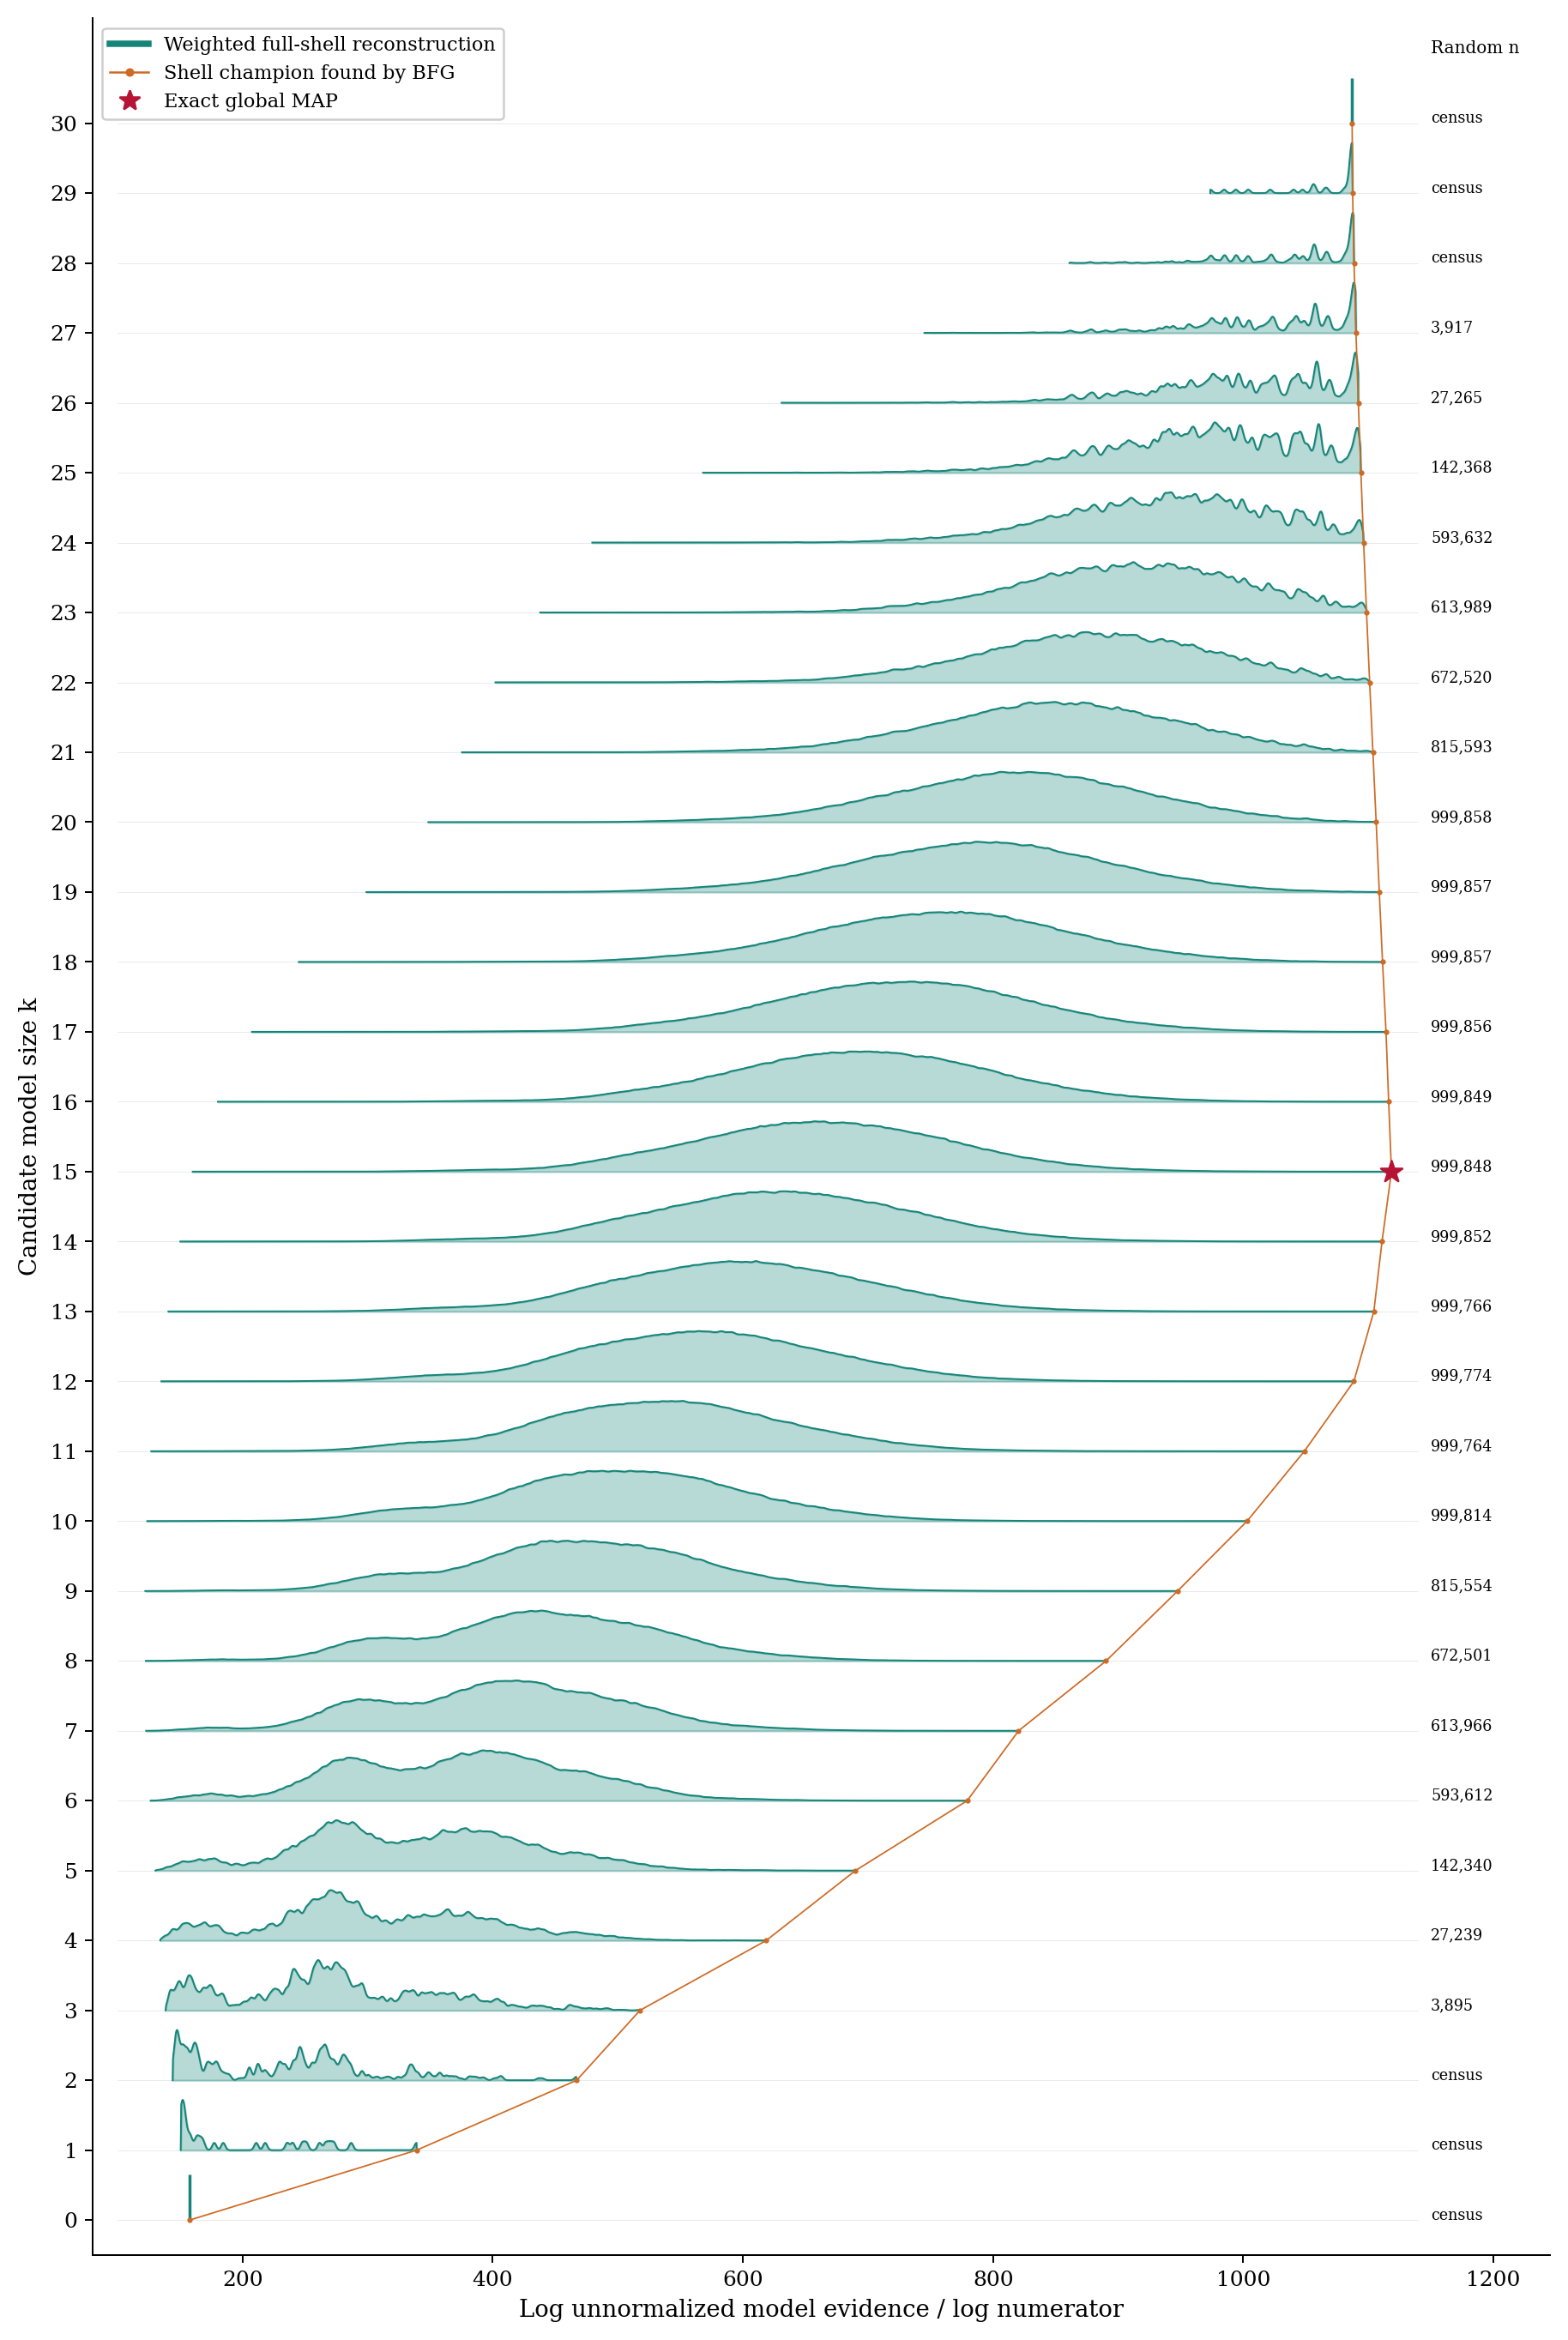

In [11]:
display(Image(filename=str(OUTPUT_DIR / "post_bfg_random_reticular_ridgeline.png")))


### Reconstruction against frozen exact shells

Teal shows the current-run monotone hybrid reconstruction and grey the frozen exact enumeration. Agreement in censused wings should be exact up to numerical/binning tolerance; remaining discrepancies are concentrated in large sampled shells.


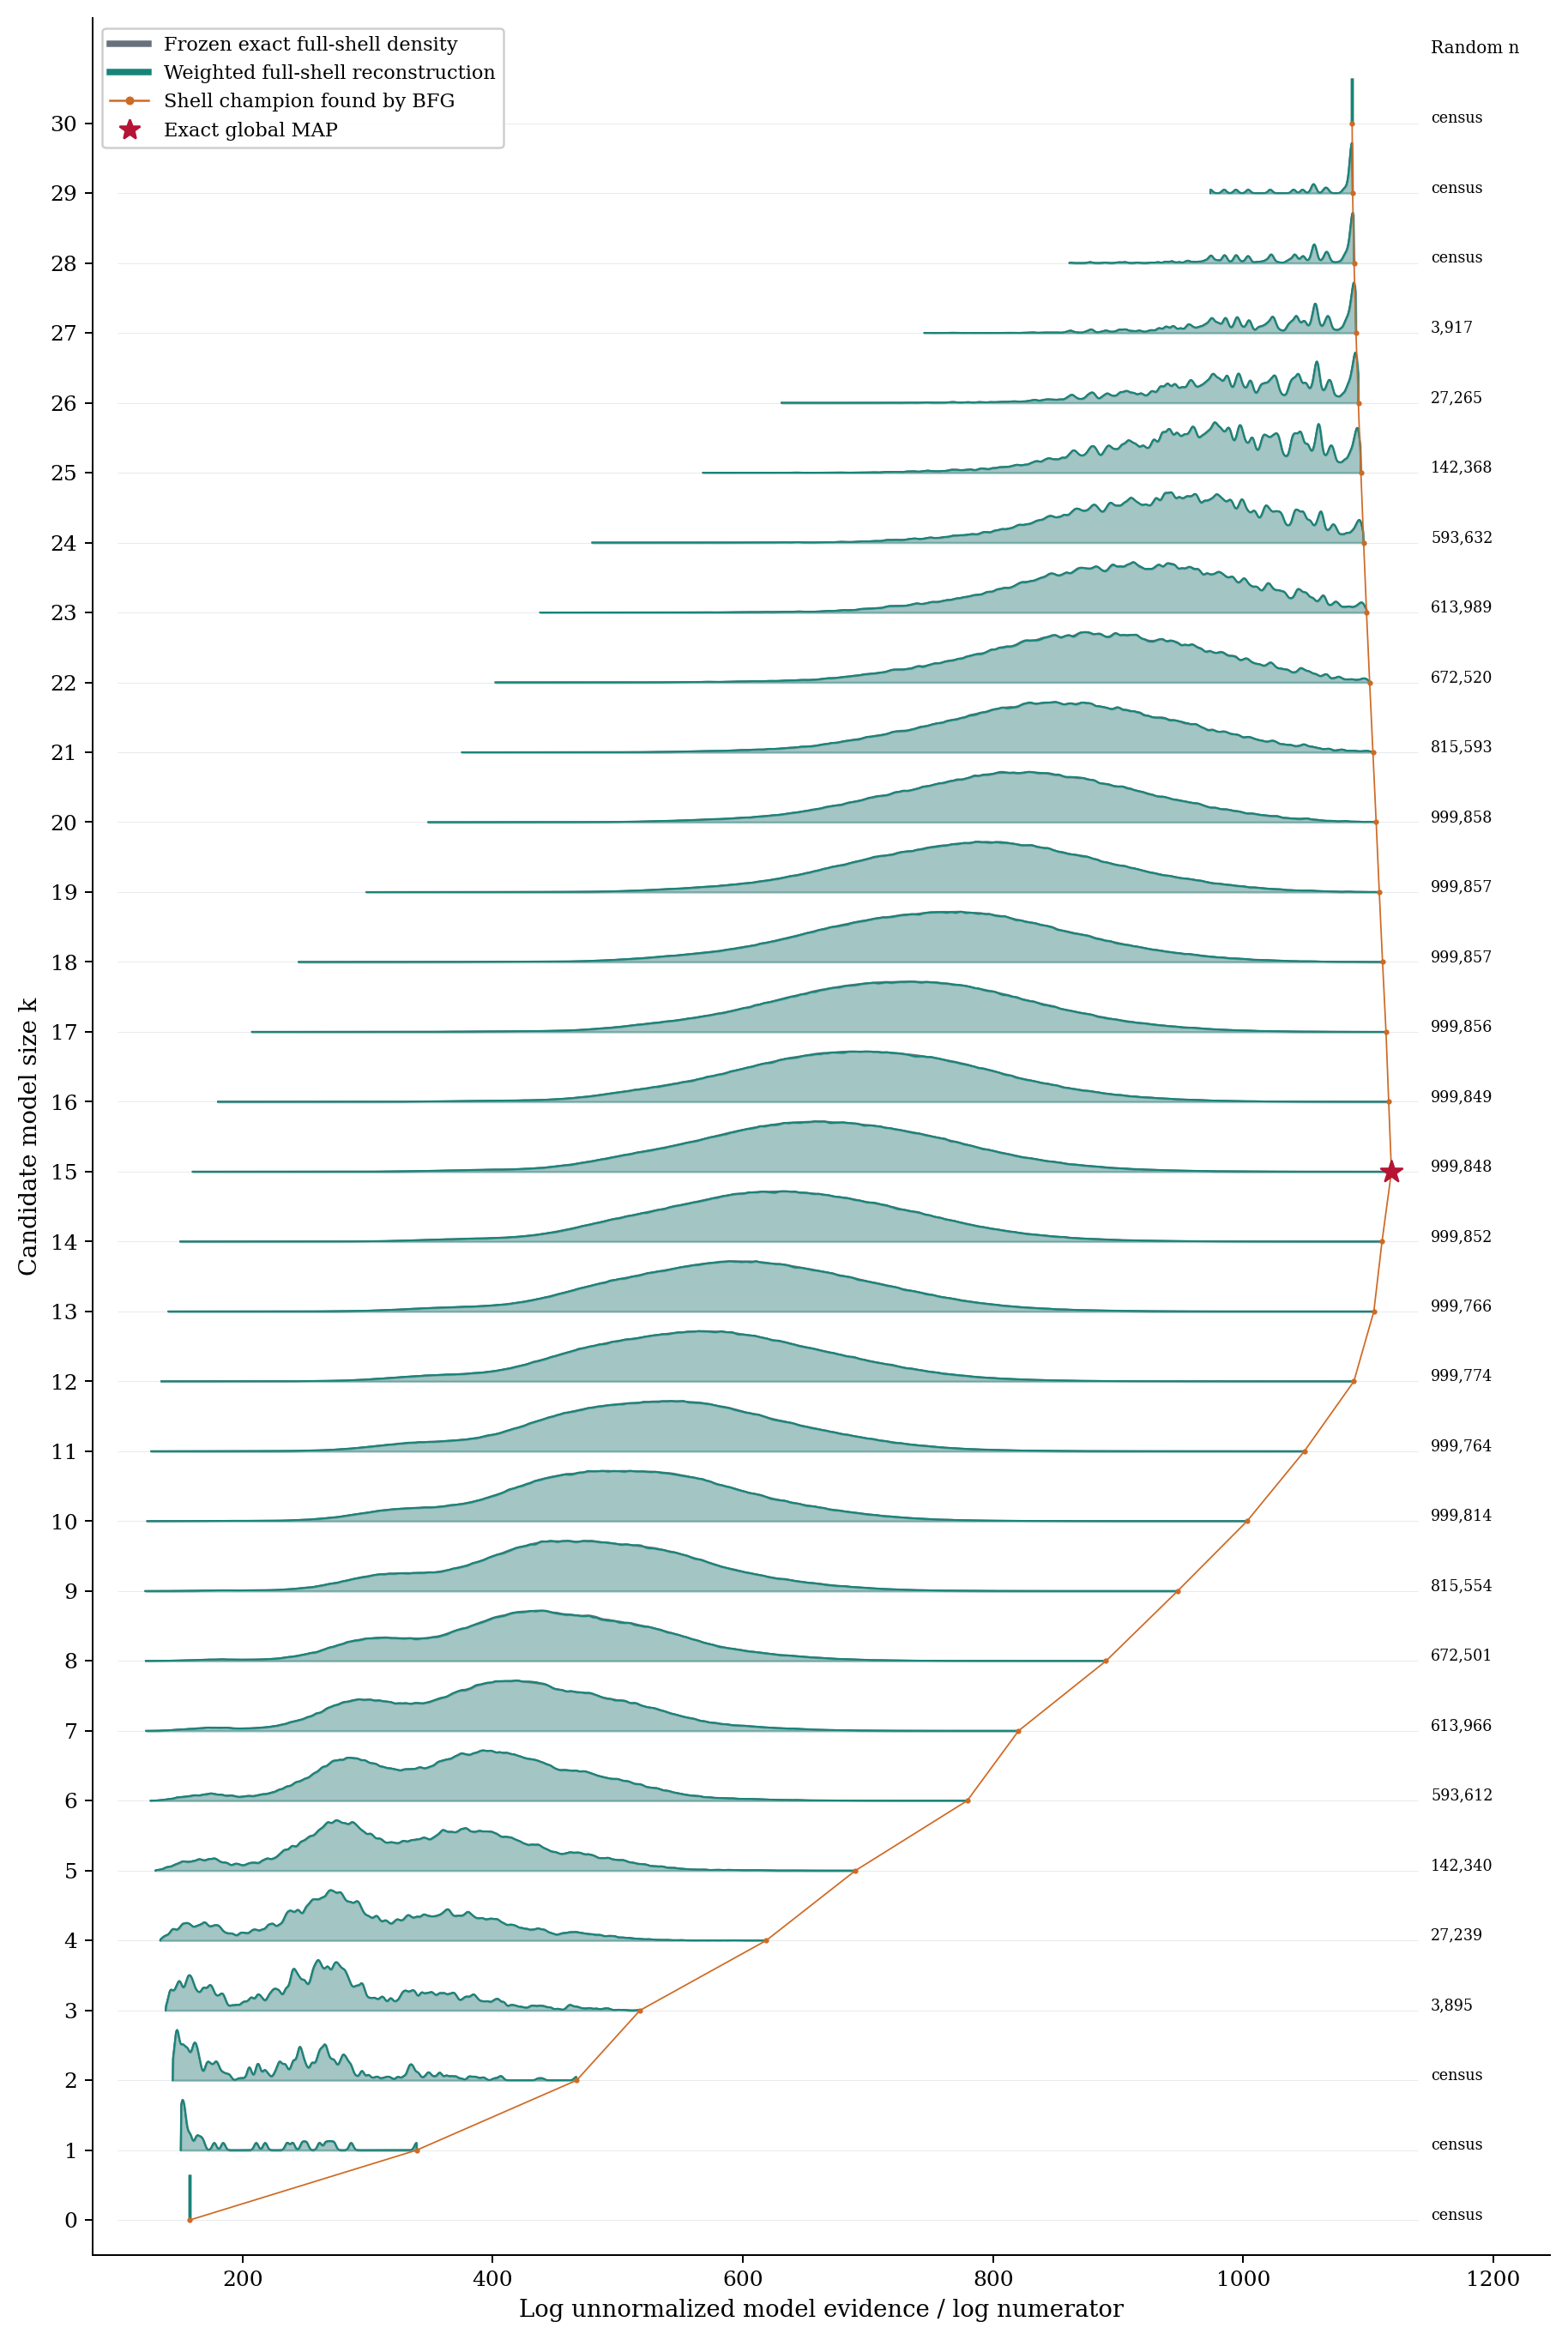

In [12]:
display(Image(filename=str(OUTPUT_DIR / "post_bfg_random_vs_exact_reticular_ridgeline.png")))


### Reconstruction error by shell and cap

KS measures the maximum CDF discrepancy; Wasserstein-1 measures integrated CDF discrepancy in score units. Smaller-cap runs reuse nested prefixes of the maximum-cap probability samples.


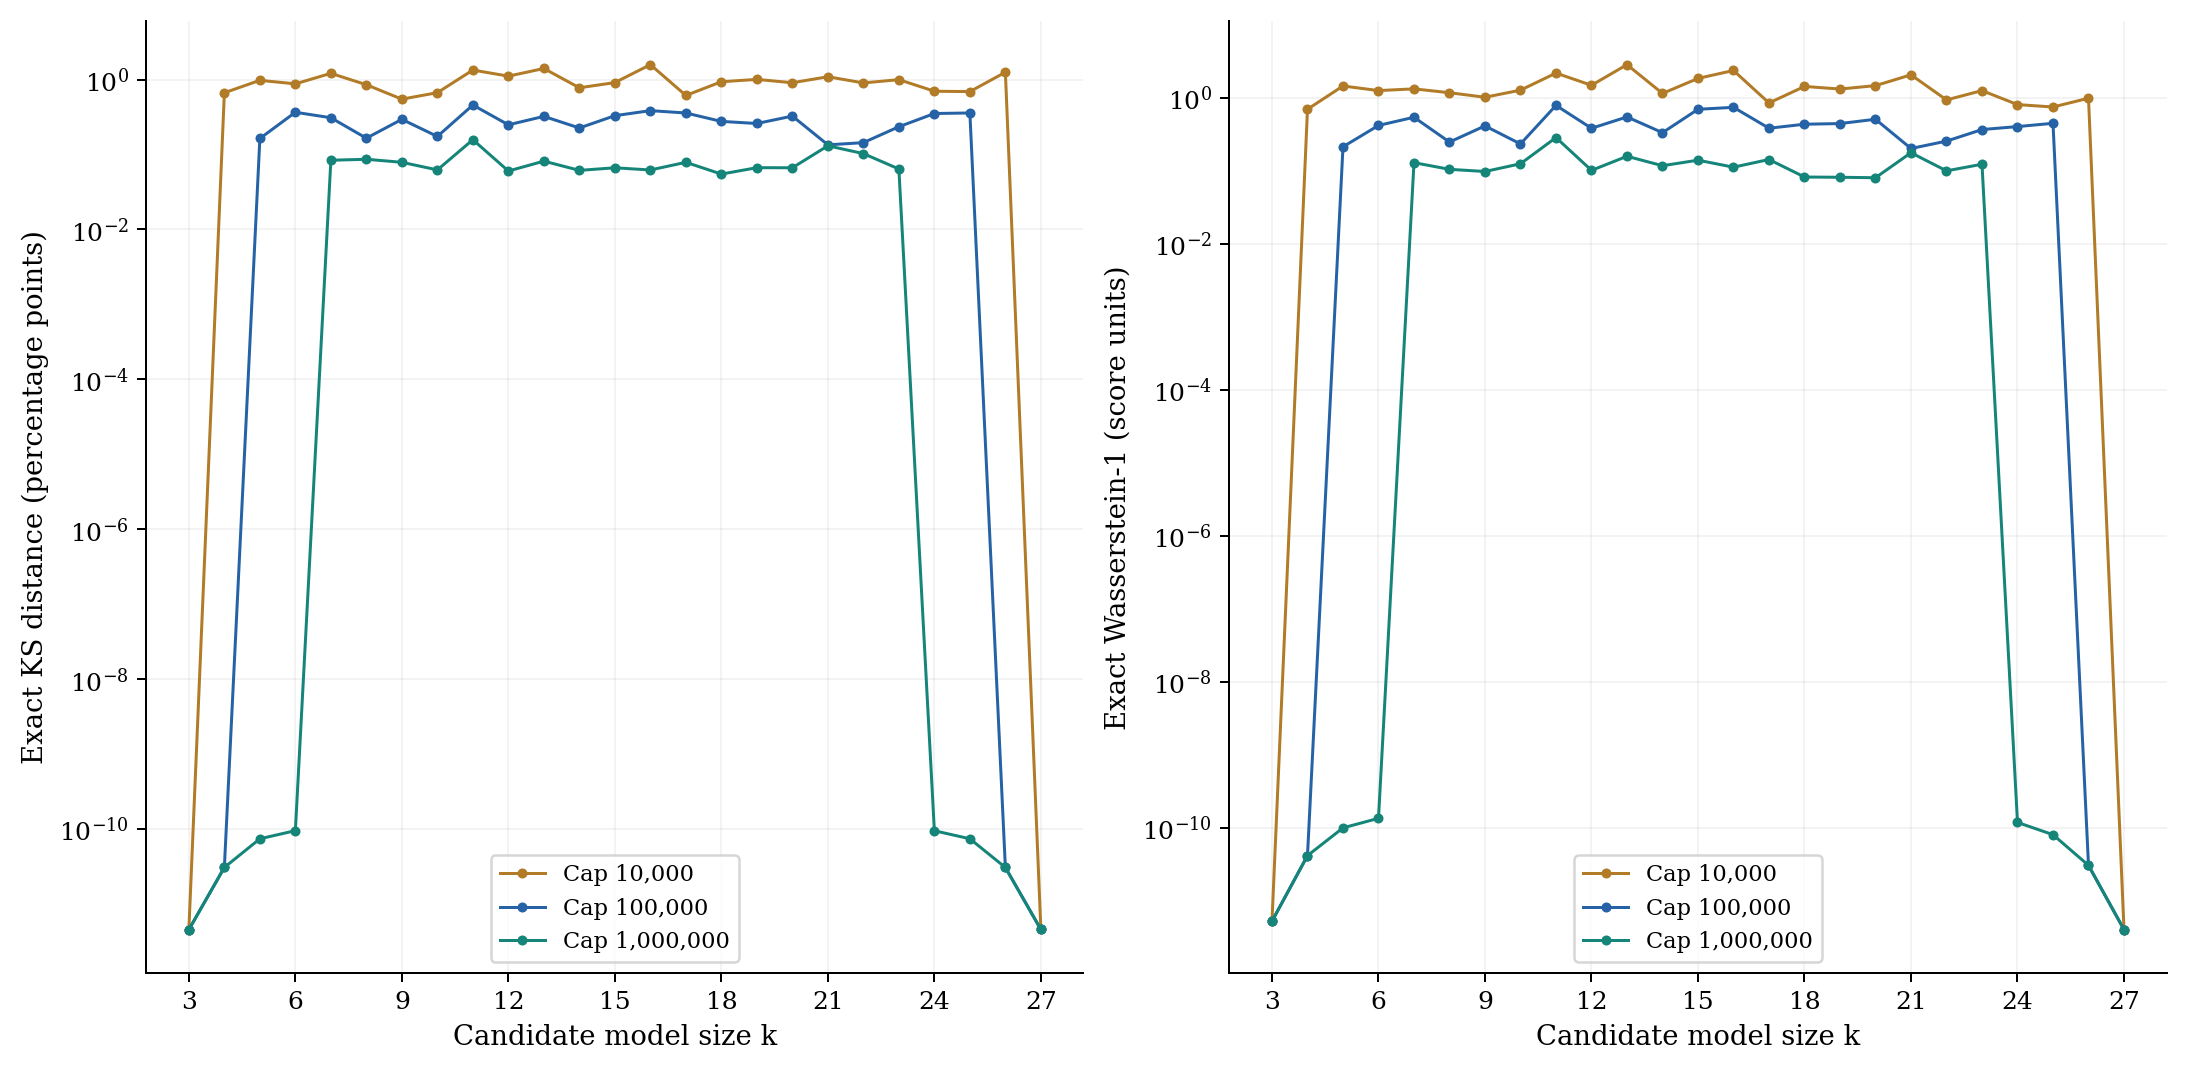

In [13]:
display(Image(filename=str(OUTPUT_DIR / "random_shell_error_by_k.png")))


### Distribution accuracy versus recovery cost

Only the maximum-cap workload was actually executed as a production recovery run. Smaller-cap compute times shown by the current-run summary are explicitly marked as shellwise proportional estimates from nested prefixes; the statistical errors are computed directly from those prefixes.


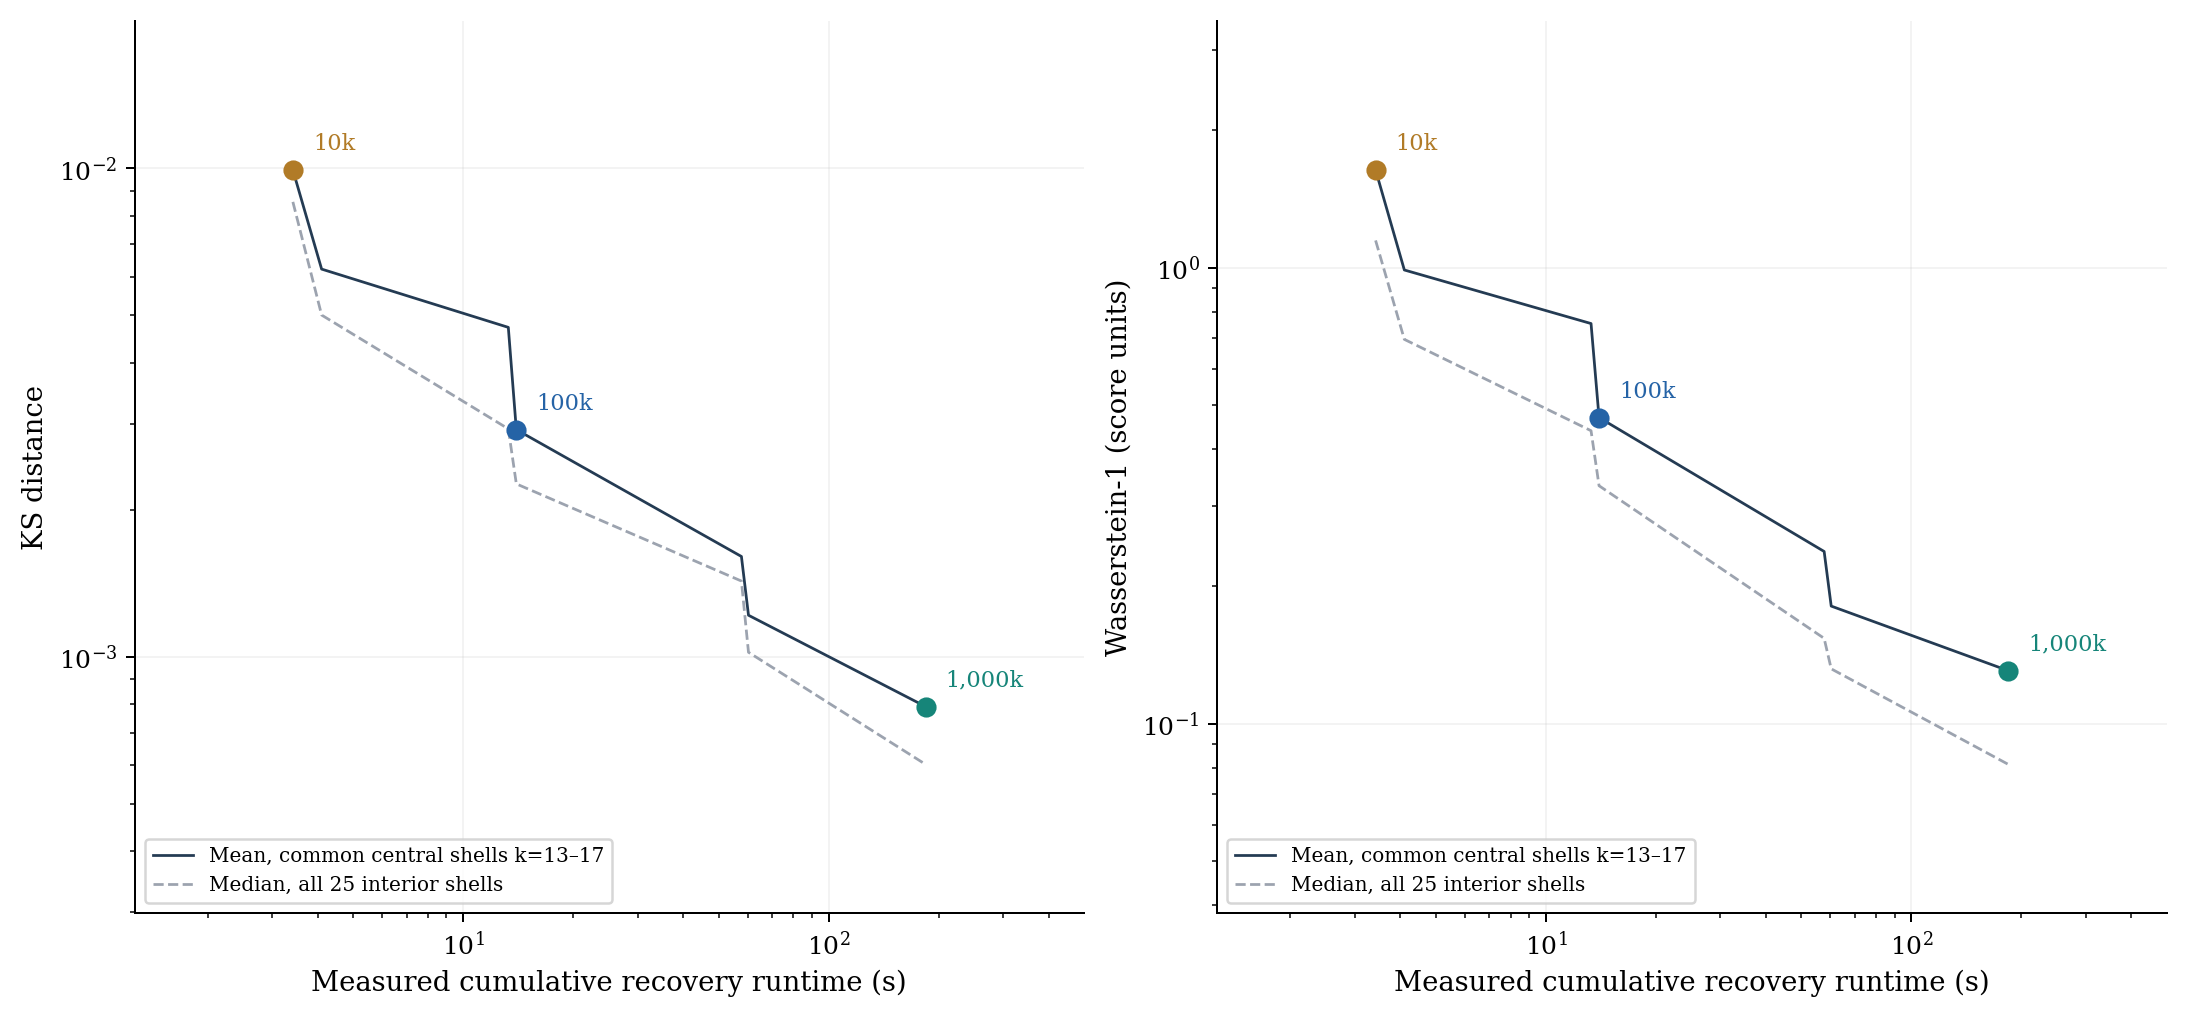

In [14]:
display(Image(filename=str(OUTPUT_DIR / "random_shell_cap_sensitivity.png")))


### Recovery fraction by shell

This figure now visualizes a **census → monotone ramp → cap** design, not a pure 1% rule. The evaluated target cannot collapse when moving from a censused wing into a larger shell; it increases monotonically until the cap binds.


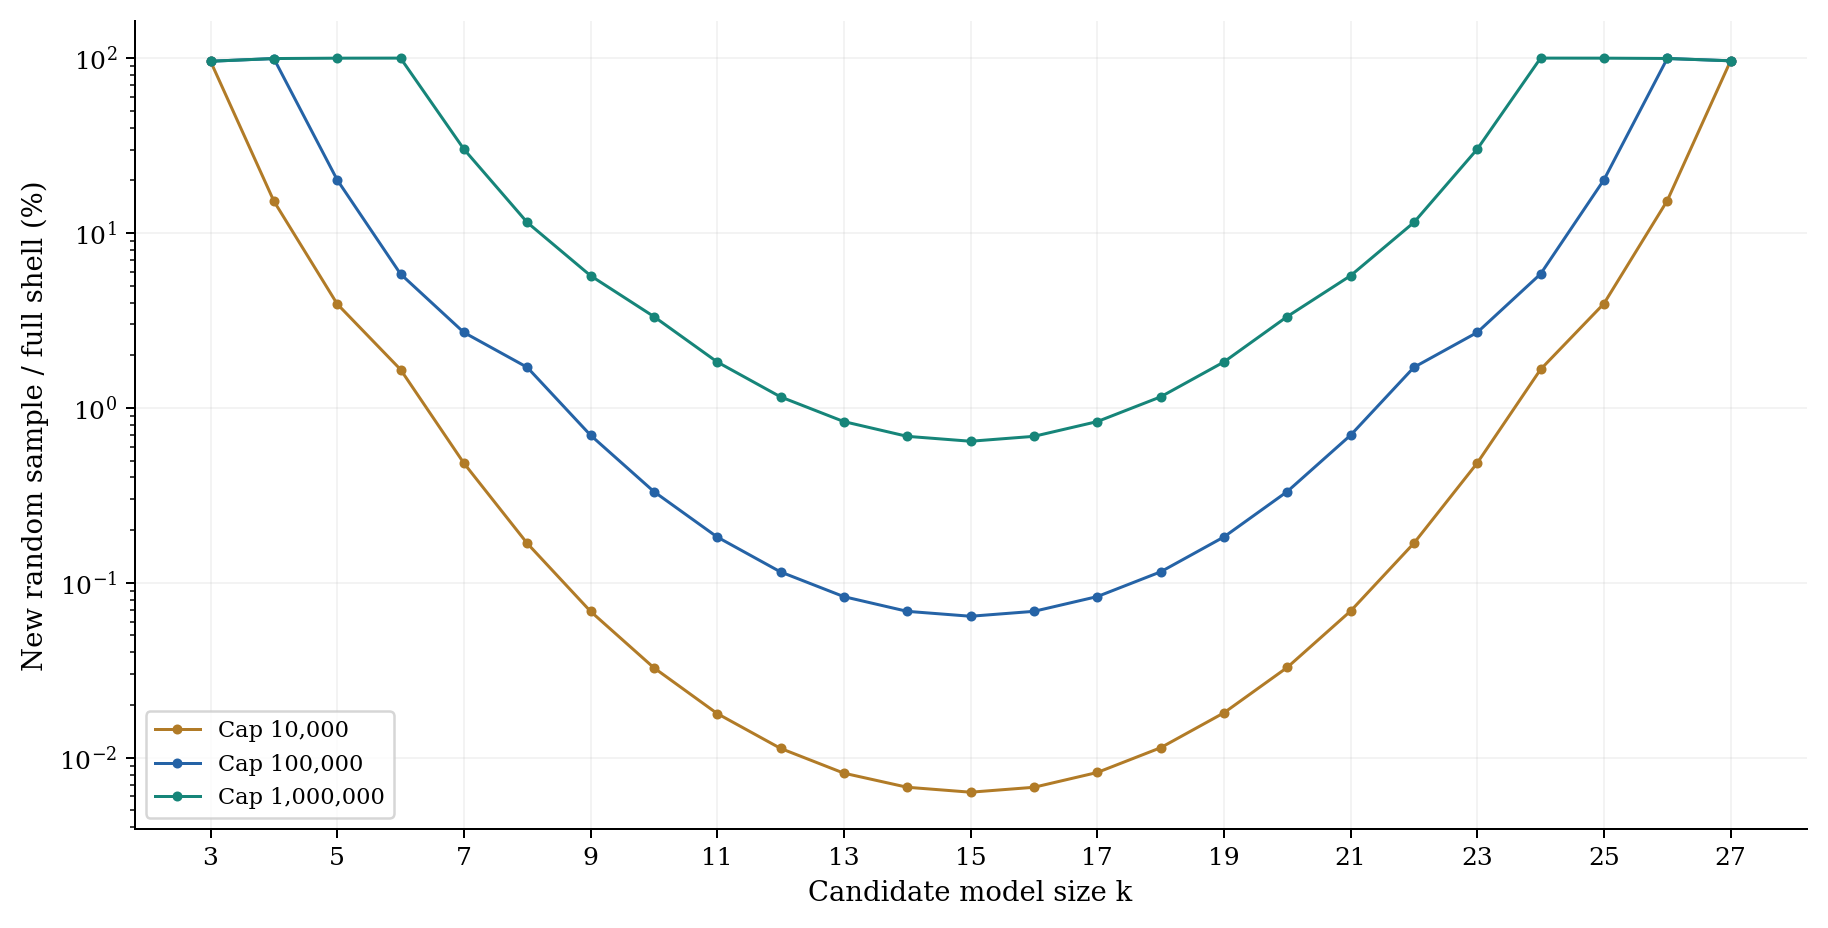

In [15]:
display(Image(filename=str(OUTPUT_DIR / "random_shell_sample_fraction_by_k.png")))


## 11. BFG budget sensitivity

The baseline production run uses 5,000 BFG evaluations, but that is not assumed to be optimal. This experiment runs independent searches at

$$
5k,\;10k,\;25k,\;50k,\;100k
$$

using the same seed and compares MAP recovery, Top-10/Top-100 overlap, best score, runtime, and throughput against the frozen exact p30 benchmark.

These runs are diagnostic only and do not overwrite the production `bfg_result`.


In [16]:
# ============================================================
# BFG BUDGET SENSITIVITY
#
# Purpose:
#   Measure the marginal value of increasing the BFG discovery
#   budget without modifying the bfg_result currently used by
#   the shell-recovery pipeline.
#
# Budgets:
#   5k, 10k, 25k, 50k, 100k
#
# Diagnostics against the frozen exact p30 benchmark:
#   - MAP recovery
#   - Top-10 overlap
#   - Top-100 overlap
#   - best log score
#   - unique models evaluated
#   - algorithm runtime
#   - wall runtime
#   - discovery throughput
# ============================================================

from pathlib import Path
from urllib.request import urlopen
import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

BFG_BUDGETS = [
    5_000,
    10_000,
    25_000,
    50_000,
    100_000,
]

BFG_SENSITIVITY_SEED = 12345
BFG_SENSITIVITY_DEVICE = "auto"

BFG_SENSITIVITY_PATH = (
    OUTPUT_DIR
    / "BFG_BUDGET_SENSITIVITY.csv"
)

BFG_SENSITIVITY_FIGURE = (
    OUTPUT_DIR
    / "BFG_BUDGET_SENSITIVITY.png"
)


# ------------------------------------------------------------
# Ensure the small exact-reference files needed here exist
# ------------------------------------------------------------

EXACT_REF_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

BASE_REFERENCE_URL = (
    "https://raw.githubusercontent.com/"
    "Favioleiva/gpubma/main/"
    "benchmark/exact_p30/reference/"
)

required_reference_files = [
    "exact_map.json",
    "exact_top10_models.csv",
    "exact_top100_models.csv",
]

for filename in required_reference_files:

    path = (
        EXACT_REF_DIR
        / filename
    )

    if not path.is_file():

        print(
            "Downloading:",
            filename,
        )

        with urlopen(
            BASE_REFERENCE_URL + filename,
            timeout=90,
        ) as response:

            path.write_bytes(
                response.read()
            )


# ------------------------------------------------------------
# Load exact MAP
# ------------------------------------------------------------

with open(
    EXACT_REF_DIR / "exact_map.json",
    "r",
    encoding="utf-8",
) as f:

    exact_map = json.load(f)


def extract_model_id_from_mapping(mapping):

    candidates = [
        "model_id",
        "model",
        "id",
        "mask",
    ]

    for key in candidates:

        if key in mapping:

            return int(
                mapping[key]
            )

    raise KeyError(
        "Could not identify the model-ID field "
        "in exact_map.json. "
        f"Available keys: {list(mapping.keys())}"
    )


EXACT_MAP_ID = (
    extract_model_id_from_mapping(
        exact_map
    )
)


# ------------------------------------------------------------
# Load exact Top-10 and Top-100
# ------------------------------------------------------------

exact_top10_df = pd.read_csv(
    EXACT_REF_DIR
    / "exact_top10_models.csv"
)

exact_top100_df = pd.read_csv(
    EXACT_REF_DIR
    / "exact_top100_models.csv"
)


def detect_model_id_column(df):

    candidates = [
        "model_id",
        "model",
        "id",
        "mask",
    ]

    for column in candidates:

        if column in df.columns:

            return column

    raise KeyError(
        "Could not identify model-ID column. "
        f"Available columns: {df.columns.tolist()}"
    )


top10_id_col = detect_model_id_column(
    exact_top10_df
)

top100_id_col = detect_model_id_column(
    exact_top100_df
)


EXACT_TOP10_IDS = set(
    exact_top10_df[
        top10_id_col
    ]
    .astype(np.int64)
    .head(10)
    .tolist()
)

EXACT_TOP100_IDS = set(
    exact_top100_df[
        top100_id_col
    ]
    .astype(np.int64)
    .head(100)
    .tolist()
)


assert (
    EXACT_MAP_ID
    in EXACT_TOP10_IDS
)

assert (
    EXACT_TOP10_IDS
    <= EXACT_TOP100_IDS
)


print(
    "Exact MAP model ID:",
    f"{EXACT_MAP_ID:,}",
)

print(
    "Exact Top-10 models:",
    len(EXACT_TOP10_IDS),
)

print(
    "Exact Top-100 models:",
    len(EXACT_TOP100_IDS),
)


# ------------------------------------------------------------
# Run independent BFG searches
#
# IMPORTANT:
# We deliberately DO NOT overwrite `bfg_result`.
# The recovery notebook can continue using its existing
# canonical BFG discovery run.
# ------------------------------------------------------------

sensitivity_rows = []

bfg_sensitivity_results = {}


print()
print("=" * 80)
print("BFG BUDGET SENSITIVITY")
print("=" * 80)


for budget in BFG_BUDGETS:

    print()
    print("-" * 80)

    print(
        "Requested BFG budget:",
        f"{budget:,}",
    )


    wall_start = (
        time.perf_counter()
    )


    result_i, metrics_i = fit_example(
        y,
        X,
        controls,
        budget=budget,
        seed=BFG_SENSITIVITY_SEED,
        device=BFG_SENSITIVITY_DEVICE,
    )


    wall_runtime_s = (
        time.perf_counter()
        - wall_start
    )


    # Keep the result available for inspection
    # without touching the canonical bfg_result.
    bfg_sensitivity_results[
        budget
    ] = result_i


    # --------------------------------------------------------
    # Evaluated model IDs
    # --------------------------------------------------------

    records_i = pd.DataFrame(
        result_i.records
    )

    discovered_ids = set(
        records_i[
            "model_id"
        ]
        .astype(np.int64)
        .tolist()
    )


    evaluations = int(
        result_i.n_models_evaluated
    )


    # --------------------------------------------------------
    # Internal BFG algorithm runtime
    # --------------------------------------------------------

    algorithm_runtime_s = float(
        result_i.elapsed_seconds
    )


    models_per_s = (
        evaluations
        / algorithm_runtime_s
        if algorithm_runtime_s > 0
        else np.nan
    )


    # --------------------------------------------------------
    # Best discovered model
    # --------------------------------------------------------

    best_i = (
        result_i.best_model
    )

    best_model_id = int(
        best_i["model_id"]
    )

    best_k = int(
        best_i["model_size"]
    )

    best_log_score = float(
        best_i["log_score"]
    )


    # --------------------------------------------------------
    # Exact-reference diagnostics
    # --------------------------------------------------------

    map_found = (
        EXACT_MAP_ID
        in discovered_ids
    )

    top10_overlap = len(
        discovered_ids
        & EXACT_TOP10_IDS
    )

    top100_overlap = len(
        discovered_ids
        & EXACT_TOP100_IDS
    )


    top10_recall = (
        top10_overlap
        / 10.0
    )

    top100_recall = (
        top100_overlap
        / 100.0
    )


    # --------------------------------------------------------
    # Store
    # --------------------------------------------------------

    sensitivity_rows.append(
        {
            "budget_requested":
                int(budget),

            "evaluations":
                evaluations,

            "algorithm_runtime_s":
                algorithm_runtime_s,

            "wall_runtime_s":
                wall_runtime_s,

            "models_per_s":
                models_per_s,

            "best_model_id":
                best_model_id,

            "best_k":
                best_k,

            "best_log_score":
                best_log_score,

            "MAP_found":
                bool(map_found),

            "Top10_overlap":
                int(top10_overlap),

            "Top10_recall":
                float(top10_recall),

            "Top100_overlap":
                int(top100_overlap),

            "Top100_recall":
                float(top100_recall),
        }
    )


    print(
        f"Evaluated       : "
        f"{evaluations:,}"
    )

    print(
        f"Algorithm time  : "
        f"{algorithm_runtime_s:.3f} s"
    )

    print(
        f"Wall time       : "
        f"{wall_runtime_s:.3f} s"
    )

    print(
        f"Throughput      : "
        f"{models_per_s:,.0f} models/s"
    )

    print(
        f"Best model      : "
        f"{best_model_id:,}"
    )

    print(
        f"Best log score  : "
        f"{best_log_score:.6f}"
    )

    print(
        f"MAP found       : "
        f"{map_found}"
    )

    print(
        f"Top-10 overlap  : "
        f"{top10_overlap}/10"
    )

    print(
        f"Top-100 overlap : "
        f"{top100_overlap}/100"
    )


# ------------------------------------------------------------
# Results table
# ------------------------------------------------------------

bfg_budget_sensitivity = pd.DataFrame(
    sensitivity_rows
).sort_values(
    "budget_requested"
).reset_index(
    drop=True
)


# ------------------------------------------------------------
# Marginal gains relative to previous budget
# ------------------------------------------------------------

bfg_budget_sensitivity[
    "additional_evaluations"
] = (
    bfg_budget_sensitivity[
        "evaluations"
    ]
    .diff()
)

bfg_budget_sensitivity[
    "additional_Top10_hits"
] = (
    bfg_budget_sensitivity[
        "Top10_overlap"
    ]
    .diff()
)

bfg_budget_sensitivity[
    "additional_Top100_hits"
] = (
    bfg_budget_sensitivity[
        "Top100_overlap"
    ]
    .diff()
)

bfg_budget_sensitivity[
    "best_score_gain"
] = (
    bfg_budget_sensitivity[
        "best_log_score"
    ]
    .diff()
)


# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

bfg_budget_sensitivity.to_csv(
    BFG_SENSITIVITY_PATH,
    index=False,
)


print()
print("=" * 80)
print("SUMMARY")
print("=" * 80)

display(
    bfg_budget_sensitivity
)


print()
print(
    "Saved:",
    BFG_SENSITIVITY_PATH,
)


# ------------------------------------------------------------
# Compact diagnostic figure
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(9, 5.5)
)

ax.plot(
    bfg_budget_sensitivity[
        "budget_requested"
    ],
    bfg_budget_sensitivity[
        "Top10_recall"
    ] * 100,
    marker="o",
    label="Exact Top-10 recovered",
)

ax.plot(
    bfg_budget_sensitivity[
        "budget_requested"
    ],
    bfg_budget_sensitivity[
        "Top100_recall"
    ] * 100,
    marker="o",
    label="Exact Top-100 recovered",
)

ax.set_xscale(
    "log"
)

ax.set_xlabel(
    "BFG evaluation budget"
)

ax.set_ylabel(
    "Exact elite models recovered (%)"
)

ax.set_ylim(
    0,
    105,
)

ax.grid(
    True,
    alpha=0.25,
)

ax.legend()

fig.tight_layout()

fig.savefig(
    BFG_SENSITIVITY_FIGURE,
    dpi=180,
    bbox_inches="tight",
)

plt.show()


print(
    "Figure saved:",
    BFG_SENSITIVITY_FIGURE,
)


# ------------------------------------------------------------
# Identify first budget reaching useful milestones
# ------------------------------------------------------------

print()
print("=" * 80)
print("MILESTONES")
print("=" * 80)


def first_budget_where(mask):

    matched = (
        bfg_budget_sensitivity.loc[
            mask,
            "budget_requested",
        ]
    )

    if len(matched) == 0:
        return None

    return int(
        matched.iloc[0]
    )


first_map = first_budget_where(
    bfg_budget_sensitivity[
        "MAP_found"
    ]
)

first_top10_all = first_budget_where(
    bfg_budget_sensitivity[
        "Top10_overlap"
    ] >= 10
)

first_top100_50 = first_budget_where(
    bfg_budget_sensitivity[
        "Top100_overlap"
    ] >= 50
)

first_top100_90 = first_budget_where(
    bfg_budget_sensitivity[
        "Top100_overlap"
    ] >= 90
)


print(
    "First budget finding exact MAP:",
    (
        f"{first_map:,}"
        if first_map is not None
        else "not reached"
    ),
)

print(
    "First budget recovering all Top-10:",
    (
        f"{first_top10_all:,}"
        if first_top10_all is not None
        else "not reached"
    ),
)

print(
    "First budget recovering >=50% of Top-100:",
    (
        f"{first_top100_50:,}"
        if first_top100_50 is not None
        else "not reached"
    ),
)

print(
    "First budget recovering >=90% of Top-100:",
    (
        f"{first_top100_90:,}"
        if first_top100_90 is not None
        else "not reached"
    ),
)


print()
print(
    "NOTE: the canonical variable `bfg_result` "
    "was NOT modified."
)


Exact MAP model ID: 536,887,295
Exact Top-10 models: 10
Exact Top-100 models: 100

BFG BUDGET SENSITIVITY

--------------------------------------------------------------------------------
Requested BFG budget: 5,000
Candidate predictors p = 30
Full model universe = 1,073,741,824 models
BFG evaluation budget = 5,000 unique model evaluations
Maximum explored fraction = 0.000466%
Requested BUDGET: 5,000; actual unique evaluations: 5,000
Actual fraction evaluated: 0.000466%
BFG algorithm runtime: 0.225049 s; fit-call wall time: 0.259822 s
Evaluated       : 5,000
Algorithm time  : 0.225 s
Wall time       : 0.260 s
Throughput      : 22,217 models/s
Best model      : 536,887,295
Best log score  : 1118.521781
MAP found       : True
Top-10 overlap  : 10/10
Top-100 overlap : 98/100

--------------------------------------------------------------------------------
Requested BFG budget: 10,000
Candidate predictors p = 30
Full model universe = 1,073,741,824 models
BFG evaluation budget = 10,000 uniq

,budget_requested,evaluations,algorithm_runtime_s,wall_runtime_s,models_per_s,best_model_id,best_k,best_log_score,MAP_found,Top10_overlap,Top10_recall,Top100_overlap,Top100_recall,additional_evaluations,additional_Top10_hits,additional_Top100_hits,best_score_gain
0,5000,5000,0.225049,0.260022,22217.397196,536887295,15,1118.521781,True,10,1.0,98,0.98,NaN,NaN,NaN,NaN
1,10000,10000,0.260103,0.316169,38446.338554,536887295,15,1118.521781,True,10,1.0,98,0.98,5000.0,0.0,0.0,0.0
2,25000,25000,0.658328,0.806416,37974.976942,536887295,15,1118.521781,True,10,1.0,100,1.00,15000.0,0.0,2.0,0.0
3,50000,50000,0.741000,1.279516,67476.339739,536887295,15,1118.521781,True,10,1.0,100,1.00,25000.0,0.0,0.0,0.0
4,100000,100000,2.215269,3.539754,45141.247836,536887295,15,1118.521781,True,10,1.0,99,0.99,50000.0,0.0,-1.0,0.0



Saved: /content/outputs/shell_recovery/BFG_BUDGET_SENSITIVITY.csv
Figure saved: /content/outputs/shell_recovery/BFG_BUDGET_SENSITIVITY.png

MILESTONES
First budget finding exact MAP: 5,000
First budget recovering all Top-10: 5,000
First budget recovering >=50% of Top-100: 5,000
First budget recovering >=90% of Top-100: 5,000

NOTE: the canonical variable `bfg_result` was NOT modified.


## 12. Multi-seed elite-frontier stability

For larger model spaces the exhaustive Top-100 will be unknown. The operational alternative is therefore to study whether the **right-hand elite frontier** stabilizes across independent BFG trajectories.

At a fixed budget, this experiment tracks:

- recurrence of the MAP and elite models,
- new models that beat the previous Top-100 cutoff,
- Jaccard stability of the cumulative elite set,
- cumulative recovery of the exact p30 Top-100.

The exact p30 benchmark lets us calibrate internal stability diagnostics that can later be used in p90/p100, where exhaustive truth is unavailable.


In [17]:
# ============================================================
# BFG MULTI-SEED ELITE-STABILITY EXPERIMENT
#
# Calibration experiment for the "right-tail recurrence" idea.
#
# Fixed BFG budget, many independent seeds:
#
#   - Does the MAP recur?
#   - Do the same elite models recur?
#   - How quickly does the cumulative Top-K stabilize?
#   - How many genuinely new models can still displace the
#     incumbent Top-K?
#   - In canonical p30, does that stabilized elite archive
#     coincide with the TRUE exhaustive Top-100?
#
# IMPORTANT:
#   This cell DOES NOT overwrite the canonical `bfg_result`.
# ============================================================

from pathlib import Path
import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

MULTISEED_BUDGET = 25_000

MULTISEED_SEEDS = list(
    range(1, 21)
)

ELITE_K = 100

MULTISEED_DIR = (
    OUTPUT_DIR
    / "bfg_multiseed"
)

MULTISEED_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ------------------------------------------------------------
# Exact p30 reference
#
# Reuse objects from the previous budget-sensitivity cell
# when available. Otherwise load them from disk.
# ------------------------------------------------------------

if "EXACT_MAP_ID" not in globals():

    with open(
        EXACT_REF_DIR / "exact_map.json",
        "r",
        encoding="utf-8",
    ) as f:

        _exact_map = json.load(f)

    for _key in [
        "model_id",
        "model",
        "id",
        "mask",
    ]:
        if _key in _exact_map:
            EXACT_MAP_ID = int(
                _exact_map[_key]
            )
            break
    else:
        raise KeyError(
            "Could not determine model ID "
            "from exact_map.json."
        )


if "EXACT_TOP10_IDS" not in globals():

    _top10_df = pd.read_csv(
        EXACT_REF_DIR
        / "exact_top10_models.csv"
    )

    _id_col = next(
        c
        for c in [
            "model_id",
            "model",
            "id",
            "mask",
        ]
        if c in _top10_df.columns
    )

    EXACT_TOP10_IDS = set(
        _top10_df[
            _id_col
        ]
        .astype(np.int64)
        .head(10)
    )


if "EXACT_TOP100_IDS" not in globals():

    _top100_df = pd.read_csv(
        EXACT_REF_DIR
        / "exact_top100_models.csv"
    )

    _id_col = next(
        c
        for c in [
            "model_id",
            "model",
            "id",
            "mask",
        ]
        if c in _top100_df.columns
    )

    EXACT_TOP100_IDS = set(
        _top100_df[
            _id_col
        ]
        .astype(np.int64)
        .head(100)
    )


print(
    "Fixed BFG budget:",
    f"{MULTISEED_BUDGET:,}",
)

print(
    "Independent seeds:",
    len(MULTISEED_SEEDS),
)

print(
    "Elite archive size:",
    ELITE_K,
)

print(
    "Exact MAP:",
    f"{EXACT_MAP_ID:,}",
)


# ============================================================
# Helpers
# ============================================================

def jaccard(a, b):

    a = set(a)
    b = set(b)

    if not a and not b:
        return 1.0

    return (
        len(a & b)
        / len(a | b)
    )


def top_k_from_archive(
    archive,
    k,
):

    if len(archive) == 0:
        return pd.DataFrame()

    df = pd.DataFrame(
        archive.values()
    )

    return (
        df
        .sort_values(
            [
                "log_score",
                "model_id",
            ],
            ascending=[
                False,
                True,
            ],
        )
        .head(k)
        .reset_index(
            drop=True
        )
    )


# ============================================================
# Persistent cumulative archive
#
# archive[model_id] contains:
#
#   model_id
#   model_size
#   log_score
#   first_seed
#   first_run
#   n_runs_seen
#
# n_runs_seen measures independent-run recurrence.
# ============================================================

archive = {}

run_rows = []

previous_elite_ids = set()

previous_best_score = -np.inf

previous_cutoff = -np.inf

all_run_results = {}


print()
print("=" * 88)
print("BFG MULTI-SEED ELITE-STABILITY EXPERIMENT")
print("=" * 88)


for run_number, seed in enumerate(
    MULTISEED_SEEDS,
    start=1,
):

    print()
    print("-" * 88)

    print(
        f"Run {run_number:02d}/"
        f"{len(MULTISEED_SEEDS)} "
        f"| seed={seed}"
    )


    # --------------------------------------------------------
    # Independent BFG run
    # --------------------------------------------------------

    wall_start = (
        time.perf_counter()
    )

    result_i, metrics_i = fit_example(
        y,
        X,
        controls,
        budget=MULTISEED_BUDGET,
        seed=seed,
        device="auto",
    )

    wall_s = (
        time.perf_counter()
        - wall_start
    )

    all_run_results[
        seed
    ] = result_i


    records_i = pd.DataFrame(
        result_i.records
    ).copy()


    records_i[
        "model_id"
    ] = (
        records_i[
            "model_id"
        ]
        .astype(np.int64)
    )


    # --------------------------------------------------------
    # Rank current run by score
    # --------------------------------------------------------

    ranked_i = (
        records_i
        .sort_values(
            [
                "log_score",
                "model_id",
            ],
            ascending=[
                False,
                True,
            ],
        )
        .reset_index(
            drop=True
        )
    )


    run_elite = (
        ranked_i
        .head(ELITE_K)
    )

    run_elite_ids = set(
        run_elite[
            "model_id"
        ].tolist()
    )


    run_best_id = int(
        ranked_i.iloc[0][
            "model_id"
        ]
    )

    run_best_score = float(
        ranked_i.iloc[0][
            "log_score"
        ]
    )


    # --------------------------------------------------------
    # Exact p30 diagnostics for THIS independent run
    # --------------------------------------------------------

    run_all_ids = set(
        records_i[
            "model_id"
        ].tolist()
    )

    run_map_found = (
        EXACT_MAP_ID
        in run_all_ids
    )

    run_top10_overlap = len(
        run_all_ids
        & EXACT_TOP10_IDS
    )

    run_top100_overlap = len(
        run_all_ids
        & EXACT_TOP100_IDS
    )


    # --------------------------------------------------------
    # Before updating archive:
    #
    # Count genuinely NEW models in this run whose score is
    # high enough to beat the previous cumulative Top-K cutoff.
    #
    # This is one of the key "right-tail saturation" metrics.
    # --------------------------------------------------------

    previously_seen_ids = set(
        archive.keys()
    )

    new_records = (
        records_i[
            ~records_i[
                "model_id"
            ].isin(
                previously_seen_ids
            )
        ]
        .copy()
    )


    if run_number == 1:

        new_models_above_old_cutoff = np.nan

    else:

        new_models_above_old_cutoff = int(
            (
                new_records[
                    "log_score"
                ]
                > previous_cutoff
            ).sum()
        )


    # --------------------------------------------------------
    # Update cumulative archive
    #
    # Important:
    # n_runs_seen counts recurrence across independent runs,
    # not repeated internal visits within one run.
    # --------------------------------------------------------

    seen_this_run = set()


    for rec in records_i.itertuples(
        index=False
    ):

        model_id = int(
            rec.model_id
        )

        score = float(
            rec.log_score
        )

        model_size = int(
            rec.model_size
        )


        if model_id not in archive:

            archive[
                model_id
            ] = {
                "model_id":
                    model_id,

                "model_size":
                    model_size,

                "log_score":
                    score,

                "first_seed":
                    seed,

                "first_run":
                    run_number,

                "n_runs_seen":
                    0,
            }


        # Scores should be deterministic for a model.
        # Keep maximum defensively.
        if (
            score
            > archive[
                model_id
            ][
                "log_score"
            ]
        ):

            archive[
                model_id
            ][
                "log_score"
            ] = score


        if (
            model_id
            not in seen_this_run
        ):

            archive[
                model_id
            ][
                "n_runs_seen"
            ] += 1

            seen_this_run.add(
                model_id
            )


    # --------------------------------------------------------
    # Cumulative Top-K after this run
    # --------------------------------------------------------

    cumulative_elite = (
        top_k_from_archive(
            archive,
            ELITE_K,
        )
    )

    cumulative_elite_ids = set(
        cumulative_elite[
            "model_id"
        ].tolist()
    )


    cumulative_best_score = float(
        cumulative_elite.iloc[0][
            "log_score"
        ]
    )

    cumulative_cutoff = float(
        cumulative_elite.iloc[-1][
            "log_score"
        ]
    )


    # --------------------------------------------------------
    # Stability vs previous cumulative elite
    # --------------------------------------------------------

    if run_number == 1:

        elite_jaccard = np.nan

        elite_retained = np.nan

        elite_new_entries = np.nan

        elite_displaced = np.nan

        best_score_gain = np.nan

        cutoff_gain = np.nan

    else:

        elite_jaccard = jaccard(
            previous_elite_ids,
            cumulative_elite_ids,
        )

        elite_retained = len(
            previous_elite_ids
            & cumulative_elite_ids
        )

        elite_new_entries = len(
            cumulative_elite_ids
            - previous_elite_ids
        )

        elite_displaced = len(
            previous_elite_ids
            - cumulative_elite_ids
        )

        best_score_gain = (
            cumulative_best_score
            - previous_best_score
        )

        cutoff_gain = (
            cumulative_cutoff
            - previous_cutoff
        )


    # --------------------------------------------------------
    # Exact overlap of cumulative archive
    # --------------------------------------------------------

    cumulative_map_found = (
        EXACT_MAP_ID
        in cumulative_elite_ids
    )

    cumulative_top10_overlap = len(
        cumulative_elite_ids
        & EXACT_TOP10_IDS
    )

    cumulative_top100_overlap = len(
        cumulative_elite_ids
        & EXACT_TOP100_IDS
    )


    # --------------------------------------------------------
    # Recurrence of current cumulative Top-K
    # --------------------------------------------------------

    elite_recurrences = (
        cumulative_elite[
            "n_runs_seen"
        ]
        .to_numpy()
    )

    elite_mean_recurrence = float(
        np.mean(
            elite_recurrences
        )
    )

    elite_min_recurrence = int(
        np.min(
            elite_recurrences
        )
    )

    elite_recurrence_ge_half = int(
        (
            elite_recurrences
            >= np.ceil(
                run_number / 2
            )
        ).sum()
    )


    # --------------------------------------------------------
    # Store run diagnostics
    # --------------------------------------------------------

    run_rows.append(
        {
            "run":
                run_number,

            "seed":
                seed,

            "budget":
                MULTISEED_BUDGET,

            "unique_evaluations":
                len(records_i),

            "algorithm_runtime_s":
                float(
                    result_i.elapsed_seconds
                ),

            "wall_runtime_s":
                wall_s,

            "run_best_model_id":
                run_best_id,

            "run_best_log_score":
                run_best_score,

            "run_MAP_found":
                run_map_found,

            "run_Top10_overlap":
                run_top10_overlap,

            "run_Top100_overlap":
                run_top100_overlap,

            "archive_unique_models":
                len(archive),

            "new_unique_models":
                len(new_records),

            "new_models_above_previous_TopK_cutoff":
                new_models_above_old_cutoff,

            "cumulative_best_log_score":
                cumulative_best_score,

            "cumulative_TopK_cutoff":
                cumulative_cutoff,

            "best_score_gain":
                best_score_gain,

            "cutoff_gain":
                cutoff_gain,

            "elite_retained":
                elite_retained,

            "elite_new_entries":
                elite_new_entries,

            "elite_displaced":
                elite_displaced,

            "elite_jaccard":
                elite_jaccard,

            "cumulative_MAP_found":
                cumulative_map_found,

            "cumulative_Top10_overlap":
                cumulative_top10_overlap,

            "cumulative_Top100_overlap":
                cumulative_top100_overlap,

            "elite_mean_runs_seen":
                elite_mean_recurrence,

            "elite_min_runs_seen":
                elite_min_recurrence,

            "elite_seen_in_at_least_half_runs":
                elite_recurrence_ge_half,
        }
    )


    # --------------------------------------------------------
    # Console summary
    # --------------------------------------------------------

    print(
        f"Run Top-100 exact overlap       : "
        f"{run_top100_overlap}/100"
    )

    print(
        f"Cumulative unique models       : "
        f"{len(archive):,}"
    )

    print(
        f"Cumulative exact Top-100       : "
        f"{cumulative_top100_overlap}/100"
    )

    print(
        f"Cumulative elite cutoff        : "
        f"{cumulative_cutoff:.6f}"
    )


    if run_number > 1:

        print(
            f"New models beating old cutoff  : "
            f"{new_models_above_old_cutoff:,}"
        )

        print(
            f"New Top-{ELITE_K} entrants          : "
            f"{elite_new_entries}"
        )

        print(
            f"Elite Jaccard                  : "
            f"{elite_jaccard:.6f}"
        )


    # --------------------------------------------------------
    # Advance state
    # --------------------------------------------------------

    previous_elite_ids = (
        cumulative_elite_ids.copy()
    )

    previous_best_score = (
        cumulative_best_score
    )

    previous_cutoff = (
        cumulative_cutoff
    )


# ============================================================
# Run-level results
# ============================================================

multiseed_summary = pd.DataFrame(
    run_rows
)


# ============================================================
# Final global archive
# ============================================================

archive_df = (
    pd.DataFrame(
        archive.values()
    )
    .sort_values(
        [
            "log_score",
            "model_id",
        ],
        ascending=[
            False,
            True,
        ],
    )
    .reset_index(
        drop=True
    )
)


archive_df[
    "global_archive_rank"
] = (
    np.arange(
        1,
        len(archive_df) + 1,
    )
)


archive_df[
    "run_frequency"
] = (
    archive_df[
        "n_runs_seen"
    ]
    / len(
        MULTISEED_SEEDS
    )
)


final_elite = (
    archive_df
    .head(
        ELITE_K
    )
    .copy()
)


final_elite[
    "is_exact_Top10"
] = (
    final_elite[
        "model_id"
    ]
    .isin(
        EXACT_TOP10_IDS
    )
)


final_elite[
    "is_exact_Top100"
] = (
    final_elite[
        "model_id"
    ]
    .isin(
        EXACT_TOP100_IDS
    )
)


# ============================================================
# Save outputs
# ============================================================

summary_path = (
    MULTISEED_DIR
    / "BFG_MULTI_SEED_STABILITY.csv"
)

archive_path = (
    MULTISEED_DIR
    / "BFG_MULTI_SEED_GLOBAL_ARCHIVE.csv"
)

elite_path = (
    MULTISEED_DIR
    / "BFG_MULTI_SEED_FINAL_TOP100.csv"
)


multiseed_summary.to_csv(
    summary_path,
    index=False,
)

archive_df.to_csv(
    archive_path,
    index=False,
)

final_elite.to_csv(
    elite_path,
    index=False,
)


# ============================================================
# Final diagnostics
# ============================================================

final_exact_top100 = int(
    final_elite[
        "is_exact_Top100"
    ].sum()
)

final_exact_top10 = int(
    final_elite[
        "is_exact_Top10"
    ].sum()
)

final_map_found = bool(
    EXACT_MAP_ID
    in set(
        final_elite[
            "model_id"
        ]
    )
)


print()
print("=" * 88)
print("FINAL MULTI-SEED DIAGNOSTICS")
print("=" * 88)

print(
    "Independent runs:",
    len(MULTISEED_SEEDS),
)

print(
    "Total raw BFG evaluations:",
    f"{MULTISEED_BUDGET * len(MULTISEED_SEEDS):,}",
)

print(
    "Distinct models in union archive:",
    f"{len(archive_df):,}",
)

print()

print(
    "MAP in final consensus elite:",
    final_map_found,
)

print(
    "Exact Top-10 in final elite:",
    f"{final_exact_top10}/10",
)

print(
    "Exact Top-100 in final elite:",
    f"{final_exact_top100}/100",
)

print()

print(
    "Final Top-100 cutoff:",
    f"{final_elite.iloc[-1]['log_score']:.6f}",
)

print(
    "Minimum recurrence among final Top-100:",
    f"{int(final_elite['n_runs_seen'].min())}/"
    f"{len(MULTISEED_SEEDS)}",
)

print(
    "Median recurrence among final Top-100:",
    f"{float(final_elite['n_runs_seen'].median()):.1f}/"
    f"{len(MULTISEED_SEEDS)}",
)

print(
    "Mean recurrence among final Top-100:",
    f"{float(final_elite['n_runs_seen'].mean()):.2f}/"
    f"{len(MULTISEED_SEEDS)}",
)


# ============================================================
# Display compact run-level table
# ============================================================

display(
    multiseed_summary[
        [
            "run",
            "seed",
            "run_Top100_overlap",
            "archive_unique_models",
            "new_models_above_previous_TopK_cutoff",
            "elite_new_entries",
            "elite_jaccard",
            "cumulative_Top100_overlap",
            "cumulative_TopK_cutoff",
        ]
    ]
)


# ============================================================
# Display final consensus Top-100
# ============================================================

display(
    final_elite[
        [
            "global_archive_rank",
            "model_id",
            "model_size",
            "log_score",
            "n_runs_seen",
            "run_frequency",
            "first_seed",
            "is_exact_Top10",
            "is_exact_Top100",
        ]
    ]
)


# ============================================================
# Figure 1:
# cumulative recovery of the TRUE p30 Top-100
# ============================================================

fig, ax = plt.subplots(
    figsize=(9, 5.5)
)

ax.plot(
    multiseed_summary[
        "run"
    ],
    multiseed_summary[
        "cumulative_Top100_overlap"
    ],
    marker="o",
)

ax.axhline(
    100,
    linestyle="--",
    linewidth=1,
)

ax.set_xlabel(
    "Independent BFG runs"
)

ax.set_ylabel(
    "Exact Top-100 recovered"
)

ax.set_ylim(
    0,
    102,
)

ax.set_title(
    "Cumulative elite recovery across independent BFG seeds"
)

fig.tight_layout()

fig.savefig(
    MULTISEED_DIR
    / "MULTISEED_CUMULATIVE_TOP100.png",
    dpi=180,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# Figure 2:
# right-tail stabilization
# ============================================================

fig, ax = plt.subplots(
    figsize=(9, 5.5)
)

_plot_df = (
    multiseed_summary[
        multiseed_summary[
            "run"
        ] > 1
    ]
)

ax.plot(
    _plot_df[
        "run"
    ],
    _plot_df[
        "new_models_above_previous_TopK_cutoff"
    ],
    marker="o",
)

ax.set_xlabel(
    "Independent BFG runs"
)

ax.set_ylabel(
    "New models beating previous Top-100 cutoff"
)

ax.set_title(
    "Right-tail saturation across independent BFG searches"
)

fig.tight_layout()

fig.savefig(
    MULTISEED_DIR
    / "MULTISEED_NEW_MODELS_ABOVE_CUTOFF.png",
    dpi=180,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# Figure 3:
# elite-set stability
# ============================================================

fig, ax = plt.subplots(
    figsize=(9, 5.5)
)

ax.plot(
    _plot_df[
        "run"
    ],
    _plot_df[
        "elite_jaccard"
    ],
    marker="o",
)

ax.axhline(
    1.0,
    linestyle="--",
    linewidth=1,
)

ax.set_xlabel(
    "Independent BFG runs"
)

ax.set_ylabel(
    "Jaccard similarity"
)

ax.set_ylim(
    0,
    1.02,
)

ax.set_title(
    "Stability of the cumulative Top-100 elite set"
)

fig.tight_layout()

fig.savefig(
    MULTISEED_DIR
    / "MULTISEED_ELITE_JACCARD.png",
    dpi=180,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# Figure 4:
# recurrence of final elite models
# ============================================================

fig, ax = plt.subplots(
    figsize=(9, 5.5)
)

_recurrence_sorted = (
    final_elite[
        "n_runs_seen"
    ]
    .sort_values(
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

ax.plot(
    np.arange(
        1,
        ELITE_K + 1,
    ),
    _recurrence_sorted,
)

ax.set_xlabel(
    "Final elite models ordered by recurrence"
)

ax.set_ylabel(
    "Number of independent runs in which model was discovered"
)

ax.set_ylim(
    0,
    len(MULTISEED_SEEDS) + 1,
)

ax.set_title(
    "Recurrence of the final consensus Top-100"
)

fig.tight_layout()

fig.savefig(
    MULTISEED_DIR
    / "MULTISEED_ELITE_RECURRENCE.png",
    dpi=180,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# Files
# ============================================================

print()
print("Saved:")
print(summary_path)
print(archive_path)
print(elite_path)

print()
print(
    "Canonical `bfg_result` was NOT modified."
)


Fixed BFG budget: 25,000
Independent seeds: 20
Elite archive size: 100
Exact MAP: 536,887,295

BFG MULTI-SEED ELITE-STABILITY EXPERIMENT

----------------------------------------------------------------------------------------
Run 01/20 | seed=1
Candidate predictors p = 30
Full model universe = 1,073,741,824 models
BFG evaluation budget = 25,000 unique model evaluations
Maximum explored fraction = 0.002328%
Requested BUDGET: 25,000; actual unique evaluations: 25,000
Actual fraction evaluated: 0.002328%
BFG algorithm runtime: 0.453478 s; fit-call wall time: 0.597255 s
Run Top-100 exact overlap       : 98/100
Cumulative unique models       : 25,000
Cumulative exact Top-100       : 98/100
Cumulative elite cutoff        : 1111.818923

----------------------------------------------------------------------------------------
Run 02/20 | seed=2
Candidate predictors p = 30
Full model universe = 1,073,741,824 models
BFG evaluation budget = 25,000 unique model evaluations
Maximum explored fractio

,run,seed,run_Top100_overlap,archive_unique_models,new_models_above_previous_TopK_cutoff,elite_new_entries,elite_jaccard,cumulative_Top100_overlap,cumulative_TopK_cutoff
0,1,1,98,25000,NaN,NaN,NaN,98,1111.818923
1,2,2,98,37415,0.0,0.0,1.000000,98,1111.818923
2,3,3,98,49127,0.0,0.0,1.000000,98,1111.818923
3,4,4,100,61038,2.0,2.0,0.960784,100,1111.824865
4,5,5,98,72324,0.0,0.0,1.000000,100,1111.824865
5,6,6,98,83193,0.0,0.0,1.000000,100,1111.824865
6,7,7,98,94259,0.0,0.0,1.000000,100,1111.824865
7,8,8,98,104450,0.0,0.0,1.000000,100,1111.824865
8,9,9,98,115585,0.0,0.0,1.000000,100,1111.824865
9,10,10,98,125878,0.0,0.0,1.000000,100,1111.824865


,global_archive_rank,model_id,model_size,log_score,n_runs_seen,run_frequency,first_seed,is_exact_Top10,is_exact_Top100
0,1,536887295,15,1118.521781,20,1.00,1,True,True
1,2,545275903,16,1116.312049,20,1.00,1,True,True
2,3,537149439,16,1116.158821,20,1.00,1,True,True
3,4,805314559,15,1116.059961,20,1.00,1,True,True
4,5,536903679,16,1115.611246,20,1.00,1,True,True
...,...,...,...,...,...,...,...,...,...
95,96,539049983,17,1111.831795,20,1.00,1,False,True
96,97,554713087,17,1111.829985,20,1.00,1,False,True
97,98,539115519,17,1111.829010,20,1.00,1,False,True
98,99,587218943,17,1111.826034,20,1.00,1,False,True



Saved:
/content/outputs/shell_recovery/bfg_multiseed/BFG_MULTI_SEED_STABILITY.csv
/content/outputs/shell_recovery/bfg_multiseed/BFG_MULTI_SEED_GLOBAL_ARCHIVE.csv
/content/outputs/shell_recovery/bfg_multiseed/BFG_MULTI_SEED_FINAL_TOP100.csv

Canonical `bfg_result` was NOT modified.


## 13. Estimating the global normalizing constant \(Z\)

Let $(s_M)$ denote the model log numerator. The exact normalizer is

$$
Z=\sum_M e^{s_M}
=
\sum_{k=0}^{P} Z_k.
$$

This section compares three estimators:

1. **Direct stratified recovery**, which keeps BFG-discovered models exact and expansion-weights the probability sample from each shell remainder.
2. **Histogram integration**, which integrates the reconstructed shell-score distribution.
3. **Truncated weighted KDE**, which estimates a continuous shell density but truncates and renormalizes it between the observed shell minimum and maximum.

The exact p30 enumeration provides \(\log Z\) and shell posterior masses for validation.


In [18]:
# ============================================================
# ESTIMATE THE GLOBAL NORMALIZING CONSTANT Z
#
# Three complementary estimators:
#
#   A. DIRECT STRATIFIED ESTIMATOR
#
#      Exact contribution from BFG-discovered models
#      +
#      probability-weighted estimate of the undiscovered
#      remainder.
#
#
#   B. HISTOGRAM-INTEGRATION ESTIMATOR
#
#      For shell k:
#
#          Z_k ≈ N_k * ∫ exp(s) f_k(s) ds
#
#      where f_k(s) is the reconstructed shell-score
#      distribution represented by the common histogram.
#
#
#   C. TRUNCATED WEIGHTED KDE ESTIMATOR
#
#      Construct a weighted continuous Gaussian KDE for each
#      shell using the BFG + recovery design:
#
#          BFG model weight      = 1
#
#          recovery model weight =
#              (N_k - D_k) / n_k
#
#      The KDE is explicitly truncated to the observed shell
#      support:
#
#          [s_k_min, s_k_max]
#
#      and renormalized inside that interval.
#
#      Then:
#
#          Z_k ≈ N_k *
#                ∫_[s_min,s_max] exp(s) f_k^T(s) ds
#
#
# Canonical p30 permits validation against:
#
#   - exact global log Z
#   - exact posterior shell masses
# ============================================================

from pathlib import Path
import json
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.special import logsumexp
from scipy.ndimage import gaussian_filter1d


# ============================================================
# Configuration
# ============================================================

KDE_GRID_SIZE = 4096

# Defensive limits expressed in grid bins.
KDE_MIN_SIGMA_BINS = 0.75
KDE_MAX_SIGMA_BINS = 500.0


# ============================================================
# Helpers
# ============================================================

def log_weighted_sum_exp(
    scores,
    weights=None,
):
    """
    Robustly compute

        log sum_i weights_i * exp(scores_i)

    in log space.

    If weights is None, all weights are one.
    """

    scores = np.asarray(
        scores,
        dtype=np.float64,
    )

    if scores.size == 0:
        return -np.inf

    if weights is None:

        return float(
            logsumexp(scores)
        )

    weights = np.asarray(
        weights,
        dtype=np.float64,
    )

    positive = (
        np.isfinite(scores)
        & np.isfinite(weights)
        & (weights > 0)
    )

    if not np.any(positive):
        return -np.inf

    return float(
        logsumexp(
            scores[positive]
            + np.log(
                weights[positive]
            )
        )
    )


def weighted_mean_and_std(
    x,
    w,
):
    """
    Weighted population mean and standard deviation.
    """

    x = np.asarray(
        x,
        dtype=np.float64,
    )

    w = np.asarray(
        w,
        dtype=np.float64,
    )

    W = float(
        np.sum(w)
    )

    if W <= 0:
        return np.nan, np.nan

    mean = float(
        np.sum(
            w * x
        )
        / W
    )

    var = float(
        np.sum(
            w
            * (x - mean) ** 2
        )
        / W
    )

    return (
        mean,
        float(
            np.sqrt(
                max(
                    var,
                    0.0,
                )
            )
        ),
    )


def weighted_effective_n(
    w,
):
    """
    Kish effective sample size:

        n_eff = (sum w)^2 / sum(w^2)
    """

    w = np.asarray(
        w,
        dtype=np.float64,
    )

    numerator = float(
        np.sum(w) ** 2
    )

    denominator = float(
        np.sum(
            w ** 2
        )
    )

    if denominator <= 0:
        return 1.0

    return (
        numerator
        / denominator
    )


def truncated_weighted_kde_logZ(
    scores,
    weights,
    N_k,
    grid_size=4096,
):
    """
    Efficient weighted Gaussian KDE for one model-size shell.

    The weighted empirical score distribution is first placed
    on a fine regular grid and then smoothed with a Gaussian
    kernel.

    The resulting KDE is explicitly truncated to

        [min(scores), max(scores)]

    and renormalized on that support.

    We then compute

        log Z_k
        =
        log N_k
        +
        log ∫ exp(s) f_k^T(s) ds

    using numerical quadrature on the grid.
    """

    scores = np.asarray(
        scores,
        dtype=np.float64,
    )

    weights = np.asarray(
        weights,
        dtype=np.float64,
    )

    valid = (
        np.isfinite(scores)
        & np.isfinite(weights)
        & (weights > 0)
    )

    scores = scores[valid]
    weights = weights[valid]


    if scores.size == 0:

        raise ValueError(
            "KDE received no valid weighted scores."
        )


    score_min = float(
        np.min(scores)
    )

    score_max = float(
        np.max(scores)
    )


    # --------------------------------------------------------
    # Degenerate distribution:
    # one model or identical scores
    # --------------------------------------------------------

    if (
        scores.size == 1
        or np.isclose(
            score_min,
            score_max,
            rtol=0.0,
            atol=1e-12,
        )
    ):

        log_Z_k = (
            np.log(
                float(N_k)
            )
            + score_min
        )

        return (
            float(log_Z_k),
            {
                "kde_min":
                    score_min,

                "kde_max":
                    score_max,

                "kde_bandwidth":
                    0.0,

                "kde_effective_n":
                    1.0,

                "kde_sigma_bins":
                    0.0,

                "kde_retained_mass":
                    1.0,
            },
        )


    # --------------------------------------------------------
    # Weighted Scott bandwidth
    #
    #     h = sigma_w * n_eff^(-1/5)
    # --------------------------------------------------------

    _, weighted_std = (
        weighted_mean_and_std(
            scores,
            weights,
        )
    )

    n_eff = (
        weighted_effective_n(
            weights
        )
    )

    bandwidth = (
        weighted_std
        * n_eff ** (-1.0 / 5.0)
    )

    score_range = (
        score_max
        - score_min
    )

    if (
        not np.isfinite(
            bandwidth
        )
        or bandwidth <= 0
    ):

        bandwidth = (
            score_range
            / 100.0
        )


    # --------------------------------------------------------
    # Grid restricted to observed support
    # --------------------------------------------------------

    edges = np.linspace(
        score_min,
        score_max,
        int(grid_size) + 1,
        dtype=np.float64,
    )

    centers = (
        edges[:-1]
        + edges[1:]
    ) / 2.0

    dx = float(
        edges[1]
        - edges[0]
    )


    # --------------------------------------------------------
    # Weighted empirical shell distribution
    # --------------------------------------------------------

    weighted_counts, _ = (
        np.histogram(
            scores,
            bins=edges,
            weights=weights,
        )
    )

    total_weight = float(
        np.sum(
            weighted_counts
        )
    )

    if total_weight <= 0:

        raise RuntimeError(
            "KDE received zero total weight."
        )


    empirical_density = (
        weighted_counts
        / (
            total_weight
            * dx
        )
    )


    # --------------------------------------------------------
    # Gaussian smoothing
    #
    # mode='constant' permits the Gaussian kernel to spill
    # outside the observed min/max. We intentionally discard
    # that leaked mass and renormalize the density inside the
    # observed support.
    # --------------------------------------------------------

    sigma_bins = float(
        bandwidth
        / dx
    )

    sigma_bins = float(
        np.clip(
            sigma_bins,
            KDE_MIN_SIGMA_BINS,
            KDE_MAX_SIGMA_BINS,
        )
    )


    kde_density_raw = (
        gaussian_filter1d(
            empirical_density,
            sigma=sigma_bins,
            mode="constant",
            cval=0.0,
            truncate=4.0,
        )
    )


    # --------------------------------------------------------
    # Explicit truncation and renormalization
    # --------------------------------------------------------

    retained_mass = float(
        np.sum(
            kde_density_raw
        )
        * dx
    )

    if (
        not np.isfinite(
            retained_mass
        )
        or retained_mass <= 0
    ):

        raise RuntimeError(
            "Invalid truncated KDE normalization."
        )


    kde_density = (
        kde_density_raw
        / retained_mass
    )


    # --------------------------------------------------------
    # Compute
    #
    #     ∫ exp(s) f_k^T(s) ds
    #
    # in log space.
    # --------------------------------------------------------

    positive_density = (
        kde_density > 0
    )

    log_expect_exp_score = float(
        logsumexp(
            centers[
                positive_density
            ]
            + np.log(
                kde_density[
                    positive_density
                ]
            )
            + np.log(dx)
        )
    )


    log_Z_k = (
        np.log(
            float(N_k)
        )
        + log_expect_exp_score
    )


    return (
        float(log_Z_k),
        {
            "kde_min":
                score_min,

            "kde_max":
                score_max,

            "kde_bandwidth":
                float(
                    bandwidth
                ),

            "kde_effective_n":
                float(
                    n_eff
                ),

            "kde_sigma_bins":
                float(
                    sigma_bins
                ),

            "kde_retained_mass":
                float(
                    retained_mass
                ),
        },
    )


# ============================================================
# BFG discoveries by shell
# ============================================================

records_df_Z = pd.DataFrame(
    bfg_result.records
)


discovered_scores_Z = {
    k: (
        records_df_Z.loc[
            records_df_Z[
                "model_size"
            ].eq(k),
            "log_score",
        ]
        .to_numpy(
            dtype=np.float64
        )
    )
    for k in range(
        P + 1
    )
}


# ============================================================
# Build shell data once
#
# Pseudo-population representation:
#
#   each BFG discovery represents exactly 1 model
#
#   each random recovery model represents
#
#       (N_k - D_k) / n_k
#
#   models from the undiscovered remainder.
#
# Therefore:
#
#       sum(weights) = N_k
#
# exactly, up to floating-point tolerance.
# ============================================================

shell_data_Z = {}


for k in range(
    P + 1
):

    row = (
        shell_counts.loc[
            shell_counts[
                "k"
            ].eq(k)
        ]
        .iloc[0]
    )


    N_k = int(
        row["N_k"]
    )

    D_k = int(
        row["D_k"]
    )

    remainder_k = int(
        row["remainder_k"]
    )

    n_recovery = int(
        row[
            "recovery_evaluations"
        ]
    )

    binding_rule = str(
        row[
            "binding_rule"
        ]
    )


    bfg_scores = np.asarray(
        discovered_scores_Z[k],
        dtype=np.float64,
    )


    # --------------------------------------------------------
    # Load recovery scores
    # --------------------------------------------------------

    if remainder_k == 0:

        recovery_scores = np.array(
            [],
            dtype=np.float64,
        )

        expansion = 0.0


    else:

        if n_recovery <= 0:

            raise RuntimeError(
                f"k={k}: "
                f"{remainder_k:,} models remain "
                "but recovery_evaluations == 0."
            )


        shell_path = (
            RECOVERY_RUN_DIR
            / f"shell_k{k:02d}.npz"
        )


        if not shell_path.is_file():

            raise FileNotFoundError(
                f"Missing recovery file: "
                f"{shell_path}"
            )


        with np.load(
            shell_path,
            allow_pickle=False,
        ) as z:

            recovery_scores = np.asarray(
                z["scores"],
                dtype=np.float64,
            )[:n_recovery]


        if (
            len(
                recovery_scores
            )
            != n_recovery
        ):

            raise RuntimeError(
                f"k={k}: expected "
                f"{n_recovery:,} recovery scores, "
                f"found "
                f"{len(recovery_scores):,}."
            )


        expansion = (
            remainder_k
            / n_recovery
        )


    # --------------------------------------------------------
    # Pseudo-population weights
    # --------------------------------------------------------

    bfg_weights = np.ones(
        len(bfg_scores),
        dtype=np.float64,
    )


    recovery_weights = np.full(
        len(recovery_scores),
        expansion,
        dtype=np.float64,
    )


    combined_scores = np.concatenate(
        [
            bfg_scores,
            recovery_scores,
        ]
    )


    combined_weights = np.concatenate(
        [
            bfg_weights,
            recovery_weights,
        ]
    )


    represented_population = float(
        np.sum(
            combined_weights
        )
    )


    assert np.isclose(
        represented_population,
        N_k,
        rtol=1e-10,
        atol=1e-7,
    ), (
        f"k={k}: weighted shell represents "
        f"{represented_population:,.8f}, "
        f"expected {N_k:,}."
    )


    shell_data_Z[k] = {
        "N_k":
            N_k,

        "D_k":
            D_k,

        "remainder_k":
            remainder_k,

        "n_recovery":
            n_recovery,

        "binding_rule":
            binding_rule,

        "expansion":
            expansion,

        "bfg_scores":
            bfg_scores,

        "recovery_scores":
            recovery_scores,

        "combined_scores":
            combined_scores,

        "combined_weights":
            combined_weights,
    }


# ============================================================
# A. DIRECT STRATIFIED ESTIMATOR
#
#     Z_k_hat
#
#       =
#
#     sum_BFG exp(s)
#
#       +
#
#     (N_k-D_k)/n_k
#     *
#     sum_recovery exp(s)
# ============================================================

direct_logZ_by_k = []


for k in range(
    P + 1
):

    d = shell_data_Z[k]


    log_Z_bfg = (
        log_weighted_sum_exp(
            d[
                "bfg_scores"
            ]
        )
    )


    if (
        d[
            "remainder_k"
        ]
        == 0
    ):

        log_Z_remainder = (
            -np.inf
        )


    else:

        log_Z_remainder = (
            log_weighted_sum_exp(
                d[
                    "recovery_scores"
                ],
                weights=np.full(
                    d[
                        "n_recovery"
                    ],
                    d[
                        "expansion"
                    ],
                    dtype=np.float64,
                ),
            )
        )


    log_Z_direct_k = float(
        logsumexp(
            [
                log_Z_bfg,
                log_Z_remainder,
            ]
        )
    )


    direct_logZ_by_k.append(
        log_Z_direct_k
    )


log_Z_direct = float(
    logsumexp(
        direct_logZ_by_k
    )
)


# ============================================================
# B. HISTOGRAM-INTEGRATION ESTIMATOR
#
# Uses the reconstructed shell histograms already produced
# by the recovery pipeline.
# ============================================================

MAX_CAP_KEY = str(
    int(
        MAX_RECOVERY_CAP
    )
)


if (
    MAX_CAP_KEY
    not in reconstructed_histograms
):

    raise KeyError(
        f"Missing reconstructed histogram "
        f"for cap={MAX_RECOVERY_CAP:,}"
    )


hist_probabilities = np.asarray(
    reconstructed_histograms[
        MAX_CAP_KEY
    ],
    dtype=np.float64,
)


hist_bin_centers = (
    exact_edges[:-1]
    + exact_edges[1:]
) / 2.0


hist_logZ_by_k = []


for k in range(
    P + 1
):

    N_k = (
        shell_data_Z[k][
            "N_k"
        ]
    )


    probs = np.asarray(
        hist_probabilities[k],
        dtype=np.float64,
    )


    positive = (
        probs > 0
    )


    if not np.any(
        positive
    ):

        log_Z_hist_k = (
            -np.inf
        )


    else:

        log_Z_hist_k = float(
            np.log(
                float(N_k)
            )
            + logsumexp(
                hist_bin_centers[
                    positive
                ]
                + np.log(
                    probs[
                        positive
                    ]
                )
            )
        )


    hist_logZ_by_k.append(
        log_Z_hist_k
    )


log_Z_hist = float(
    logsumexp(
        hist_logZ_by_k
    )
)


# ============================================================
# C. TRUNCATED WEIGHTED KDE ESTIMATOR
# ============================================================

kde_logZ_by_k = []

kde_diagnostics_rows = []


for k in range(
    P + 1
):

    d = shell_data_Z[k]


    (
        log_Z_kde_k,
        kde_diag,
    ) = truncated_weighted_kde_logZ(
        scores=d[
            "combined_scores"
        ],
        weights=d[
            "combined_weights"
        ],
        N_k=d[
            "N_k"
        ],
        grid_size=KDE_GRID_SIZE,
    )


    kde_logZ_by_k.append(
        log_Z_kde_k
    )


    kde_diagnostics_rows.append(
        {
            "k":
                k,

            **kde_diag,
        }
    )


log_Z_kde = float(
    logsumexp(
        kde_logZ_by_k
    )
)


kde_diagnostics = pd.DataFrame(
    kde_diagnostics_rows
)


# ============================================================
# Assemble shell-level table
# ============================================================

z_shell = pd.DataFrame(
    {
        "k":
            np.arange(
                P + 1
            ),

        "N_k":
            [
                shell_data_Z[k][
                    "N_k"
                ]
                for k in range(
                    P + 1
                )
            ],

        "D_k":
            [
                shell_data_Z[k][
                    "D_k"
                ]
                for k in range(
                    P + 1
                )
            ],

        "recovery_evaluations":
            [
                shell_data_Z[k][
                    "n_recovery"
                ]
                for k in range(
                    P + 1
                )
            ],

        "binding_rule":
            [
                shell_data_Z[k][
                    "binding_rule"
                ]
                for k in range(
                    P + 1
                )
            ],

        "log_Z_direct":
            direct_logZ_by_k,

        "log_Z_hist":
            hist_logZ_by_k,

        "log_Z_KDE_truncated":
            kde_logZ_by_k,
    }
)


z_shell = (
    z_shell
    .merge(
        kde_diagnostics,
        on="k",
        how="left",
        validate="one_to_one",
    )
)


# ============================================================
# Posterior shell masses implied by each estimator
# ============================================================

z_shell[
    "shell_mass_direct"
] = np.exp(
    z_shell[
        "log_Z_direct"
    ]
    - log_Z_direct
)


z_shell[
    "shell_mass_hist"
] = np.exp(
    z_shell[
        "log_Z_hist"
    ]
    - log_Z_hist
)


z_shell[
    "shell_mass_KDE"
] = np.exp(
    z_shell[
        "log_Z_KDE_truncated"
    ]
    - log_Z_kde
)


# ============================================================
# Exact p30 validation
# ============================================================

exact_reticular_Z = pd.read_csv(
    EXACT_REF_DIR
    / "exhaustive_reticular_summary.csv"
)


exact_shell_mass = (
    exact_reticular_Z[
        [
            "k",
            "shell_posterior_mass",
        ]
    ]
    .rename(
        columns={
            "shell_posterior_mass":
                "shell_mass_exact"
        }
    )
)


z_shell = (
    z_shell
    .merge(
        exact_shell_mass,
        on="k",
        how="left",
        validate="one_to_one",
    )
)


# ============================================================
# Recover exact global log Z from exact MAP PMP
#
#       PMP_MAP = exp(s_MAP) / Z
#
# therefore:
#
#       log Z = s_MAP - log(PMP_MAP)
# ============================================================

exact_map_Z = json.loads(
    (
        EXACT_REF_DIR
        / "exact_map.json"
    )
    .read_text(
        encoding="utf-8"
    )
)


score_keys = [
    "log_numerator",
    "log_score",
    "score",
    "champion_log_numerator",
]


pmp_keys = [
    "pmp",
    "posterior_model_probability",
    "posterior_probability",
    "model_probability",
]


exact_map_score = None
exact_map_pmp = None


for key in score_keys:

    if key in exact_map_Z:

        exact_map_score = float(
            exact_map_Z[key]
        )

        break


for key in pmp_keys:

    if key in exact_map_Z:

        exact_map_pmp = float(
            exact_map_Z[key]
        )

        break


if (
    exact_map_score is not None
    and exact_map_pmp is not None
    and exact_map_pmp > 0
):

    exact_log_Z = float(
        exact_map_score
        - np.log(
            exact_map_pmp
        )
    )


else:

    exact_log_Z = None


# ============================================================
# Shell-mass errors
# ============================================================

for method in [
    "direct",
    "hist",
    "KDE",
]:

    z_shell[
        f"shell_mass_error_{method}"
    ] = (
        z_shell[
            f"shell_mass_{method}"
        ]
        - z_shell[
            "shell_mass_exact"
        ]
    )


def shell_error_summary(
    column,
):

    errors = np.abs(
        z_shell[
            column
        ]
        .to_numpy(
            dtype=np.float64
        )
    )

    return {
        "L1":
            float(
                np.sum(
                    errors
                )
            ),

        "max_abs":
            float(
                np.max(
                    errors
                )
            ),
    }


err_direct = (
    shell_error_summary(
        "shell_mass_error_direct"
    )
)


err_hist = (
    shell_error_summary(
        "shell_mass_error_hist"
    )
)


err_kde = (
    shell_error_summary(
        "shell_mass_error_KDE"
    )
)


# ============================================================
# Global estimator summary
# ============================================================

z_estimator_summary = pd.DataFrame(
    [
        {
            "estimator":
                "Direct stratified",

            "log_Z_hat":
                log_Z_direct,

            "log_Z_error":
                (
                    log_Z_direct
                    - exact_log_Z
                    if exact_log_Z is not None
                    else np.nan
                ),

            "abs_log_Z_error":
                (
                    abs(
                        log_Z_direct
                        - exact_log_Z
                    )
                    if exact_log_Z is not None
                    else np.nan
                ),

            "shell_mass_L1":
                err_direct[
                    "L1"
                ],

            "shell_mass_max_abs":
                err_direct[
                    "max_abs"
                ],
        },

        {
            "estimator":
                "Histogram integral",

            "log_Z_hat":
                log_Z_hist,

            "log_Z_error":
                (
                    log_Z_hist
                    - exact_log_Z
                    if exact_log_Z is not None
                    else np.nan
                ),

            "abs_log_Z_error":
                (
                    abs(
                        log_Z_hist
                        - exact_log_Z
                    )
                    if exact_log_Z is not None
                    else np.nan
                ),

            "shell_mass_L1":
                err_hist[
                    "L1"
                ],

            "shell_mass_max_abs":
                err_hist[
                    "max_abs"
                ],
        },

        {
            "estimator":
                "Truncated weighted KDE",

            "log_Z_hat":
                log_Z_kde,

            "log_Z_error":
                (
                    log_Z_kde
                    - exact_log_Z
                    if exact_log_Z is not None
                    else np.nan
                ),

            "abs_log_Z_error":
                (
                    abs(
                        log_Z_kde
                        - exact_log_Z
                    )
                    if exact_log_Z is not None
                    else np.nan
                ),

            "shell_mass_L1":
                err_kde[
                    "L1"
                ],

            "shell_mass_max_abs":
                err_kde[
                    "max_abs"
                ],
        },
    ]
)


# ============================================================
# Console summary
# ============================================================

print(
    "=" * 92
)

print(
    "THREE GLOBAL NORMALIZING-CONSTANT ESTIMATORS"
)

print(
    "=" * 92
)

print()


print(
    "Direct stratified:"
)

print(
    f"  log Z_hat = "
    f"{log_Z_direct:.12f}"
)


print()

print(
    "Histogram integration:"
)

print(
    f"  log Z_hat = "
    f"{log_Z_hist:.12f}"
)


print()

print(
    "Truncated weighted KDE:"
)

print(
    f"  log Z_hat = "
    f"{log_Z_kde:.12f}"
)


if exact_log_Z is not None:

    print()

    print(
        "Exact exhaustive p30:"
    )

    print(
        f"  log Z     = "
        f"{exact_log_Z:.12f}"
    )


    print()

    print(
        "Errors relative to exact log Z:"
    )

    print(
        f"  Direct    : "
        f"{log_Z_direct - exact_log_Z:+.12f}"
    )

    print(
        f"  Histogram : "
        f"{log_Z_hist - exact_log_Z:+.12f}"
    )

    print(
        f"  KDE trunc.: "
        f"{log_Z_kde - exact_log_Z:+.12f}"
    )


print()

print(
    "Shell-mass diagnostics:"
)

print(
    f"  Direct    L1 = "
    f"{err_direct['L1']:.12e} | "
    f"max = "
    f"{err_direct['max_abs']:.12e}"
)

print(
    f"  Histogram L1 = "
    f"{err_hist['L1']:.12e} | "
    f"max = "
    f"{err_hist['max_abs']:.12e}"
)

print(
    f"  KDE trunc. L1 = "
    f"{err_kde['L1']:.12e} | "
    f"max = "
    f"{err_kde['max_abs']:.12e}"
)


print()

display(
    z_estimator_summary
)


# ============================================================
# Shell-level results
# ============================================================

display(
    z_shell[
        [
            "k",
            "N_k",
            "D_k",
            "recovery_evaluations",
            "binding_rule",

            "kde_min",
            "kde_max",
            "kde_bandwidth",
            "kde_effective_n",
            "kde_retained_mass",

            "log_Z_direct",
            "log_Z_hist",
            "log_Z_KDE_truncated",

            "shell_mass_direct",
            "shell_mass_hist",
            "shell_mass_KDE",
            "shell_mass_exact",
        ]
    ]
)


# ============================================================
# Save outputs
# ============================================================

z_shell_path = (
    OUTPUT_DIR
    / "SHELL_Z_ESTIMATION_THREE_METHODS.csv"
)


z_summary_csv_path = (
    OUTPUT_DIR
    / "GLOBAL_Z_ESTIMATION_THREE_METHODS.csv"
)


z_summary_json_path = (
    OUTPUT_DIR
    / "GLOBAL_Z_ESTIMATION_THREE_METHODS.json"
)


z_shell.to_csv(
    z_shell_path,
    index=False,
)


z_estimator_summary.to_csv(
    z_summary_csv_path,
    index=False,
)


summary_json = {
    "P":
        int(P),

    "BFG_evaluations":
        int(
            bfg_result.n_models_evaluated
        ),

    "recovery_evaluations":
        int(
            shell_counts[
                "recovery_evaluations"
            ].sum()
        ),

    "KDE_grid_size":
        int(
            KDE_GRID_SIZE
        ),

    "log_Z_direct":
        float(
            log_Z_direct
        ),

    "log_Z_hist":
        float(
            log_Z_hist
        ),

    "log_Z_KDE_truncated":
        float(
            log_Z_kde
        ),

    "exact_log_Z":
        (
            float(
                exact_log_Z
            )
            if exact_log_Z is not None
            else None
        ),

    "log_Z_errors":
        {
            "direct":
                (
                    float(
                        log_Z_direct
                        - exact_log_Z
                    )
                    if exact_log_Z is not None
                    else None
                ),

            "histogram":
                (
                    float(
                        log_Z_hist
                        - exact_log_Z
                    )
                    if exact_log_Z is not None
                    else None
                ),

            "KDE_truncated":
                (
                    float(
                        log_Z_kde
                        - exact_log_Z
                    )
                    if exact_log_Z is not None
                    else None
                ),
        },

    "shell_mass_errors":
        {
            "direct":
                err_direct,

            "histogram":
                err_hist,

            "KDE_truncated":
                err_kde,
        },
}


z_summary_json_path.write_text(
    json.dumps(
        summary_json,
        indent=2,
    ),
    encoding="utf-8",
)


print()

print(
    "Saved:"
)

print(
    z_shell_path
)

print(
    z_summary_csv_path
)

print(
    z_summary_json_path
)


# ============================================================
# Diagnostic figure:
# exact vs three estimated posterior shell-mass distributions
# ============================================================

fig, ax = plt.subplots(
    figsize=(10.5, 6)
)


ax.plot(
    z_shell[
        "k"
    ],
    z_shell[
        "shell_mass_exact"
    ],
    marker="o",
    linewidth=2,
    label="Exact p30",
)


ax.plot(
    z_shell[
        "k"
    ],
    z_shell[
        "shell_mass_direct"
    ],
    marker="o",
    label="Direct stratified",
)


ax.plot(
    z_shell[
        "k"
    ],
    z_shell[
        "shell_mass_hist"
    ],
    marker="o",
    label="Histogram integral",
)


ax.plot(
    z_shell[
        "k"
    ],
    z_shell[
        "shell_mass_KDE"
    ],
    marker="o",
    label="Truncated weighted KDE",
)


ax.set_xlabel(
    "Candidate model size k"
)

ax.set_ylabel(
    "Posterior shell mass"
)

ax.set_yscale(
    "log"
)

ax.grid(
    True,
    alpha=0.25,
)

ax.legend()

fig.tight_layout()

plt.show()


THREE GLOBAL NORMALIZING-CONSTANT ESTIMATORS

Direct stratified:
  log Z_hat = 1119.256485608632

Histogram integration:
  log Z_hat = 1119.191778980255

Truncated weighted KDE:
  log Z_hat = 1120.074798044768

Exact exhaustive p30:
  log Z     = 1119.273576922141

Errors relative to exact log Z:
  Direct    : -0.017091313509
  Histogram : -0.081797941886
  KDE trunc.: +0.801221122627

Shell-mass diagnostics:
  Direct    L1 = 3.263855636653e-02 | max = 1.045413643655e-02
  Histogram L1 = 6.527063357066e-02 | max = 3.200908255887e-02
  KDE trunc. L1 = 6.031017966867e-01 | max = 3.015508983433e-01



,estimator,log_Z_hat,log_Z_error,abs_log_Z_error,shell_mass_L1,shell_mass_max_abs
0,Direct stratified,1119.256486,-0.017091,0.017091,0.032639,0.010454
1,Histogram integral,1119.191779,-0.081798,0.081798,0.065271,0.032009
2,Truncated weighted KDE,1120.074798,0.801221,0.801221,0.603102,0.301551


,k,N_k,D_k,recovery_evaluations,binding_rule,kde_min,kde_max,kde_bandwidth,kde_effective_n,kde_retained_mass,log_Z_direct,log_Z_hist,log_Z_KDE_truncated,shell_mass_direct,shell_mass_hist,shell_mass_KDE,shell_mass_exact
0,0,1,1,0,fully_discovered,157.701971,157.701971,0.000000,1.000000,1.000000,157.701971,157.525000,157.701971,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
1,1,30,30,0,fully_discovered,150.502293,339.160109,27.022337,30.000000,0.760395,339.160109,339.025000,335.496872,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
2,2,435,435,0,fully_discovered,144.065827,467.111403,20.620905,435.000000,0.912203,467.496266,467.630492,464.302837,8.792916e-284,1.072824e-283,1.591681e-285,8.643910e-284
3,3,4060,165,3895,census,138.404879,517.695379,14.935152,4060.000000,0.977605,518.353617,518.468152,516.198339,1.074484e-261,1.285416e-261,5.492705e-263,1.056276e-261
4,4,27405,166,27239,census,134.143819,618.666775,10.939585,27405.000000,0.995711,618.698390,618.463574,616.766187,4.077382e-218,3.439567e-218,2.605240e-219,4.008287e-218
5,5,142506,166,142340,census,130.305330,689.976072,8.225722,142506.000000,0.999378,689.976139,689.925087,687.517996,3.680565e-187,3.731165e-187,1.389850e-188,3.618193e-187
6,6,593775,163,593612,census,126.451732,779.338654,6.377188,593775.000000,0.999935,779.338654,779.575001,776.665742,2.374442e-148,3.208538e-148,7.233391e-150,2.334205e-148
7,7,2035800,167,613966,monotone_ramp,122.836270,820.397891,6.492051,614051.547855,0.999988,820.402753,820.280595,818.868302,1.619843e-130,1.529404e-130,1.540567e-131,1.592393e-130
8,8,5852925,162,672501,monotone_ramp,125.797586,890.365908,6.493990,672536.090186,0.999992,890.440960,890.230084,888.304245,4.233310e-100,3.657624e-100,2.204590e-101,4.161572e-100
9,9,14307150,181,815554,monotone_ramp,127.733615,947.552736,6.353500,815574.047402,0.999998,947.553997,947.326410,945.494722,2.694987e-75,2.289910e-75,1.516478e-76,2.649317e-75



Saved:
/content/outputs/shell_recovery/SHELL_Z_ESTIMATION_THREE_METHODS.csv
/content/outputs/shell_recovery/GLOBAL_Z_ESTIMATION_THREE_METHODS.csv
/content/outputs/shell_recovery/GLOBAL_Z_ESTIMATION_THREE_METHODS.json


## 14. Extremal PIP bounds from explored and unexplored model mass

For variable \(j\), let \(E\) be the set of models actually evaluated by BFG plus recovery. Their total posterior-numerator mass,

$$
Z_E=\sum_{M\in E}e^{s_M},
$$

is known exactly.

Within the explored set define

$$
Z^+_{j,E}
=
\sum_{\substack{M\in E\\j\in M}}e^{s_M},
\qquad
Z^-_{j,E}
=
\sum_{\substack{M\in E\\j\notin M}}e^{s_M}.
$$

Conditional on an estimated normalizer $(\widehat Z)$, the minimum PIP assumes that \(j\) is absent from every unvisited model,

$$
\widehat{PIP}^{\min}_j
=
\frac{Z^+_{j,E}}{\widehat Z},
$$

while the maximum assumes that \(j\) is present in every unvisited model,

$$
\widehat{PIP}^{\max}_j
=
1-\frac{Z^-_{j,E}}{\widehat Z}.
$$

Hence every variable has the same worst-case interval width,

$$
\widehat{PIP}^{\max}_j-\widehat{PIP}^{\min}_j
=
1-\frac{Z_E}{\widehat Z}.
$$

Because p30 has exact PIPs and exact \(Z\), the notebook can test both the practical plug-in intervals and the exact-\(Z\) calibration intervals.


In [19]:
# ============================================================
# EXTREMAL PIP BOUNDS FROM EXPLORED VS UNEXPLORED MODEL MASS
#
# For candidate variable j:
#
#   Z_E
#       = exact posterior numerator mass of ALL models
#         actually evaluated by BFG + recovery
#
#   Z_{j,E}^+
#       = exact explored mass of models containing j
#
#   Z_{j,E}^-
#       = exact explored mass of models excluding j
#
# Given an estimated global normalizer Z_hat:
#
#   Z_U_hat = Z_hat - Z_E
#
# MINIMUM POSSIBLE PIP:
#
#   assume j is absent from EVERY unexplored model
#
#       PIP_j_min = Z_{j,E}^+ / Z_hat
#
# MAXIMUM POSSIBLE PIP:
#
#   assume j is present in EVERY unexplored model
#
#       PIP_j_max
#           = (Z_{j,E}^+ + Z_U_hat) / Z_hat
#
# equivalently:
#
#       PIP_j_max
#           = 1 - Z_{j,E}^- / Z_hat
#
# Therefore:
#
#       PIP_j_max - PIP_j_min
#           = Z_U_hat / Z_hat
#
# Canonical p30 validation:
# compare plug-in bounds against exact_global_pips.csv
#
# IMPORTANT:
# These are plug-in extremal bounds conditional on Z_hat.
# They become mathematically rigorous bounds only if Z itself
# is rigorously bounded.
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.special import logsumexp


# ============================================================
# Configuration
# ============================================================

PIP_BOUNDS_DIR = (
    OUTPUT_DIR
    / "pip_bounds"
)

PIP_BOUNDS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ============================================================
# Helpers
# ============================================================

def safe_logsumexp(
    values,
):
    """
    log(sum(exp(values))) with empty input -> -inf.
    """

    values = np.asarray(
        values,
        dtype=np.float64,
    )

    if values.size == 0:
        return -np.inf

    return float(
        logsumexp(values)
    )


def logmass_ratio(
    log_numerator,
    log_denominator,
):
    """
    Return exp(log_numerator - log_denominator)
    safely, including zero-mass cases.
    """

    if np.isneginf(
        log_numerator
    ):
        return 0.0

    return float(
        np.exp(
            log_numerator
            - log_denominator
        )
    )


def mask_contains_variable(
    masks,
    j_zero_based,
):
    """
    Inclusion indicator for candidate variable j.

    Canonical gpubma bit convention:

        x1 -> bit 0
        x2 -> bit 1
        ...
        xP -> bit P-1
    """

    masks = np.asarray(
        masks,
        dtype=np.uint64,
    )

    bit = (
        np.uint64(1)
        << np.uint64(
            j_zero_based
        )
    )

    return (
        masks & bit
    ) != 0


# ============================================================
# 1. BUILD COMPLETE SET OF ACTUALLY EVALUATED MODELS
#
# BFG:
#     model_id already identifies the candidate subset.
#
# Recovery:
#     load masks/model IDs from each shell .npz.
#
# IMPORTANT:
# Each actually evaluated model is counted ONCE here.
# Recovery expansion weights are NOT used when computing Z_E.
# ============================================================

explored_parts = []


# ------------------------------------------------------------
# BFG models
# ------------------------------------------------------------

bfg_explored = pd.DataFrame(
    {
        "model_id":
            records_df_Z[
                "model_id"
            ]
            .astype(
                np.uint64
            ),

        "log_score":
            records_df_Z[
                "log_score"
            ]
            .astype(
                np.float64
            ),

        "source":
            "BFG",
    }
)


explored_parts.append(
    bfg_explored
)


# ------------------------------------------------------------
# Recovery models
# ------------------------------------------------------------

recovery_total_loaded = 0


for k in range(
    P + 1
):

    d = shell_data_Z[k]

    n_recovery = int(
        d[
            "n_recovery"
        ]
    )

    if n_recovery == 0:
        continue


    shell_path = (
        RECOVERY_RUN_DIR
        / f"shell_k{k:02d}.npz"
    )


    if not shell_path.is_file():

        raise FileNotFoundError(
            f"Missing recovery file: "
            f"{shell_path}"
        )


    with np.load(
        shell_path,
        allow_pickle=False,
    ) as z:

        available_keys = set(
            z.files
        )


        # ----------------------------------------------------
        # Scores
        # ----------------------------------------------------

        if (
            "scores"
            not in available_keys
        ):

            raise KeyError(
                f"{shell_path.name} has no "
                "'scores' array. "
                f"Available keys: "
                f"{sorted(available_keys)}"
            )


        scores_k = np.asarray(
            z["scores"],
            dtype=np.float64,
        )[:n_recovery]


        # ----------------------------------------------------
        # Model masks / IDs
        # ----------------------------------------------------

        mask_key = None


        for candidate_key in [
            "masks",
            "model_ids",
            "model_id",
            "models",
        ]:

            if (
                candidate_key
                in available_keys
            ):

                mask_key = (
                    candidate_key
                )

                break


        if mask_key is None:

            raise KeyError(
                f"{shell_path.name} does not contain "
                "model masks/IDs required for PIP bounds. "
                f"Available keys: "
                f"{sorted(available_keys)}"
            )


        masks_k = np.asarray(
            z[
                mask_key
            ],
            dtype=np.uint64,
        )[:n_recovery]


    if (
        len(scores_k)
        != n_recovery
        or len(masks_k)
        != n_recovery
    ):

        raise RuntimeError(
            f"k={k}: expected "
            f"{n_recovery:,} recovery models; "
            f"found scores={len(scores_k):,}, "
            f"masks={len(masks_k):,}."
        )


    recovery_part = pd.DataFrame(
        {
            "model_id":
                masks_k,

            "log_score":
                scores_k,

            "source":
                "recovery",
        }
    )


    explored_parts.append(
        recovery_part
    )


    recovery_total_loaded += (
        n_recovery
    )


# ------------------------------------------------------------
# Combined explored-model archive
# ------------------------------------------------------------

explored_models = pd.concat(
    explored_parts,
    ignore_index=True,
)


expected_explored = (
    len(
        records_df_Z
    )
    + recovery_total_loaded
)


if (
    len(
        explored_models
    )
    != expected_explored
):

    raise RuntimeError(
        "Unexpected explored-model count."
    )


# ------------------------------------------------------------
# Verify uniqueness
# ------------------------------------------------------------

duplicate_mask = (
    explored_models[
        "model_id"
    ]
    .duplicated(
        keep=False
    )
)


duplicate_count = int(
    duplicate_mask.sum()
)


if duplicate_count > 0:

    duplicated_ids = (
        explored_models.loc[
            duplicate_mask,
            "model_id",
        ]
        .head(20)
        .tolist()
    )

    raise RuntimeError(
        f"Found {duplicate_count:,} duplicated "
        "model IDs in explored archive. "
        f"Examples: {duplicated_ids}"
    )


print(
    "Explored models:"
)

print(
    "  BFG:",
    f"{len(records_df_Z):,}",
)

print(
    "  Recovery:",
    f"{recovery_total_loaded:,}",
)

print(
    "  Total unique:",
    f"{len(explored_models):,}",
)


# ============================================================
# 2. EXACT MASS OF EXPLICITLY EVALUATED MODELS
#
#     Z_E = sum_{M in E} exp(s_M)
#
# ============================================================

explored_scores = (
    explored_models[
        "log_score"
    ]
    .to_numpy(
        dtype=np.float64
    )
)


log_Z_E = (
    safe_logsumexp(
        explored_scores
    )
)


print()

print(
    "Exact explored-model log mass:"
)

print(
    f"  log Z_E = "
    f"{log_Z_E:.12f}"
)


# ============================================================
# 3. EXACT EXPLORED INCLUSION / EXCLUSION MASS BY VARIABLE
# ============================================================

explored_masks = (
    explored_models[
        "model_id"
    ]
    .to_numpy(
        dtype=np.uint64
    )
)


variable_rows = []


for j in range(
    P
):

    included = (
        mask_contains_variable(
            explored_masks,
            j,
        )
    )


    log_Z_plus_E = (
        safe_logsumexp(
            explored_scores[
                included
            ]
        )
    )


    log_Z_minus_E = (
        safe_logsumexp(
            explored_scores[
                ~included
            ]
        )
    )


    # --------------------------------------------------------
    # Sanity:
    #
    #     Z_E = Z_plus_E + Z_minus_E
    # --------------------------------------------------------

    reconstructed_log_Z_E = float(
        logsumexp(
            [
                log_Z_plus_E,
                log_Z_minus_E,
            ]
        )
    )


    if not np.isclose(
        reconstructed_log_Z_E,
        log_Z_E,
        rtol=0.0,
        atol=1e-10,
    ):

        raise RuntimeError(
            f"x{j + 1}: explored inclusion/exclusion "
            "mass does not reconstruct Z_E."
        )


    variable_rows.append(
        {
            "variable":
                f"x{j + 1}",

            "variable_index":
                j + 1,

            "explored_models_including":
                int(
                    included.sum()
                ),

            "explored_models_excluding":
                int(
                    (~included).sum()
                ),

            "log_Z_plus_explored":
                log_Z_plus_E,

            "log_Z_minus_explored":
                log_Z_minus_E,
        }
    )


pip_components = pd.DataFrame(
    variable_rows
)


# ============================================================
# 4. NORMALIZERS TO TEST
#
# We compare all three estimated Z values.
# ============================================================

normalizers = {
    "direct":
        float(
            log_Z_direct
        ),

    "hist":
        float(
            log_Z_hist
        ),

    "KDE":
        float(
            log_Z_kde
        ),
}


# ============================================================
# 5. PLUG-IN EXTREMAL PIP BOUNDS
#
# For each normalizer:
#
#     q_E = Z_E / Z_hat
#
#     q_U = 1 - q_E
#
#
# Minimum:
#
#     PIP_min_j
#         =
#     Z_plus_E_j / Z_hat
#
#
# Maximum:
#
#     PIP_max_j
#         =
#     1 - Z_minus_E_j / Z_hat
#
#
# Width:
#
#     PIP_max_j - PIP_min_j
#         =
#     q_U
#
# ============================================================

pip_bounds = (
    pip_components.copy()
)


normalizer_diagnostics = []


for method, log_Z_hat in (
    normalizers.items()
):

    explored_fraction = float(
        np.exp(
            log_Z_E
            - log_Z_hat
        )
    )


    unexplored_fraction_raw = (
        1.0
        - explored_fraction
    )


    # --------------------------------------------------------
    # A coherent total normalizer must satisfy:
    #
    #     Z_hat >= Z_E
    #
    # --------------------------------------------------------

    valid_mass_decomposition = bool(
        unexplored_fraction_raw
        >= -1e-12
    )


    if valid_mass_decomposition:

        unexplored_fraction = float(
            max(
                0.0,
                unexplored_fraction_raw,
            )
        )

    else:

        unexplored_fraction = np.nan


    pip_min = []

    pip_max = []


    for row in (
        pip_components.itertuples(
            index=False
        )
    ):

        minimum = (
            logmass_ratio(
                row.log_Z_plus_explored,
                log_Z_hat,
            )
        )


        maximum = (
            1.0
            - logmass_ratio(
                row.log_Z_minus_explored,
                log_Z_hat,
            )
        )


        minimum = float(
            np.clip(
                minimum,
                0.0,
                1.0,
            )
        )


        maximum = float(
            np.clip(
                maximum,
                0.0,
                1.0,
            )
        )


        pip_min.append(
            minimum
        )

        pip_max.append(
            maximum
        )


    pip_bounds[
        f"PIP_min_{method}"
    ] = (
        pip_min
    )


    pip_bounds[
        f"PIP_max_{method}"
    ] = (
        pip_max
    )


    pip_bounds[
        f"PIP_width_{method}"
    ] = (
        pip_bounds[
            f"PIP_max_{method}"
        ]
        - pip_bounds[
            f"PIP_min_{method}"
        ]
    )


    normalizer_diagnostics.append(
        {
            "normalizer":
                method,

            "log_Z_hat":
                log_Z_hat,

            "log_Z_E":
                log_Z_E,

            "explored_posterior_mass_fraction":
                explored_fraction,

            "estimated_unexplored_mass_fraction":
                unexplored_fraction,

            "valid_total_mass_decomposition":
                valid_mass_decomposition,
        }
    )


normalizer_diagnostics = pd.DataFrame(
    normalizer_diagnostics
)


# ============================================================
# 6. LOAD EXACT p30 PIPs
# ============================================================

exact_pips_path = (
    EXACT_REF_DIR
    / "exact_global_pips.csv"
)


if not exact_pips_path.is_file():

    raise FileNotFoundError(
        exact_pips_path
    )


exact_pips_raw = pd.read_csv(
    exact_pips_path
)


print()

print(
    "Exact PIP reference columns:"
)

print(
    exact_pips_raw.columns.tolist()
)


# ------------------------------------------------------------
# Detect variable-name column
# ------------------------------------------------------------

variable_column = None


for candidate in [
    "predictor",
    "variable",
    "name",
    "term",
    "covariate",
]:

    if (
        candidate
        in exact_pips_raw.columns
    ):

        variable_column = (
            candidate
        )

        break


# ------------------------------------------------------------
# Detect PIP column
#
# The canonical exact reference currently uses:
#
#     exact_global_pip
# ------------------------------------------------------------

pip_column = None


for candidate in [
    "exact_global_pip",
    "pip",
    "PIP",
    "posterior_inclusion_probability",
    "posterior_inclusion_prob",
    "inclusion_probability",
]:

    if (
        candidate
        in exact_pips_raw.columns
    ):

        pip_column = (
            candidate
        )

        break


if pip_column is None:

    raise KeyError(
        "Could not identify the exact-PIP column. "
        f"Available columns: "
        f"{exact_pips_raw.columns.tolist()}"
    )


# ------------------------------------------------------------
# Prepare canonical variable / exact-PIP table
# ------------------------------------------------------------

if variable_column is None:

    if (
        len(
            exact_pips_raw
        )
        < P
    ):

        raise RuntimeError(
            "Exact PIP file has fewer rows "
            "than candidate variables."
        )


    exact_pips = pd.DataFrame(
        {
            "variable":
                [
                    f"x{j}"
                    for j in range(
                        1,
                        P + 1
                    )
                ],

            "PIP_exact":
                exact_pips_raw[
                    pip_column
                ]
                .iloc[:P]
                .to_numpy(
                    dtype=np.float64
                ),
        }
    )


else:

    exact_pips = (
        exact_pips_raw[
            [
                variable_column,
                pip_column,
            ]
        ]
        .rename(
            columns={
                variable_column:
                    "variable",

                pip_column:
                    "PIP_exact",
            }
        )
        .copy()
    )


exact_pips[
    "variable"
] = (
    exact_pips[
        "variable"
    ]
    .astype(str)
)


# ============================================================
# 7. MERGE EXACT PIPs AND TEST COVERAGE
# ============================================================

pip_bounds = (
    pip_bounds
    .merge(
        exact_pips,
        on="variable",
        how="left",
        validate="one_to_one",
    )
)


if (
    pip_bounds[
        "PIP_exact"
    ]
    .isna()
    .any()
):

    missing = (
        pip_bounds.loc[
            pip_bounds[
                "PIP_exact"
            ].isna(),
            "variable",
        ]
        .tolist()
    )

    raise RuntimeError(
        "Missing exact PIPs for: "
        f"{missing}"
    )


coverage_rows = []


for method in (
    normalizers.keys()
):

    lower = (
        pip_bounds[
            f"PIP_min_{method}"
        ]
        .to_numpy(
            dtype=np.float64
        )
    )


    upper = (
        pip_bounds[
            f"PIP_max_{method}"
        ]
        .to_numpy(
            dtype=np.float64
        )
    )


    truth = (
        pip_bounds[
            "PIP_exact"
        ]
        .to_numpy(
            dtype=np.float64
        )
    )


    valid_normalizer = bool(
        normalizer_diagnostics.loc[
            normalizer_diagnostics[
                "normalizer"
            ].eq(method),
            "valid_total_mass_decomposition",
        ].iloc[0]
    )


    if valid_normalizer:

        covered = (
            (truth >= lower - 1e-12)
            & (truth <= upper + 1e-12)
        )

    else:

        covered = np.zeros(
            P,
            dtype=bool,
        )


    pip_bounds[
        f"exact_inside_{method}"
    ] = (
        covered
    )


    below = (
        truth
        < lower
    )


    above = (
        truth
        > upper
    )


    coverage_rows.append(
        {
            "normalizer":
                method,

            "valid_total_mass_decomposition":
                valid_normalizer,

            "variables_covered":
                (
                    int(
                        covered.sum()
                    )
                    if valid_normalizer
                    else np.nan
                ),

            "variables_total":
                int(P),

            "coverage_rate":
                (
                    float(
                        covered.mean()
                    )
                    if valid_normalizer
                    else np.nan
                ),

            "exact_below_lower":
                (
                    int(
                        below.sum()
                    )
                    if valid_normalizer
                    else np.nan
                ),

            "exact_above_upper":
                (
                    int(
                        above.sum()
                    )
                    if valid_normalizer
                    else np.nan
                ),

            "mean_bound_width":
                (
                    float(
                        np.mean(
                            upper
                            - lower
                        )
                    )
                    if valid_normalizer
                    else np.nan
                ),

            "max_bound_width":
                (
                    float(
                        np.max(
                            upper
                            - lower
                        )
                    )
                    if valid_normalizer
                    else np.nan
                ),
        }
    )


pip_coverage_summary = pd.DataFrame(
    coverage_rows
)


# ============================================================
# 8. WIDTH IDENTITY CHECK
#
# For every valid normalizer:
#
#     PIP_max - PIP_min
#
# must equal:
#
#     1 - Z_E / Z_hat
#
# for every variable.
# ============================================================

for method in (
    normalizers.keys()
):

    diag_row = (
        normalizer_diagnostics.loc[
            normalizer_diagnostics[
                "normalizer"
            ].eq(method)
        ]
        .iloc[0]
    )


    if not bool(
        diag_row[
            "valid_total_mass_decomposition"
        ]
    ):

        continue


    expected_width = float(
        diag_row[
            "estimated_unexplored_mass_fraction"
        ]
    )


    observed_widths = (
        pip_bounds[
            f"PIP_width_{method}"
        ]
        .to_numpy(
            dtype=np.float64
        )
    )


    if not np.allclose(
        observed_widths,
        expected_width,
        rtol=0.0,
        atol=1e-10,
    ):

        raise RuntimeError(
            f"{method}: "
            "PIP-bound width identity failed."
        )


# ============================================================
# 9. OPTIONAL EXACT-Z BENCHMARK
#
# Since p30 has an exact exhaustive normalizer, compute the
# true extremal interval induced by the ACTUALLY explored set.
#
# This tells us what the plug-in bounds would look like if Z
# itself were known exactly.
# ============================================================

if (
    "exact_log_Z"
    in globals()
    and exact_log_Z is not None
):

    exact_explored_fraction = float(
        np.exp(
            log_Z_E
            - exact_log_Z
        )
    )


    exact_unexplored_fraction = (
        1.0
        - exact_explored_fraction
    )


    exact_min_values = []

    exact_max_values = []


    for row in (
        pip_components.itertuples(
            index=False
        )
    ):

        exact_min_values.append(
            logmass_ratio(
                row.log_Z_plus_explored,
                exact_log_Z,
            )
        )


        exact_max_values.append(
            1.0
            - logmass_ratio(
                row.log_Z_minus_explored,
                exact_log_Z,
            )
        )


    pip_bounds[
        "PIP_min_exactZ"
    ] = (
        exact_min_values
    )


    pip_bounds[
        "PIP_max_exactZ"
    ] = (
        exact_max_values
    )


    pip_bounds[
        "PIP_width_exactZ"
    ] = (
        pip_bounds[
            "PIP_max_exactZ"
        ]
        - pip_bounds[
            "PIP_min_exactZ"
        ]
    )


    pip_bounds[
        "exact_inside_exactZ"
    ] = (
        (
            pip_bounds[
                "PIP_exact"
            ]
            >= pip_bounds[
                "PIP_min_exactZ"
            ] - 1e-12
        )
        &
        (
            pip_bounds[
                "PIP_exact"
            ]
            <= pip_bounds[
                "PIP_max_exactZ"
            ] + 1e-12
        )
    )


else:

    exact_explored_fraction = (
        np.nan
    )

    exact_unexplored_fraction = (
        np.nan
    )


# ============================================================
# 10. CONSOLE RESULTS
# ============================================================

print()

print(
    "=" * 92
)

print(
    "EXTREMAL PIP BOUNDS FROM EXPLICITLY EXPLORED MODEL MASS"
)

print(
    "=" * 92
)


print()

print(
    "Explicitly evaluated models:"
)

print(
    f"  {len(explored_models):,} "
    f"of {2 ** P:,}"
)


print()

print(
    "Exact mass of explicitly evaluated models:"
)

print(
    f"  log Z_E = "
    f"{log_Z_E:.12f}"
)


print()

print(
    "Normalizer / unexplored-mass diagnostics:"
)

display(
    normalizer_diagnostics
)


print()

print(
    "Exact-p30 PIP coverage:"
)

display(
    pip_coverage_summary
)


if np.isfinite(
    exact_explored_fraction
):

    print()

    print(
        "Exact-Z benchmark:"
    )

    print(
        f"  explored posterior mass   = "
        f"{exact_explored_fraction:.8f}"
    )

    print(
        f"  unexplored posterior mass = "
        f"{exact_unexplored_fraction:.8f}"
    )

    print(
        f"  exact-Z PIP interval width = "
        f"{exact_unexplored_fraction:.8f}"
    )

    print(
        f"  exact PIPs inside exact-Z bounds = "
        f"{int(pip_bounds['exact_inside_exactZ'].sum())}"
        f"/{P}"
    )


# ============================================================
# 11. VARIABLE-LEVEL TABLE
# ============================================================

display_columns = [
    "variable",
    "PIP_exact",
]


for method in (
    normalizers.keys()
):

    display_columns.extend(
        [
            f"PIP_min_{method}",
            f"PIP_max_{method}",
            f"PIP_width_{method}",
            f"exact_inside_{method}",
        ]
    )


if (
    "PIP_min_exactZ"
    in pip_bounds.columns
):

    display_columns.extend(
        [
            "PIP_min_exactZ",
            "PIP_max_exactZ",
            "PIP_width_exactZ",
            "exact_inside_exactZ",
        ]
    )


display(
    pip_bounds[
        display_columns
    ]
)


# ============================================================
# 12. SAVE OUTPUTS
# ============================================================

pip_bounds_path = (
    PIP_BOUNDS_DIR
    / "PIP_EXTREMAL_BOUNDS.csv"
)


pip_coverage_path = (
    PIP_BOUNDS_DIR
    / "PIP_EXTREMAL_BOUNDS_COVERAGE.csv"
)


normalizer_diag_path = (
    PIP_BOUNDS_DIR
    / "PIP_NORMALIZER_MASS_DIAGNOSTICS.csv"
)


pip_bounds.to_csv(
    pip_bounds_path,
    index=False,
)


pip_coverage_summary.to_csv(
    pip_coverage_path,
    index=False,
)


normalizer_diagnostics.to_csv(
    normalizer_diag_path,
    index=False,
)


print()

print(
    "Saved:"
)

print(
    pip_bounds_path
)

print(
    pip_coverage_path
)

print(
    normalizer_diag_path
)


# ============================================================
# 13. DIAGNOSTIC FIGURE
#
# Exact PIP versus DIRECT-normalizer extremal bounds.
#
# Direct Z is currently the best-performing practical
# normalizer estimator in the canonical p30 benchmark.
# ============================================================

plot_df = (
    pip_bounds
    .sort_values(
        "PIP_exact",
        ascending=False,
    )
    .reset_index(
        drop=True
    )
)


x = np.arange(
    len(
        plot_df
    )
)


lower = (
    plot_df[
        "PIP_min_direct"
    ]
    .to_numpy(
        dtype=np.float64
    )
)


upper = (
    plot_df[
        "PIP_max_direct"
    ]
    .to_numpy(
        dtype=np.float64
    )
)


truth = (
    plot_df[
        "PIP_exact"
    ]
    .to_numpy(
        dtype=np.float64
    )
)


fig, ax = plt.subplots(
    figsize=(11, 6)
)


ax.vlines(
    x,
    lower,
    upper,
    linewidth=2,
    label="Extremal plug-in PIP bounds",
)


ax.scatter(
    x,
    truth,
    zorder=3,
    label="Exact p30 PIP",
)


ax.set_xticks(
    x
)


ax.set_xticklabels(
    plot_df[
        "variable"
    ],
    rotation=90,
)


ax.set_ylim(
    -0.02,
    1.02,
)


ax.set_xlabel(
    "Candidate variable"
)


ax.set_ylabel(
    "Posterior inclusion probability"
)


ax.legend()


ax.grid(
    True,
    alpha=0.25,
)


fig.tight_layout()


figure_path = (
    PIP_BOUNDS_DIR
    / "PIP_EXTREMAL_BOUNDS_DIRECT.png"
)


fig.savefig(
    figure_path,
    dpi=180,
    bbox_inches="tight",
)


plt.show()


print()

print(
    "Figure saved:",
    figure_path
)


Explored models:
  BFG: 5,000
  Recovery: 16,736,486
  Total unique: 16,741,486

Exact explored-model log mass:
  log Z_E = 1119.224551362476

Exact PIP reference columns:
['predictor', 'exact_global_pip']

EXTREMAL PIP BOUNDS FROM EXPLICITLY EXPLORED MODEL MASS

Explicitly evaluated models:
  16,741,486 of 1,073,741,824

Exact mass of explicitly evaluated models:
  log Z_E = 1119.224551362476

Normalizer / unexplored-mass diagnostics:


,normalizer,log_Z_hat,log_Z_E,explored_posterior_mass_fraction,estimated_unexplored_mass_fraction,valid_total_mass_decomposition
0,direct,1119.256486,1119.224551,0.968570,0.03143,True
1,hist,1119.191779,1119.224551,1.033315,NaN,False
2,KDE,1120.074798,1119.224551,0.427310,0.57269,True



Exact-p30 PIP coverage:


,normalizer,valid_total_mass_decomposition,variables_covered,variables_total,coverage_rate,exact_below_lower,exact_above_upper,mean_bound_width,max_bound_width
0,direct,True,30.0,30,1.0,0.0,0.0,0.03143,0.03143
1,hist,False,NaN,30,NaN,NaN,NaN,NaN,NaN
2,KDE,True,30.0,30,1.0,0.0,0.0,0.57269,0.57269



Exact-Z benchmark:
  explored posterior mass   = 0.95215679
  unexplored posterior mass = 0.04784321
  exact-Z PIP interval width = 0.04784321
  exact PIPs inside exact-Z bounds = 30/30


,variable,PIP_exact,PIP_min_direct,PIP_max_direct,PIP_width_direct,exact_inside_direct,PIP_min_hist,PIP_max_hist,PIP_width_hist,exact_inside_hist,PIP_min_KDE,PIP_max_KDE,PIP_width_KDE,exact_inside_KDE,PIP_min_exactZ,PIP_max_exactZ,PIP_width_exactZ,exact_inside_exactZ
0,x1,1.000000,0.968570,1.000000,0.03143,True,1.000000,1.000000,0.000000e+00,False,0.427310,1.000000,0.57269,True,0.952157,1.000000,0.047843,True
1,x2,1.000000,0.968570,1.000000,0.03143,True,1.000000,1.000000,0.000000e+00,False,0.427310,1.000000,0.57269,True,0.952157,1.000000,0.047843,True
2,x3,1.000000,0.968570,1.000000,0.03143,True,1.000000,1.000000,0.000000e+00,False,0.427310,1.000000,0.57269,True,0.952157,1.000000,0.047843,True
3,x4,1.000000,0.968570,1.000000,0.03143,True,1.000000,1.000000,0.000000e+00,False,0.427310,1.000000,0.57269,True,0.952157,1.000000,0.047843,True
4,x5,1.000000,0.968570,1.000000,0.03143,True,1.000000,1.000000,0.000000e+00,False,0.427310,1.000000,0.57269,True,0.952157,1.000000,0.047843,True
5,x6,1.000000,0.968570,1.000000,0.03143,True,1.000000,1.000000,0.000000e+00,False,0.427310,1.000000,0.57269,True,0.952157,1.000000,0.047843,True
6,x7,1.000000,0.968570,1.000000,0.03143,True,1.000000,1.000000,-1.443290e-15,False,0.427310,1.000000,0.57269,True,0.952157,1.000000,0.047843,True
7,x8,1.000000,0.968570,1.000000,0.03143,True,1.000000,1.000000,0.000000e+00,False,0.427310,1.000000,0.57269,True,0.952157,1.000000,0.047843,True
8,x9,1.000000,0.968570,1.000000,0.03143,True,1.000000,1.000000,0.000000e+00,False,0.427310,1.000000,0.57269,True,0.952157,1.000000,0.047843,True
9,x10,1.000000,0.968570,1.000000,0.03143,True,1.000000,1.000000,-2.642682e-10,False,0.427310,1.000000,0.57269,True,0.952157,1.000000,0.047843,True



Saved:
/content/outputs/shell_recovery/pip_bounds/PIP_EXTREMAL_BOUNDS.csv
/content/outputs/shell_recovery/pip_bounds/PIP_EXTREMAL_BOUNDS_COVERAGE.csv
/content/outputs/shell_recovery/pip_bounds/PIP_NORMALIZER_MASS_DIAGNOSTICS.csv

Figure saved: /content/outputs/shell_recovery/pip_bounds/PIP_EXTREMAL_BOUNDS_DIRECT.png


## 15. PIP-bound sensitivity to the BFG budget

A larger BFG budget does more than improve elite-model discovery: it can replace random recovery draws with targeted high-evidence models while leaving the monotone shell target approximately unchanged.

This experiment therefore recomputes the **entire BFG + recovery design** for each BFG budget in

$$
5k,\;10k,\;25k,\;50k,\;100k.
$$

For each budget it measures:

- total models explicitly evaluated,
- exact explored mass \(Z_E(B)\),
- direct stratified \(\widehat Z(B)\),
- plug-in unexplored posterior-mass fraction,
- corresponding common PIP-bound width,
- exact-\(Z\) unexplored mass and interval width,
- coverage of the 30 exact p30 PIPs,
- MAP / Top-10 / Top-100 discovery diagnostics.

The key question is whether larger targeted BFG searches capture more posterior mass **at essentially the same overall shell-evaluation budget**, thereby narrowing the PIP intervals.


In [20]:
# ============================================================
# PIP-BOUND SENSITIVITY TO BFG DISCOVERY BUDGET
#
# For each BFG budget:
#
#   1. obtain an independent BFG result;
#   2. rebuild the monotone shell-recovery plan;
#   3. sample each BFG-excluded remainder from scratch;
#   4. score the recovery sample with the canonical scorer;
#   5. compute:
#
#        - exact explicitly explored mass Z_E(B)
#        - direct stratified Z_hat(B)
#        - plug-in PIP bounds
#        - exact-Z calibration bounds
#        - exact p30 PIP coverage
#
# The experiment streams shell results and does NOT save the
# very large per-budget recovery samples to disk.
# ============================================================

from scipy.special import logsumexp

PIP_BUDGETS = [5_000, 10_000, 25_000, 50_000, 100_000]
PIP_BUDGET_RECOVERY_SEED = RECOVERY_SEED

PIP_BUDGET_DIR = OUTPUT_DIR / "pip_budget_sensitivity"
PIP_BUDGET_DIR.mkdir(parents=True, exist_ok=True)


def _result_records_df(result):
    return pd.DataFrame(result.records).copy()


def _excluded_ranks_from_result(result):
    ledger = {k: [] for k in range(P + 1)}
    for record in result.records:
        k = int(record["model_size"])
        indices = sorted(
            name_to_index[name]
            for name in record["variable_names"]
        )
        ledger[k].append(
            int(sr.rank_indices(indices))
        )
    for k in range(P + 1):
        ledger[k] = sorted(set(ledger[k]))
    return ledger


def _accumulate_variable_logmasses(
    scores,
    masks,
    log_plus,
    log_minus,
):
    """Accumulate explored inclusion/exclusion mass in log space."""
    scores = np.asarray(scores, dtype=np.float64)
    masks = np.asarray(masks, dtype=np.uint64)

    for j in range(P):
        included = (
            masks
            & (
                np.uint64(1)
                << np.uint64(j)
            )
        ) != 0

        plus_j = (
            float(logsumexp(scores[included]))
            if np.any(included)
            else -np.inf
        )
        minus_j = (
            float(logsumexp(scores[~included]))
            if np.any(~included)
            else -np.inf
        )

        log_plus[j] = float(
            np.logaddexp(
                log_plus[j],
                plus_j,
            )
        )
        log_minus[j] = float(
            np.logaddexp(
                log_minus[j],
                minus_j,
            )
        )


def evaluate_pip_bounds_for_bfg_budget(
    budget,
    result,
):
    """
    Run a fresh monotone recovery design conditional on one BFG result.

    Returns:
        summary dict
        variable-level DataFrame
    """

    records = _result_records_df(result)

    discovered_by_k_i = (
        records
        .groupby("model_size")
        .size()
        .reindex(
            range(P + 1),
            fill_value=0,
        )
        .astype(int)
    )

    plan_i = build_monotone_recovery_plan(
        P,
        discovered_by_k_i,
        fraction=RECOVERY_FRACTION,
        cap=MAX_RECOVERY_CAP,
    )

    excluded_i = (
        _excluded_ranks_from_result(
            result
        )
    )

    # --------------------------------------------------------
    # Exact explicitly evaluated mass:
    #
    #   BFG + actual recovery draws, each counted once.
    # --------------------------------------------------------

    log_Z_E_i = -np.inf

    # --------------------------------------------------------
    # Direct stratified estimate:
    #
    #   exact BFG mass
    #   +
    #   expansion-weighted remainder sample.
    # --------------------------------------------------------

    shell_logZ_direct = []

    # Explored variable-specific numerator masses.
    log_plus = np.full(
        P,
        -np.inf,
        dtype=np.float64,
    )

    log_minus = np.full(
        P,
        -np.inf,
        dtype=np.float64,
    )

    # --------------------------------------------------------
    # First add BFG models to explicitly explored mass.
    # --------------------------------------------------------

    bfg_scores_i = (
        records[
            "log_score"
        ]
        .to_numpy(
            dtype=np.float64
        )
    )

    bfg_masks_i = (
        records[
            "model_id"
        ]
        .to_numpy(
            dtype=np.uint64
        )
    )

    log_Z_E_i = float(
        np.logaddexp(
            log_Z_E_i,
            logsumexp(
                bfg_scores_i
            ),
        )
    )

    _accumulate_variable_logmasses(
        bfg_scores_i,
        bfg_masks_i,
        log_plus,
        log_minus,
    )

    recovery_total_i = 0
    scoring_seconds_i = 0.0
    sampling_seconds_i = 0.0

    # --------------------------------------------------------
    # Process each shell independently.
    # --------------------------------------------------------

    for k in range(P + 1):

        row = (
            plan_i.loc[
                plan_i["k"].eq(k)
            ]
            .iloc[0]
        )

        N_k = int(
            row["N_k"]
        )

        D_k = int(
            row["D_k"]
        )

        remainder_k = int(
            row["remainder_k"]
        )

        n_recovery = int(
            row[
                "recovery_evaluations"
            ]
        )

        shell_bfg_scores = (
            records.loc[
                records[
                    "model_size"
                ].eq(k),
                "log_score",
            ]
            .to_numpy(
                dtype=np.float64
            )
        )

        log_Z_bfg_k = (
            float(
                logsumexp(
                    shell_bfg_scores
                )
            )
            if len(
                shell_bfg_scores
            )
            else -np.inf
        )

        if n_recovery == 0:

            shell_logZ_direct.append(
                log_Z_bfg_k
            )

            continue

        sampler = sr.RemainderSampler(
            P,
            k,
            excluded_ranks=excluded_i[k],
            seed=PIP_BUDGET_RECOVERY_SEED,
        )

        t_sample = time.perf_counter()

        ranks = np.asarray(
            sampler.extend(
                n_recovery
            ),
            dtype=np.int64,
        )

        sampling_seconds_i += (
            time.perf_counter()
            - t_sample
        )

        t_score = time.perf_counter()

        scores_k, masks_k = (
            recovery_scorer.score_ranks(
                ranks,
                k,
            )
        )

        scoring_seconds_i += (
            time.perf_counter()
            - t_score
        )

        scores_k = np.asarray(
            scores_k,
            dtype=np.float64,
        )

        masks_k = np.asarray(
            masks_k,
            dtype=np.uint64,
        )

        if (
            len(scores_k)
            != n_recovery
            or len(masks_k)
            != n_recovery
        ):
            raise RuntimeError(
                f"Budget {budget:,}, k={k}: "
                "recovery-size mismatch."
            )

        if not np.isfinite(
            scores_k
        ).all():
            raise RuntimeError(
                f"Budget {budget:,}, k={k}: "
                "non-finite recovery scores."
            )

        # Actual explicitly visited mass.
        log_Z_E_i = float(
            np.logaddexp(
                log_Z_E_i,
                logsumexp(
                    scores_k
                ),
            )
        )

        _accumulate_variable_logmasses(
            scores_k,
            masks_k,
            log_plus,
            log_minus,
        )

        # Direct stratified remainder expansion.
        expansion = (
            remainder_k
            / n_recovery
        )

        log_Z_remainder_k = float(
            logsumexp(
                scores_k
                + np.log(
                    expansion
                )
            )
        )

        shell_logZ_direct.append(
            float(
                logsumexp(
                    [
                        log_Z_bfg_k,
                        log_Z_remainder_k,
                    ]
                )
            )
        )

        recovery_total_i += (
            n_recovery
        )

        del (
            sampler,
            ranks,
            scores_k,
            masks_k,
        )

    # --------------------------------------------------------
    # Direct global normalizer.
    # --------------------------------------------------------

    log_Z_direct_i = float(
        logsumexp(
            shell_logZ_direct
        )
    )

    total_evaluated_i = (
        int(
            result.n_models_evaluated
        )
        + int(
            recovery_total_i
        )
    )

    # --------------------------------------------------------
    # Coherence:
    #
    # Z_hat must not be below the exact mass already observed.
    # --------------------------------------------------------

    direct_is_coherent = bool(
        log_Z_direct_i
        >= log_Z_E_i - 1e-12
    )

    explored_fraction_plugin = float(
        np.exp(
            log_Z_E_i
            - log_Z_direct_i
        )
    )

    unexplored_fraction_plugin = float(
        max(
            0.0,
            1.0
            - explored_fraction_plugin,
        )
    )

    # --------------------------------------------------------
    # Exact-Z p30 calibration.
    # --------------------------------------------------------

    explored_fraction_exactZ = float(
        np.exp(
            log_Z_E_i
            - exact_log_Z
        )
    )

    unexplored_fraction_exactZ = float(
        1.0
        - explored_fraction_exactZ
    )

    # --------------------------------------------------------
    # Variable-level intervals.
    # --------------------------------------------------------

    rows = []

    for j in range(P):

        pip_min_plugin = float(
            np.exp(
                log_plus[j]
                - log_Z_direct_i
            )
        )

        pip_max_plugin = float(
            1.0
            - np.exp(
                log_minus[j]
                - log_Z_direct_i
            )
        )

        pip_min_exactZ = float(
            np.exp(
                log_plus[j]
                - exact_log_Z
            )
        )

        pip_max_exactZ = float(
            1.0
            - np.exp(
                log_minus[j]
                - exact_log_Z
            )
        )

        exact_pip_j = float(
            exact_pips.loc[
                exact_pips[
                    "variable"
                ].eq(
                    f"x{j + 1}"
                ),
                "PIP_exact",
            ].iloc[0]
        )

        rows.append(
            {
                "budget":
                    int(budget),

                "variable":
                    f"x{j + 1}",

                "PIP_exact":
                    exact_pip_j,

                "PIP_min_plugin":
                    pip_min_plugin,

                "PIP_max_plugin":
                    pip_max_plugin,

                "PIP_width_plugin":
                    (
                        pip_max_plugin
                        - pip_min_plugin
                    ),

                "exact_inside_plugin":
                    bool(
                        exact_pip_j
                        >= pip_min_plugin - 1e-12
                        and exact_pip_j
                        <= pip_max_plugin + 1e-12
                    ),

                "PIP_min_exactZ":
                    pip_min_exactZ,

                "PIP_max_exactZ":
                    pip_max_exactZ,

                "PIP_width_exactZ":
                    (
                        pip_max_exactZ
                        - pip_min_exactZ
                    ),

                "exact_inside_exactZ":
                    bool(
                        exact_pip_j
                        >= pip_min_exactZ - 1e-12
                        and exact_pip_j
                        <= pip_max_exactZ + 1e-12
                    ),
            }
        )

    variable_df = pd.DataFrame(
        rows
    )

    # --------------------------------------------------------
    # Exact elite diagnostics from this BFG result.
    # --------------------------------------------------------

    discovered_ids = set(
        records[
            "model_id"
        ]
        .astype(np.int64)
        .tolist()
    )

    map_found_i = (
        EXACT_MAP_ID
        in discovered_ids
    )

    top10_i = len(
        discovered_ids
        & EXACT_TOP10_IDS
    )

    top100_i = len(
        discovered_ids
        & EXACT_TOP100_IDS
    )

    summary = {
        "BFG_budget":
            int(budget),

        "BFG_evaluations":
            int(
                result.n_models_evaluated
            ),

        "recovery_evaluations":
            int(
                recovery_total_i
            ),

        "total_evaluations":
            int(
                total_evaluated_i
            ),

        "fraction_full_universe":
            float(
                total_evaluated_i
                / (2 ** P)
            ),

        "MAP_found":
            bool(
                map_found_i
            ),

        "Top10_overlap":
            int(
                top10_i
            ),

        "Top100_overlap":
            int(
                top100_i
            ),

        "log_Z_E":
            float(
                log_Z_E_i
            ),

        "log_Z_direct":
            float(
                log_Z_direct_i
            ),

        "direct_logZ_error":
            float(
                log_Z_direct_i
                - exact_log_Z
            ),

        "direct_is_coherent":
            direct_is_coherent,

        "explored_mass_plugin":
            explored_fraction_plugin,

        "unexplored_mass_plugin":
            unexplored_fraction_plugin,

        "PIP_width_plugin":
            float(
                variable_df[
                    "PIP_width_plugin"
                ].mean()
            ),

        "PIP_exact_covered_plugin":
            int(
                variable_df[
                    "exact_inside_plugin"
                ].sum()
            ),

        "explored_mass_exactZ":
            explored_fraction_exactZ,

        "unexplored_mass_exactZ":
            unexplored_fraction_exactZ,

        "PIP_width_exactZ":
            float(
                variable_df[
                    "PIP_width_exactZ"
                ].mean()
            ),

        "PIP_exact_covered_exactZ":
            int(
                variable_df[
                    "exact_inside_exactZ"
                ].sum()
            ),

        "sampling_seconds":
            float(
                sampling_seconds_i
            ),

        "scoring_seconds":
            float(
                scoring_seconds_i
            ),
    }

    return (
        summary,
        variable_df,
    )


# ============================================================
# Run all BFG budgets
# ============================================================

pip_budget_summary_rows = []
pip_budget_variable_parts = []

print(
    "=" * 96
)

print(
    "PIP-BOUND SENSITIVITY TO BFG BUDGET"
)

print(
    "=" * 96
)


for budget in PIP_BUDGETS:

    print()
    print(
        "-" * 96
    )

    print(
        "BFG budget:",
        f"{budget:,}",
    )

    # Reuse the already-computed BFG sensitivity run when
    # available. Otherwise run it now.
    if (
        "bfg_sensitivity_results"
        in globals()
        and budget
        in bfg_sensitivity_results
    ):

        result_i = (
            bfg_sensitivity_results[
                budget
            ]
        )

        print(
            "Using cached BFG sensitivity result."
        )

    else:

        result_i, _ = fit_example(
            y,
            X,
            controls,
            budget=budget,
            seed=BFG_SENSITIVITY_SEED,
            device=BFG_SENSITIVITY_DEVICE,
        )

    t_budget = (
        time.perf_counter()
    )

    (
        summary_i,
        variables_i,
    ) = evaluate_pip_bounds_for_bfg_budget(
        budget,
        result_i,
    )

    summary_i[
        "experiment_wall_seconds"
    ] = float(
        time.perf_counter()
        - t_budget
    )

    pip_budget_summary_rows.append(
        summary_i
    )

    pip_budget_variable_parts.append(
        variables_i
    )

    print(
        "Total evaluations:",
        f"{summary_i['total_evaluations']:,}",
    )

    print(
        "Exact explored mass:",
        f"{100 * summary_i['explored_mass_exactZ']:.4f}%",
    )

    print(
        "Exact-Z PIP width:",
        f"{summary_i['PIP_width_exactZ']:.6f}",
    )

    print(
        "Plug-in PIP width:",
        f"{summary_i['PIP_width_plugin']:.6f}",
    )

    print(
        "Exact PIPs covered by plug-in bounds:",
        f"{summary_i['PIP_exact_covered_plugin']}/{P}",
    )


pip_budget_summary = pd.DataFrame(
    pip_budget_summary_rows
)


pip_budget_variables = pd.concat(
    pip_budget_variable_parts,
    ignore_index=True,
)


# ============================================================
# Save
# ============================================================

pip_budget_summary_path = (
    PIP_BUDGET_DIR
    / "PIP_BOUND_SENSITIVITY_BY_BFG_BUDGET.csv"
)

pip_budget_variables_path = (
    PIP_BUDGET_DIR
    / "PIP_BOUND_SENSITIVITY_BY_VARIABLE.csv"
)


pip_budget_summary.to_csv(
    pip_budget_summary_path,
    index=False,
)

pip_budget_variables.to_csv(
    pip_budget_variables_path,
    index=False,
)


# ============================================================
# Display
# ============================================================

display(
    pip_budget_summary[
        [
            "BFG_budget",
            "BFG_evaluations",
            "recovery_evaluations",
            "total_evaluations",
            "MAP_found",
            "Top10_overlap",
            "Top100_overlap",
            "log_Z_E",
            "log_Z_direct",
            "direct_logZ_error",
            "explored_mass_exactZ",
            "unexplored_mass_exactZ",
            "PIP_width_exactZ",
            "explored_mass_plugin",
            "unexplored_mass_plugin",
            "PIP_width_plugin",
            "PIP_exact_covered_plugin",
            "experiment_wall_seconds",
        ]
    ]
)


# ============================================================
# Figure 1:
# PIP interval width vs BFG budget
# ============================================================

fig, ax = plt.subplots(
    figsize=(9.5, 5.8)
)

ax.plot(
    pip_budget_summary[
        "BFG_budget"
    ],
    pip_budget_summary[
        "PIP_width_plugin"
    ],
    marker="o",
    label="Plug-in width",
)

ax.plot(
    pip_budget_summary[
        "BFG_budget"
    ],
    pip_budget_summary[
        "PIP_width_exactZ"
    ],
    marker="o",
    label="Exact-Z calibration width",
)

ax.set_xscale(
    "log"
)

ax.set_xlabel(
    "BFG discovery budget"
)

ax.set_ylabel(
    "Common extremal PIP interval width"
)

ax.grid(
    True,
    alpha=0.25,
)

ax.legend()

fig.tight_layout()

pip_width_figure = (
    PIP_BUDGET_DIR
    / "PIP_WIDTH_VS_BFG_BUDGET.png"
)

fig.savefig(
    pip_width_figure,
    dpi=180,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# Figure 2:
# explicitly explored posterior mass vs BFG budget
# ============================================================

fig, ax = plt.subplots(
    figsize=(9.5, 5.8)
)

ax.plot(
    pip_budget_summary[
        "BFG_budget"
    ],
    100
    * pip_budget_summary[
        "explored_mass_exactZ"
    ],
    marker="o",
    label="Using exact p30 Z",
)

ax.plot(
    pip_budget_summary[
        "BFG_budget"
    ],
    100
    * pip_budget_summary[
        "explored_mass_plugin"
    ],
    marker="o",
    label="Using direct estimated Z",
)

ax.set_xscale(
    "log"
)

ax.set_xlabel(
    "BFG discovery budget"
)

ax.set_ylabel(
    "Posterior mass in explicitly evaluated models (%)"
)

ax.grid(
    True,
    alpha=0.25,
)

ax.legend()

fig.tight_layout()

explored_mass_figure = (
    PIP_BUDGET_DIR
    / "EXPLORED_POSTERIOR_MASS_VS_BFG_BUDGET.png"
)

fig.savefig(
    explored_mass_figure,
    dpi=180,
    bbox_inches="tight",
)

plt.show()


print()
print(
    "Saved:"
)

print(
    pip_budget_summary_path
)

print(
    pip_budget_variables_path
)

print(
    pip_width_figure
)

print(
    explored_mass_figure
)


PIP-BOUND SENSITIVITY TO BFG BUDGET

------------------------------------------------------------------------------------------------
BFG budget: 5,000
Using cached BFG sensitivity result.
Total evaluations: 16,741,486
Exact explored mass: 95.2157%
Exact-Z PIP width: 0.047843
Plug-in PIP width: 0.031430
Exact PIPs covered by plug-in bounds: 30/30

------------------------------------------------------------------------------------------------
BFG budget: 10,000
Using cached BFG sensitivity result.
Total evaluations: 16,741,486
Exact explored mass: 95.6763%
Exact-Z PIP width: 0.043237
Plug-in PIP width: 0.030315
Exact PIPs covered by plug-in bounds: 30/30

------------------------------------------------------------------------------------------------
BFG budget: 25,000
Using cached BFG sensitivity result.
Total evaluations: 16,741,486
Exact explored mass: 97.1865%
Exact-Z PIP width: 0.028135
Plug-in PIP width: 0.030091
Exact PIPs covered by plug-in bounds: 30/30

----------------------

,BFG_budget,BFG_evaluations,recovery_evaluations,total_evaluations,MAP_found,Top10_overlap,Top100_overlap,log_Z_E,log_Z_direct,direct_logZ_error,explored_mass_exactZ,unexplored_mass_exactZ,PIP_width_exactZ,explored_mass_plugin,unexplored_mass_plugin,PIP_width_plugin,PIP_exact_covered_plugin,experiment_wall_seconds
0,5000,5000,16736486,16741486,True,10,98,1119.224551,1119.256486,-0.017091,0.952157,0.047843,0.047843,0.968570,0.031430,0.031430,30,169.530428
1,10000,10000,16731486,16741486,True,10,98,1119.229378,1119.260162,-0.013415,0.956763,0.043237,0.043237,0.969685,0.030315,0.030315,30,167.121594
2,25000,25000,16716486,16741486,True,10,100,1119.245039,1119.275592,0.002015,0.971865,0.028135,0.028135,0.969909,0.030091,0.030091,30,166.727963
3,50000,50000,16691486,16741486,True,10,100,1119.251292,1119.258073,-0.015504,0.977961,0.022039,0.022039,0.993241,0.006759,0.006759,30,166.112706
4,100000,100000,16641486,16741486,True,10,99,1119.241079,1119.271005,-0.002572,0.968025,0.031975,0.031975,0.970518,0.029482,0.029482,30,166.745080



Saved:
/content/outputs/shell_recovery/pip_budget_sensitivity/PIP_BOUND_SENSITIVITY_BY_BFG_BUDGET.csv
/content/outputs/shell_recovery/pip_budget_sensitivity/PIP_BOUND_SENSITIVITY_BY_VARIABLE.csv
/content/outputs/shell_recovery/pip_budget_sensitivity/PIP_WIDTH_VS_BFG_BUDGET.png
/content/outputs/shell_recovery/pip_budget_sensitivity/EXPLORED_POSTERIOR_MASS_VS_BFG_BUDGET.png


PIP width vs BFG budget


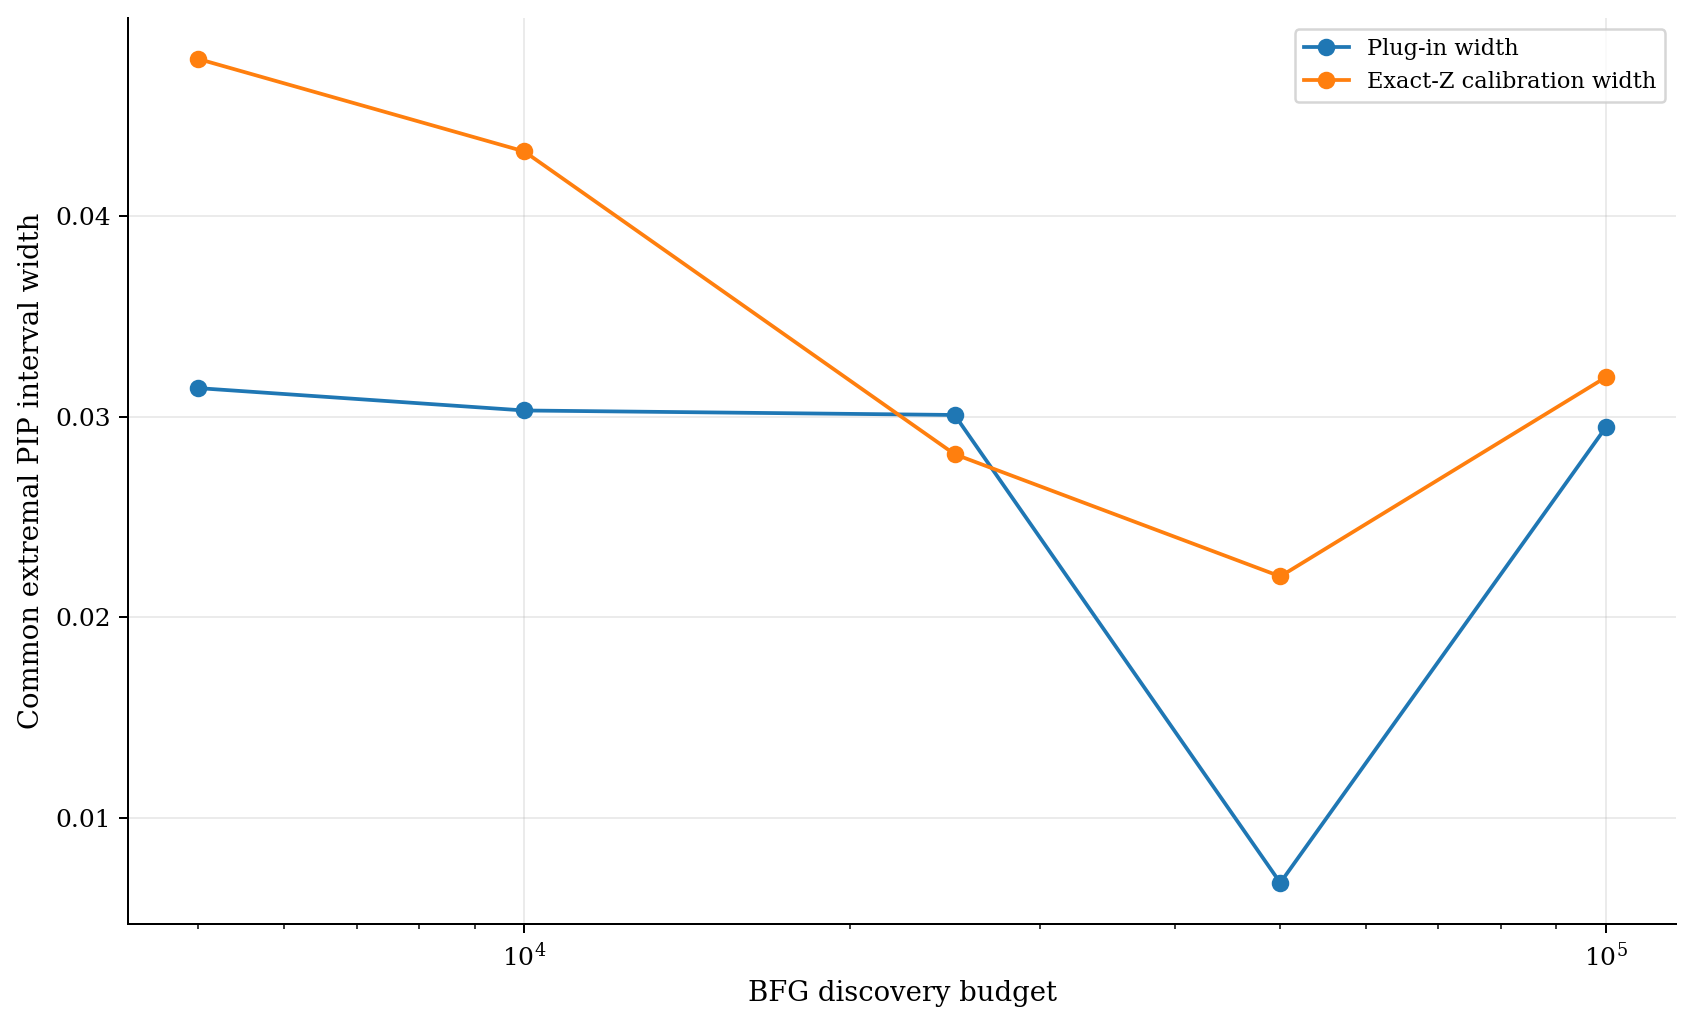

Explored posterior mass vs BFG budget


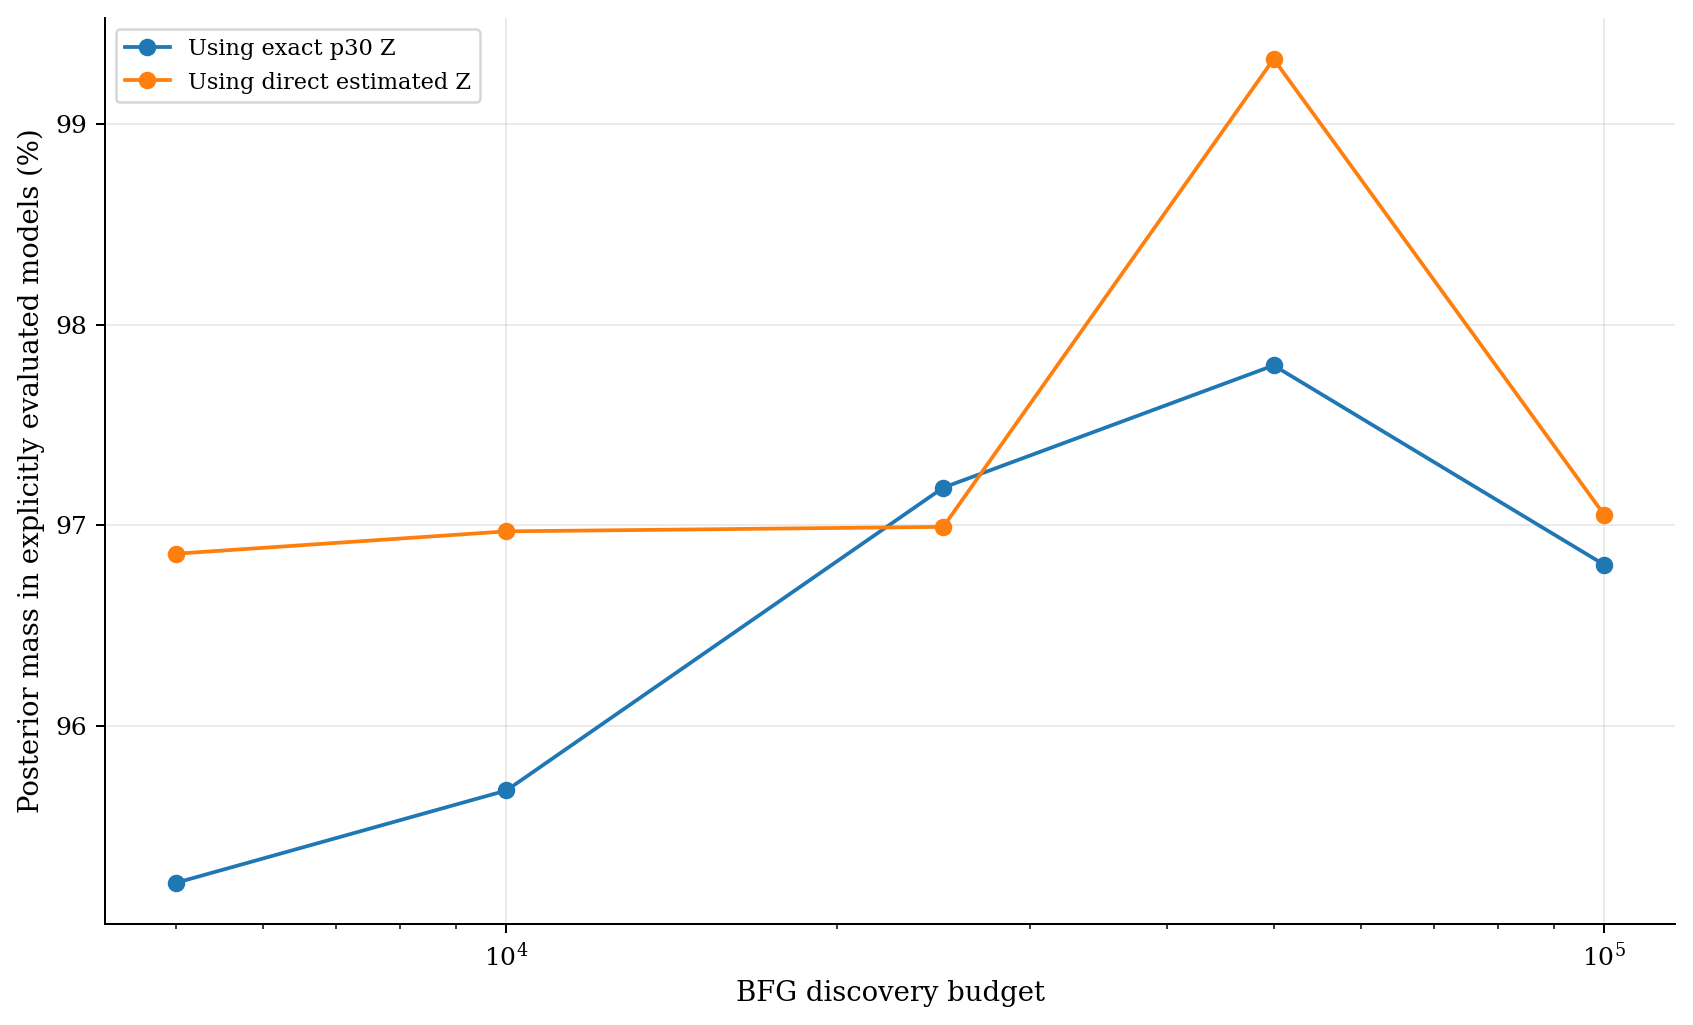

In [21]:
# ============================================================
# Display saved PIP-budget-sensitivity figures inline
# ============================================================

from IPython.display import display, Image

pip_width_figure = (
    OUTPUT_DIR
    / "pip_budget_sensitivity"
    / "PIP_WIDTH_VS_BFG_BUDGET.png"
)

explored_mass_figure = (
    OUTPUT_DIR
    / "pip_budget_sensitivity"
    / "EXPLORED_POSTERIOR_MASS_VS_BFG_BUDGET.png"
)


print(
    "PIP width vs BFG budget"
)

display(
    Image(
        filename=str(
            pip_width_figure
        )
    )
)


print(
    "Explored posterior mass vs BFG budget"
)

display(
    Image(
        filename=str(
            explored_mass_figure
        )
    )
)

## 16. Interpretation and scientific boundaries

- **BFG is an extreme-value search mechanism.** A uniform probability sample can reconstruct a shell's bulk distribution while still having very low probability of containing a unique champion. BFG supplies targeted high-evidence discoveries.

- **Hybrid recovery is a distribution-reconstruction mechanism.** It uses exact census where enumeration is cheap, then a monotone probability-sampling ramp, and finally a fixed per-shell computational cap.

- **Repeated BFG searches provide empirical elite-frontier diagnostics when exhaustive truth is unavailable.** In p30 we can calibrate these diagnostics against the exact Top-100. In p90/p100, stability across larger budgets and independent seeds is evidence of search convergence, not proof of exhaustive optimality.

- **The exact p30 enumeration remains the gold standard for calibration.** KS, Wasserstein, exact Top-\(K\), exact \(\log Z\), and exact PIPs are benchmark diagnostics. Sampled recovery is not claimed to be globally exact for arbitrary datasets.

- **The direct stratified normalizer is the primary practical estimator of \(Z\).** Histogram integration and truncated KDE are retained as comparison estimators. A candidate normalizer used for PIP decomposition must at minimum satisfy \(\widehat Z\ge Z_E\), where \(Z_E\) is the exact mass of explicitly evaluated models.

- **Extremal PIP intervals separate observed posterior mass from assumptions about unvisited models.** Conditional on \(\widehat Z\),

$$
\widehat{PIP}^{\min}_j
=
\frac{Z^+_{j,E}}{\widehat Z},
\qquad
\widehat{PIP}^{\max}_j
=
1-
\frac{Z^-_{j,E}}{\widehat Z}.
$$

Their common width is

$$
\widehat{PIP}^{\max}_j-\widehat{PIP}^{\min}_j
=
1-\frac{Z_E}{\widehat Z},
$$

the estimated posterior-mass fraction assigned to models that were not explicitly evaluated.

- **Coefficient inference remains a separate Pass 2 problem.** This notebook validates model-space discovery, shell-distribution recovery, normalization, and PIP uncertainty. Posterior coefficient means, second moments, and standard deviations require coefficient calculations over the selected recovery design with appropriate model and sampling weights.

The resulting architecture is

$$
\boxed{
\text{BFG for champions}
+
\text{census / monotone sampling for the bulk}
+
\widehat Z
+
\text{extremal PIP bounds}
+
\text{Pass 2 coefficient inference}
}
$$


## 17. Direct plug-in PIP estimator

This cell computes and saves the shell-weighted plug-in PIP table. The DataFrame is named `pip_plugin_df` to avoid colliding with the canonical NumPy vector `pip_plugin` created by the variable-map cell.


In [22]:
# ============================================================
# PLUG-IN PIP ESTIMATION FROM BFG + SHELL RECOVERY (TABLE ESTIMATOR)
#
# For each candidate variable j:
#
#   Z_j^+
#       =
#       posterior-numerator mass of all models containing j
#
#
# Direct shell estimator:
#
#   Z_hat_{j,k}^+
#
#       =
#       sum_{M in BFG_k, j in M} exp(s_M)
#
#       +
#
#       ((N_k - D_k) / n_k)
#       *
#       sum_{M in recovery_k, j in M} exp(s_M)
#
#
# Then:
#
#       Z_hat_j^+
#           =
#       sum_k Z_hat_{j,k}^+
#
#
# and:
#
#       PIP_hat_j
#           =
#       Z_hat_j^+ / Z_hat_direct
#
#
# This is NOT the midpoint of the extremal bounds.
# It is a proper probability-sampling plug-in estimate based
# on the same shell weights used to estimate Z.
#
# Canonical p30 validation:
#
#   - compare against exact_global_pips.csv
#   - verify whether PIP_hat lies inside logical bounds
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.special import logsumexp


# ============================================================
# Helper
# ============================================================

def log_weighted_subset_sum(
    scores,
    included,
    weights=None,
):
    """
    Compute

        log sum_i weights_i * exp(scores_i)

    restricted to included == True.

    Empty subset -> -inf.
    """

    scores = np.asarray(
        scores,
        dtype=np.float64,
    )

    included = np.asarray(
        included,
        dtype=bool,
    )

    if weights is None:

        if not np.any(
            included
        ):

            return -np.inf

        return float(
            logsumexp(
                scores[
                    included
                ]
            )
        )


    weights = np.asarray(
        weights,
        dtype=np.float64,
    )

    valid = (
        included
        & np.isfinite(scores)
        & np.isfinite(weights)
        & (weights > 0)
    )

    if not np.any(
        valid
    ):

        return -np.inf


    return float(
        logsumexp(
            scores[
                valid
            ]
            + np.log(
                weights[
                    valid
                ]
            )
        )
    )


# ============================================================
# 1. BFG masks and scores
# ============================================================

bfg_model_ids = (
    records_df_Z[
        "model_id"
    ]
    .to_numpy(
        dtype=np.uint64
    )
)


bfg_scores_all = (
    records_df_Z[
        "log_score"
    ]
    .to_numpy(
        dtype=np.float64
    )
)


bfg_sizes = (
    records_df_Z[
        "model_size"
    ]
    .to_numpy(
        dtype=np.int64
    )
)


# ============================================================
# 2. Shell-level plug-in numerator estimates
# ============================================================

pip_shell_rows = []


for j in range(
    P
):

    variable_name = (
        f"x{j + 1}"
    )


    log_Z_plus_shells = []


    for k in range(
        P + 1
    ):

        d = shell_data_Z[k]


        # ----------------------------------------------------
        # BFG contribution
        # ----------------------------------------------------

        bfg_shell_mask = (
            bfg_sizes
            == k
        )


        bfg_ids_k = (
            bfg_model_ids[
                bfg_shell_mask
            ]
        )


        bfg_scores_k = (
            bfg_scores_all[
                bfg_shell_mask
            ]
        )


        included_bfg = (
            mask_contains_variable(
                bfg_ids_k,
                j,
            )
        )


        log_Z_plus_bfg = (
            log_weighted_subset_sum(
                bfg_scores_k,
                included_bfg,
            )
        )


        # ----------------------------------------------------
        # Recovery contribution
        # ----------------------------------------------------

        n_recovery = int(
            d[
                "n_recovery"
            ]
        )


        if n_recovery == 0:

            log_Z_plus_recovery = (
                -np.inf
            )


        else:

            shell_path = (
                RECOVERY_RUN_DIR
                / f"shell_k{k:02d}.npz"
            )


            with np.load(
                shell_path,
                allow_pickle=False,
            ) as z:

                available_keys = set(
                    z.files
                )


                # --------------------------------------------
                # Detect model-ID / mask key
                # --------------------------------------------

                mask_key = None

                for candidate_key in [
                    "masks",
                    "model_ids",
                    "model_id",
                    "models",
                ]:

                    if (
                        candidate_key
                        in available_keys
                    ):

                        mask_key = (
                            candidate_key
                        )

                        break


                if mask_key is None:

                    raise KeyError(
                        f"{shell_path.name}: "
                        "cannot find model masks/IDs. "
                        f"Available keys: "
                        f"{sorted(available_keys)}"
                    )


                recovery_ids_k = np.asarray(
                    z[
                        mask_key
                    ],
                    dtype=np.uint64,
                )[:n_recovery]


                recovery_scores_k = np.asarray(
                    z[
                        "scores"
                    ],
                    dtype=np.float64,
                )[:n_recovery]


            included_recovery = (
                mask_contains_variable(
                    recovery_ids_k,
                    j,
                )
            )


            expansion = float(
                d[
                    "expansion"
                ]
            )


            recovery_weights = np.full(
                n_recovery,
                expansion,
                dtype=np.float64,
            )


            log_Z_plus_recovery = (
                log_weighted_subset_sum(
                    recovery_scores_k,
                    included_recovery,
                    weights=recovery_weights,
                )
            )


        # ----------------------------------------------------
        # Combine BFG + recovery estimate for shell k
        # ----------------------------------------------------

        log_Z_plus_k = float(
            logsumexp(
                [
                    log_Z_plus_bfg,
                    log_Z_plus_recovery,
                ]
            )
        )


        log_Z_plus_shells.append(
            log_Z_plus_k
        )


        pip_shell_rows.append(
            {
                "variable":
                    variable_name,

                "variable_index":
                    j + 1,

                "k":
                    k,

                "log_Z_plus_BFG":
                    log_Z_plus_bfg,

                "log_Z_plus_recovery_weighted":
                    log_Z_plus_recovery,

                "log_Z_plus_shell":
                    log_Z_plus_k,
            }
        )


    # --------------------------------------------------------
    # Global inclusion numerator estimate
    # --------------------------------------------------------

    log_Z_plus_global = float(
        logsumexp(
            log_Z_plus_shells
        )
    )


    # Store temporarily in dict list below
    if j == 0:

        pip_plugin_rows = []


    PIP_hat = float(
        np.exp(
            log_Z_plus_global
            - log_Z_direct
        )
    )


    pip_plugin_rows.append(
        {
            "variable":
                variable_name,

            "variable_index":
                j + 1,

            "log_Z_plus_hat":
                log_Z_plus_global,

            "PIP_plugin":
                PIP_hat,
        }
    )


# ============================================================
# 3. Assemble global plug-in PIP table
# ============================================================

pip_plugin_df = pd.DataFrame(
    pip_plugin_rows
)


pip_plugin_shell = pd.DataFrame(
    pip_shell_rows
)


# ============================================================
# 4. Merge with extremal bounds if already available
# ============================================================

if (
    "pip_bounds"
    in globals()
):

    bounds_columns = [
        "variable",
    ]


    for candidate in [
        "PIP_min_direct",
        "PIP_max_direct",
        "PIP_width_direct",
        "PIP_exact",
    ]:

        if (
            candidate
            in pip_bounds.columns
        ):

            bounds_columns.append(
                candidate
            )


    pip_plugin_df = (
        pip_plugin_df
        .merge(
            pip_bounds[
                bounds_columns
            ],
            on="variable",
            how="left",
            validate="one_to_one",
        )
    )


# ============================================================
# 5. Load exact p30 PIPs if needed
# ============================================================

if (
    "PIP_exact"
    not in pip_plugin_df.columns
):

    exact_pips_path = (
        EXACT_REF_DIR
        / "exact_global_pips.csv"
    )


    exact_pips_raw = pd.read_csv(
        exact_pips_path
    )


    if (
        "predictor"
        in exact_pips_raw.columns
    ):

        variable_column = (
            "predictor"
        )

    else:

        variable_column = (
            "variable"
        )


    if (
        "exact_global_pip"
        in exact_pips_raw.columns
    ):

        pip_column = (
            "exact_global_pip"
        )

    else:

        pip_column = (
            "pip"
        )


    exact_pips = (
        exact_pips_raw[
            [
                variable_column,
                pip_column,
            ]
        ]
        .rename(
            columns={
                variable_column:
                    "variable",

                pip_column:
                    "PIP_exact",
            }
        )
    )


    pip_plugin_df = (
        pip_plugin_df
        .merge(
            exact_pips,
            on="variable",
            how="left",
            validate="one_to_one",
        )
    )


# ============================================================
# 6. Diagnostics
# ============================================================

pip_plugin_df[
    "PIP_error"
] = (
    pip_plugin_df[
        "PIP_plugin"
    ]
    - pip_plugin_df[
        "PIP_exact"
    ]
)


pip_plugin_df[
    "abs_PIP_error"
] = np.abs(
    pip_plugin_df[
        "PIP_error"
    ]
)


if (
    "PIP_min_direct"
    in pip_plugin_df.columns
    and "PIP_max_direct"
    in pip_plugin_df.columns
):

    pip_plugin_df[
        "plugin_inside_bounds"
    ] = (
        (
            pip_plugin_df[
                "PIP_plugin"
            ]
            >= pip_plugin_df[
                "PIP_min_direct"
            ] - 1e-12
        )
        &
        (
            pip_plugin_df[
                "PIP_plugin"
            ]
            <= pip_plugin_df[
                "PIP_max_direct"
            ] + 1e-12
        )
    )


pip_rmse = float(
    np.sqrt(
        np.mean(
            pip_plugin_df[
                "PIP_error"
            ] ** 2
        )
    )
)


pip_mae = float(
    np.mean(
        pip_plugin_df[
            "abs_PIP_error"
        ]
    )
)


pip_max_abs_error = float(
    np.max(
        pip_plugin_df[
            "abs_PIP_error"
        ]
    )
)


pip_corr = float(
    np.corrcoef(
        pip_plugin_df[
            "PIP_plugin"
        ],
        pip_plugin_df[
            "PIP_exact"
        ],
    )[0, 1]
)


# ============================================================
# 7. Console summary
# ============================================================

print(
    "=" * 92
)

print(
    "DIRECT PLUG-IN PIP ESTIMATION"
)

print(
    "=" * 92
)


print()

print(
    f"Normalizer used: "
    f"log Z_direct = "
    f"{log_Z_direct:.12f}"
)


print()

print(
    "Validation against exact p30 PIPs:"
)

print(
    f"  RMSE          = "
    f"{pip_rmse:.8f}"
)

print(
    f"  MAE           = "
    f"{pip_mae:.8f}"
)

print(
    f"  Max abs error = "
    f"{pip_max_abs_error:.8f}"
)

print(
    f"  Correlation   = "
    f"{pip_corr:.8f}"
)


if (
    "plugin_inside_bounds"
    in pip_plugin_df.columns
):

    print(
        f"  Plug-in PIPs inside direct bounds = "
        f"{int(pip_plugin_df['plugin_inside_bounds'].sum())}"
        f"/{P}"
    )


print()

display(
    pip_plugin_df[
        [
            "variable",
            "PIP_exact",
            "PIP_plugin",
            "PIP_error",
            "abs_PIP_error",
        ]
        + (
            [
                "PIP_min_direct",
                "PIP_max_direct",
                "plugin_inside_bounds",
            ]
            if (
                "PIP_min_direct"
                in pip_plugin_df.columns
            )
            else []
        )
    ]
)


# ============================================================
# 8. Save outputs
# ============================================================

PIP_PLUGIN_DIR = (
    OUTPUT_DIR
    / "pip_plugin_df"
)

PIP_PLUGIN_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


pip_plugin_path = (
    PIP_PLUGIN_DIR
    / "PIP_PLUGIN_DIRECT.csv"
)


pip_plugin_shell_path = (
    PIP_PLUGIN_DIR
    / "PIP_PLUGIN_BY_SHELL.csv"
)


pip_plugin_df.to_csv(
    pip_plugin_path,
    index=False,
)


pip_plugin_shell.to_csv(
    pip_plugin_shell_path,
    index=False,
)


print()

print(
    "Saved:"
)

print(
    pip_plugin_path
)

print(
    pip_plugin_shell_path
)

# Diagnostic plotting is intentionally handled in the dedicated
# PIP validation figure cell below, after the canonical arrays
# pip_plugin / pip_lower / pip_upper have been rebuilt.


DIRECT PLUG-IN PIP ESTIMATION

Normalizer used: log Z_direct = 1119.256485608632

Validation against exact p30 PIPs:
  RMSE          = 0.00557038
  MAE           = 0.00371130
  Max abs error = 0.01385387
  Correlation   = 0.99993380
  Plug-in PIPs inside direct bounds = 30/30



,variable,PIP_exact,PIP_plugin,PIP_error,abs_PIP_error,PIP_min_direct,PIP_max_direct,plugin_inside_bounds
0,x1,1.000000,1.000000,0.000000e+00,0.000000e+00,0.968570,1.000000,True
1,x2,1.000000,1.000000,0.000000e+00,0.000000e+00,0.968570,1.000000,True
2,x3,1.000000,1.000000,0.000000e+00,0.000000e+00,0.968570,1.000000,True
3,x4,1.000000,1.000000,0.000000e+00,0.000000e+00,0.968570,1.000000,True
4,x5,1.000000,1.000000,0.000000e+00,0.000000e+00,0.968570,1.000000,True
5,x6,1.000000,1.000000,7.771561e-16,7.771561e-16,0.968570,1.000000,True
6,x7,1.000000,1.000000,4.551914e-15,4.551914e-15,0.968570,1.000000,True
7,x8,1.000000,1.000000,0.000000e+00,0.000000e+00,0.968570,1.000000,True
8,x9,1.000000,1.000000,0.000000e+00,0.000000e+00,0.968570,1.000000,True
9,x10,1.000000,1.000000,1.143960e-10,1.143960e-10,0.968570,1.000000,True



Saved:
/content/outputs/shell_recovery/pip_plugin_df/PIP_PLUGIN_DIRECT.csv
/content/outputs/shell_recovery/pip_plugin_df/PIP_PLUGIN_BY_SHELL.csv


## 18. Canonical BFG + shell-recovery variable map

This is the canonical model/variable structure figure. It reconstructs the direct normalizer, plug-in PIPs, and logical PIP bounds from aligned BFG and recovery score/mask pairs.


Recovery directory:
/content/outputs/shell_recovery/recovery_shell_scores
Recovery shell files: 25

Direct log Z from this figure cell:
  1119.256485608632
Reference log Z-hat:
  1119.256485608632
Difference:
  +0.000000000000e+00

Logical-bound audit:
  explored mass: 96.8570%
  unexplored mass: 3.1430%
  expected common PIP width: 0.031430
  observed PIP width range: [0.031430, 0.031430]
  plug-in PIPs inside bounds: 30/30

OLS-sign sufficient-statistics audit:
  Zxx: (30, 30)
  Zxy: (30,)
  Top-model sign matrix: (30, 50)
PASS: Top-model OLS signs reconstructed directly from sufficient statistics.


### BFG + shell-recovery variable / model structure

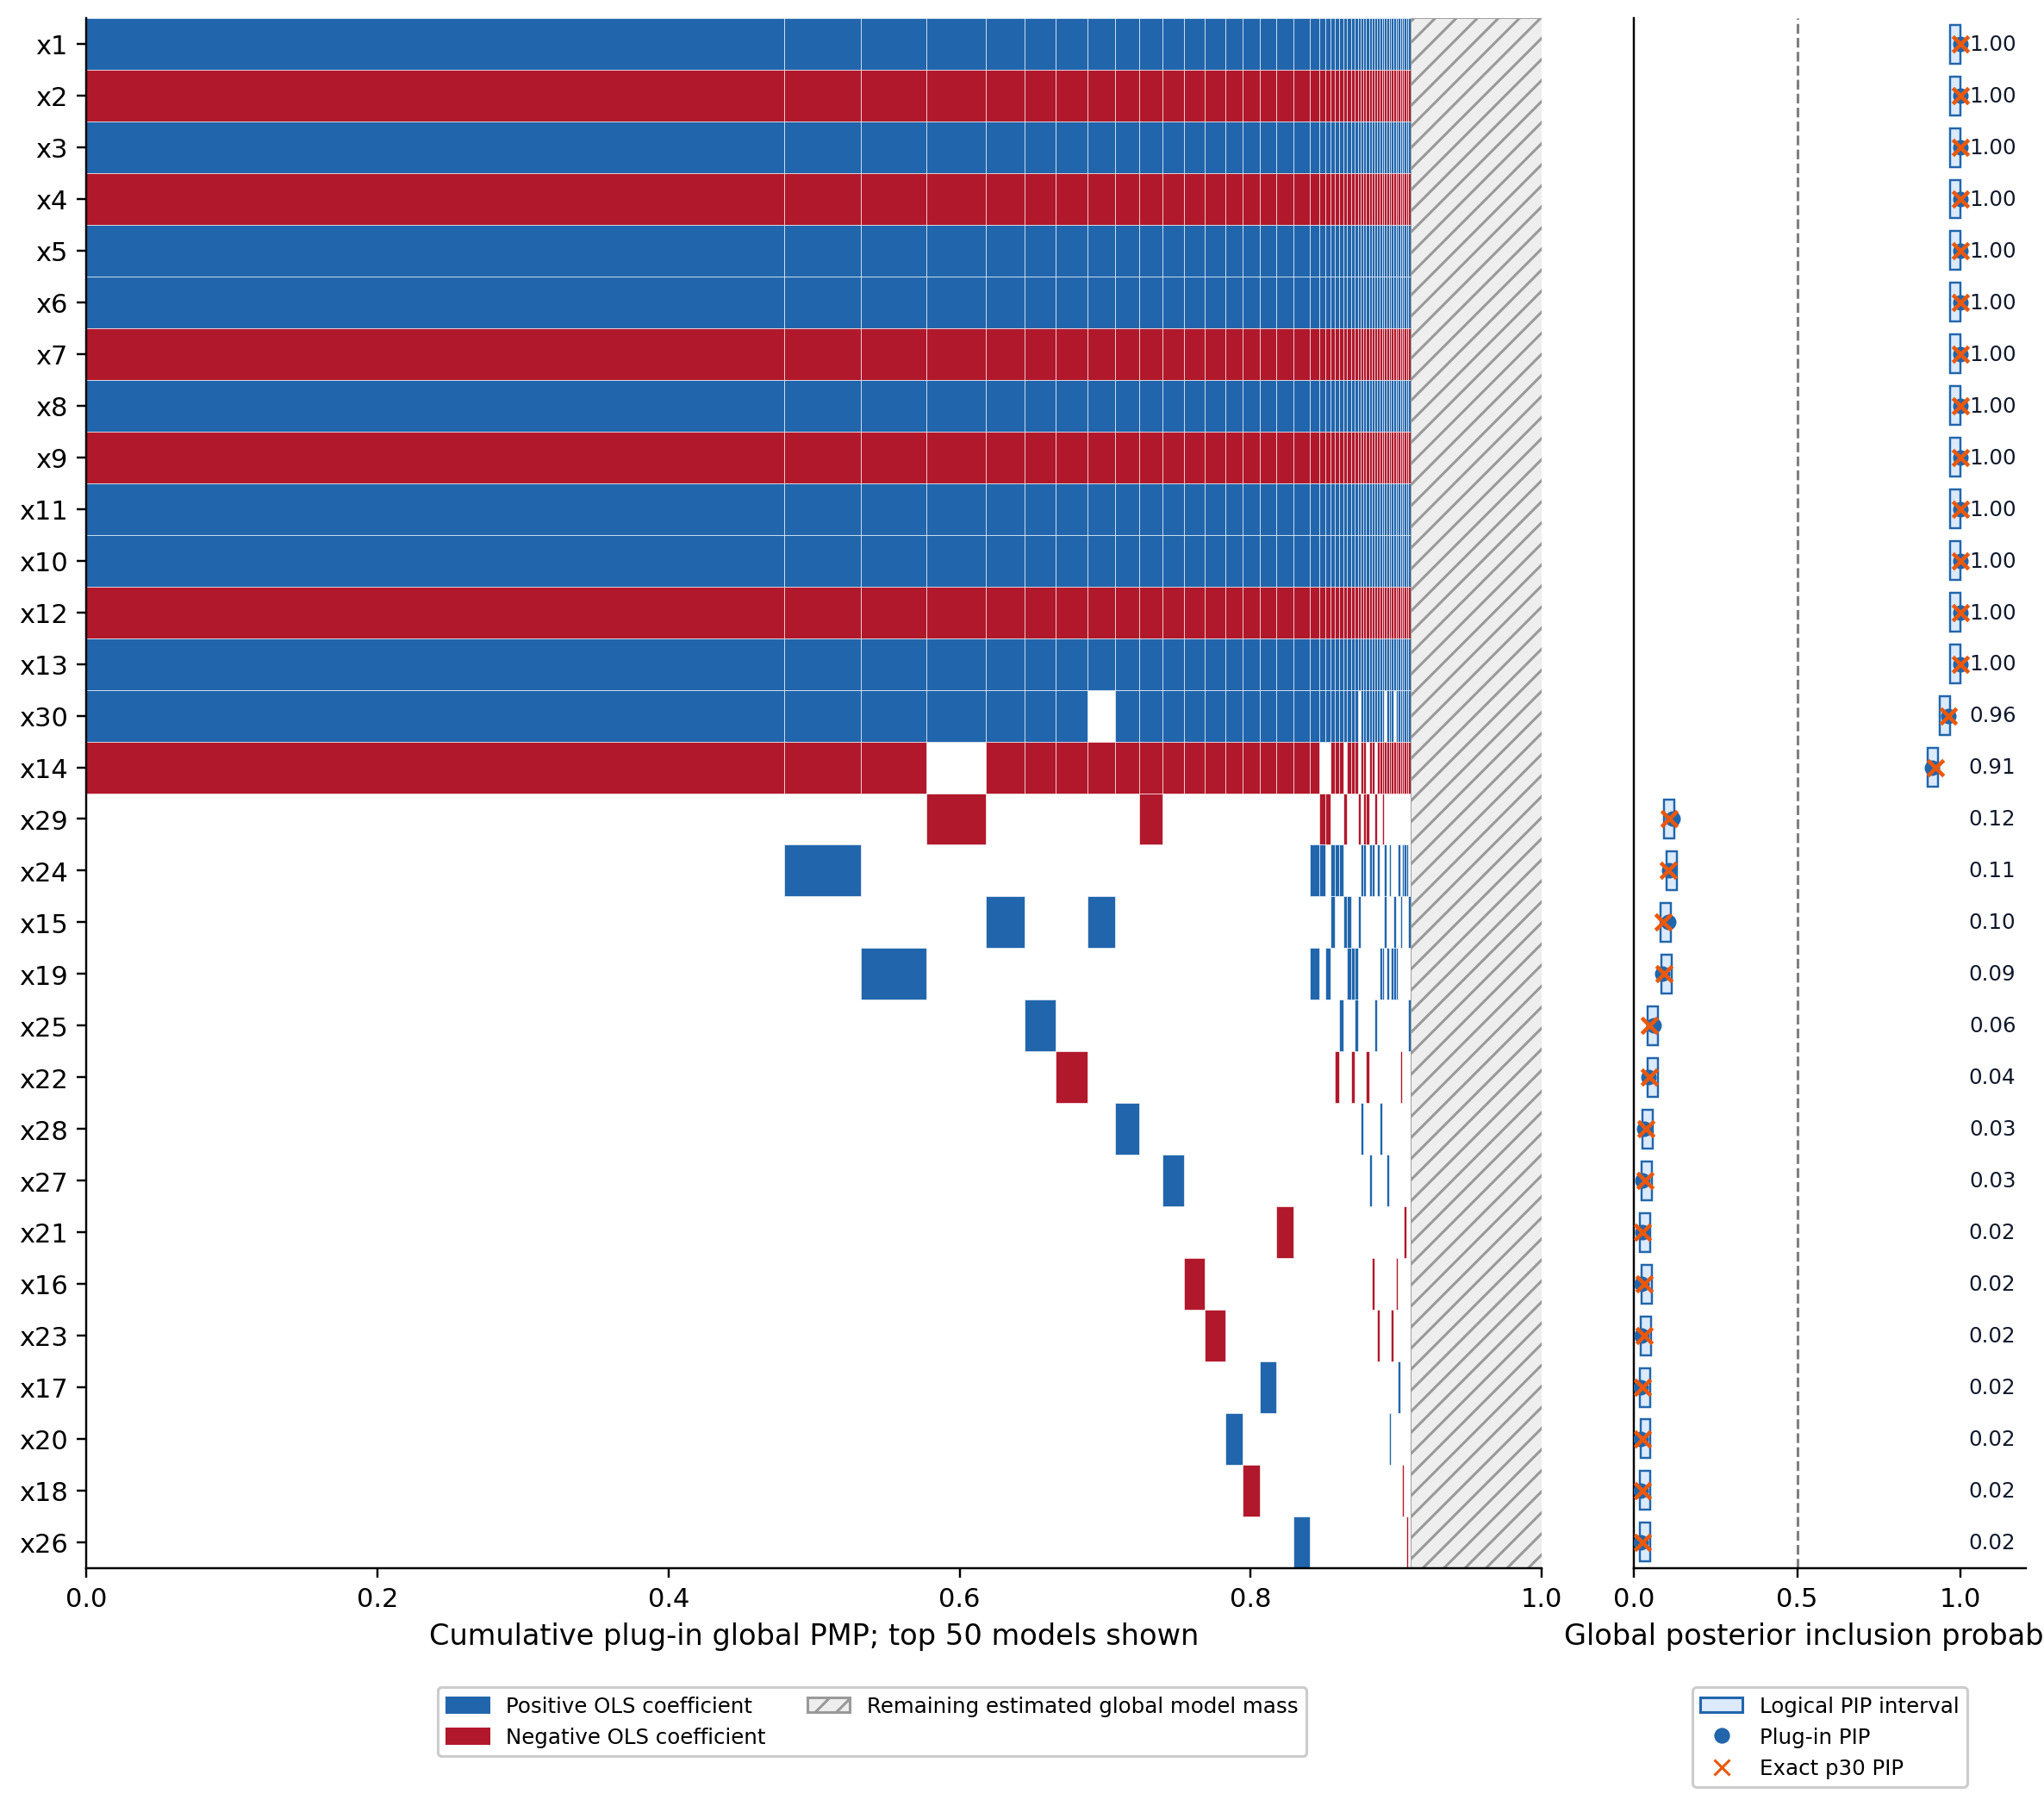

**Notes:** Model widths use plug-in global posterior model probabilities computed with the direct shell-recovery estimate of the global normalizer $\hat Z$. The hatched region represents estimated global model mass outside the displayed top 50 models. The right sidebar reports logical minimum/maximum PIP intervals together with the shell-weighted plug-in PIP estimate. Exact p30 PIPs are overlaid only for benchmark validation. Cell colors describe model-specific OLS coefficient signs reconstructed directly from the residualized sufficient statistics $X_r'X_r$ and $X_r'y_r$. Always-in controls are excluded.


Saved figure: /content/outputs/shell_recovery/canonical_figures/09_bfg_recovery_variable_map.png
Saved top-model table: /content/outputs/shell_recovery/canonical_figures/09_bfg_recovery_top_models.csv
Saved PIP table: /content/outputs/shell_recovery/canonical_figures/09_bfg_recovery_pip_bounds.csv

BFG budget used: 5,000
Recovery shell files scanned: 25
Recovery models scanned: 16,736,486
Estimated log Z-hat source: current global variable `log_Z_direct`
log Z direct recomputed: 1119.256485608632
log Z used: 1119.256485608632
Exact explicitly evaluated mass under Z-hat: 96.8570%
Estimated unexplored mass under Z-hat: 3.1430%
Common logical PIP interval width: 0.031430
Observed logical width range: [0.031430, 0.031430]
Plug-in PIPs inside logical bounds: 30/30
Displayed Top-50 mass: 90.9762%
Remaining mass outside displayed Top-50: 9.0238%

p30 plug-in PIP validation:
  RMSE = 0.00557038
  MAE  = 0.00371130
  Exact PIPs inside logical bounds = 30/30


In [23]:
# ============================================================
# CANONICAL BFG + SHELL-RECOVERY VARIABLE / MODEL STRUCTURE
#
# Final robust implementation
#
#   - BFG models enter with representation weight 1
#   - recovery models enter with shell expansion weight
#
#         w_k = (N_k - D_k) / n_k
#
#   - plug-in PIP numerator uses the SAME weighted recovery
#     design as the direct Z estimator
#
#   - logical PIP bounds use ONLY actually evaluated model mass
#
#   - Top-50 coefficient signs are reconstructed DIRECTLY from
#     sufficient statistics:
#
#         beta_hat_M = Zxx_M^{-1} Zxy_M
#
#     so the figure no longer depends on raw y/X, controls,
#     recovery_base_scorer, or live GPU objects.
#
#   - visual design clones 04_exact_global_variable_map.png
#
#   - PIP labels:
#         two decimals
#         one aligned vertical column on far right
#
#   - both legends below their corresponding panels
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from scipy.special import logsumexp
from scipy.linalg import cho_factor, cho_solve

from matplotlib.patches import Rectangle, Patch
from matplotlib.lines import Line2D
from IPython.display import display, Markdown, Image


# ============================================================
# Canonical visual constants
# ============================================================

BLUE   = "#2166ac"
RED    = "#b2182b"
INK    = "#0f172a"
ORANGE = "#ea580c"


# ============================================================
# Configuration
# ============================================================

TOP_N_MODELS = 50

CURRENT_BFG_BUDGET = int(
    len(
        bfg_result.records
    )
)


FIG_DIR = (
    OUTPUT_DIR
    / "canonical_figures"
)

FIG_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


FIG_PATH = (
    FIG_DIR
    / "09_bfg_recovery_variable_map.png"
)


TOP_TABLE_PATH = (
    FIG_DIR
    / "09_bfg_recovery_top_models.csv"
)


PIP_TABLE_PATH = (
    FIG_DIR
    / "09_bfg_recovery_pip_bounds.csv"
)


# ============================================================
# Locate recovery directory
# ============================================================

candidate_recovery_dirs = []


if "RECOVERY_RUN_DIR" in globals():

    candidate_recovery_dirs.append(
        Path(
            RECOVERY_RUN_DIR
        )
    )


candidate_recovery_dirs.extend(
    [
        OUTPUT_DIR
        / "recovery_shell_scores",

        OUTPUT_DIR
        / "random_shell_scores",

        OUTPUT_DIR
        / "shell_recovery"
        / "recovery_shell_scores",

        OUTPUT_DIR
        / "shell_recovery"
        / "random_shell_scores",
    ]
)


RECOVERY_DIR = None


for candidate_dir in candidate_recovery_dirs:

    if (
        candidate_dir.is_dir()
        and len(
            list(
                candidate_dir.glob(
                    "shell_k*.npz"
                )
            )
        ) > 0
    ):

        RECOVERY_DIR = (
            candidate_dir
        )

        break


if RECOVERY_DIR is None:

    raise FileNotFoundError(
        "Could not locate shell_kXX.npz recovery files.\n"
        "Checked:\n"
        + "\n".join(
            str(x)
            for x in candidate_recovery_dirs
        )
    )


recovery_files = sorted(
    RECOVERY_DIR.glob(
        "shell_k*.npz"
    )
)


print(
    "Recovery directory:"
)

print(
    RECOVERY_DIR
)

print(
    "Recovery shell files:",
    len(
        recovery_files
    )
)


# ============================================================
# Candidate information
# ============================================================

candidate_names = list(
    bfg_result.candidate_names
)


P = len(
    candidate_names
)


records_df_map = pd.DataFrame(
    bfg_result.records
).copy()


records_df_map[
    "model_id"
] = (
    records_df_map[
        "model_id"
    ]
    .astype(
        np.uint64
    )
)


records_df_map[
    "log_score"
] = (
    records_df_map[
        "log_score"
    ]
    .astype(
        np.float64
    )
)


records_df_map[
    "model_size"
] = (
    records_df_map[
        "model_size"
    ]
    .astype(
        int
    )
)


# ============================================================
# Helpers
# ============================================================

def mask_contains_variable(
    masks,
    j,
):

    masks = np.asarray(
        masks,
        dtype=np.uint64,
    )

    bit = (
        np.uint64(1)
        << np.uint64(j)
    )

    return (
        masks
        & bit
    ) != 0


def mask_to_indices(
    mask,
    p,
):

    mask = int(
        mask
    )

    return np.array(
        [
            j
            for j in range(
                p
            )
            if (
                mask
                >> j
            ) & 1
        ],
        dtype=np.intp,
    )


def get_shell_row(
    k,
):

    row = (
        shell_counts.loc[
            shell_counts[
                "k"
            ].eq(
                k
            )
        ]
    )

    if len(
        row
    ) != 1:

        raise RuntimeError(
            f"Expected exactly one shell_counts row for k={k}."
        )

    return (
        row.iloc[
            0
        ]
    )


def detect_mask_key(
    npz_obj,
):

    for key in [
        "masks",
        "model_ids",
        "model_id",
        "models",
        "mask",
    ]:

        if key in npz_obj.files:

            return key

    raise KeyError(
        "Could not find model masks in NPZ. "
        f"Available keys: {npz_obj.files}"
    )


# ============================================================
# Retrieve direct estimated global log Z
# ============================================================

log_Z_hat = None
log_Z_source = None


if (
    "log_Z_direct"
    in globals()
):

    log_Z_hat = float(
        log_Z_direct
    )

    log_Z_source = (
        "current global variable "
        "`log_Z_direct`"
    )


if log_Z_hat is None:

    budget_sens_path = (
        OUTPUT_DIR
        / "pip_budget_sensitivity"
        / "PIP_BOUND_SENSITIVITY_BY_BFG_BUDGET.csv"
    )


    if budget_sens_path.is_file():

        sens = pd.read_csv(
            budget_sens_path
        )


        matched = (
            sens.loc[
                sens[
                    "BFG_budget"
                ].eq(
                    CURRENT_BFG_BUDGET
                )
            ]
        )


        if len(
            matched
        ) > 0:

            log_Z_hat = float(
                matched.iloc[
                    0
                ][
                    "log_Z_direct"
                ]
            )

            log_Z_source = (
                budget_sens_path.name
                + " [log_Z_direct]"
            )


if log_Z_hat is None:

    raise RuntimeError(
        "Could not identify direct estimated log Z. "
        "Run the direct Z-estimation cell first."
    )


# ============================================================
# BFG models by shell
# ============================================================

bfg_by_k = {}


for k in range(
    P + 1
):

    bfg_by_k[
        k
    ] = (
        records_df_map.loc[
            records_df_map[
                "model_size"
            ].eq(
                k
            )
        ]
        .copy()
    )


# ============================================================
# Accumulators
# ============================================================

log_Z_shell_direct = []


log_Z_plus_by_variable_shell = {
    j: []
    for j in range(
        P
    )
}


explicit_scores_all = []
explicit_masks_all = []

top_candidates = []

recovery_models_scanned = 0


# ============================================================
# Main shell loop
# ============================================================

for k in range(
    P + 1
):

    plan = get_shell_row(
        k
    )


    N_k = int(
        plan[
            "N_k"
        ]
    )


    D_k = int(
        plan[
            "D_k"
        ]
    )


    remainder_k = int(
        plan[
            "remainder_k"
        ]
    )


    if (
        "recovery_evaluations"
        in plan.index
    ):

        n_recovery = int(
            plan[
                "recovery_evaluations"
            ]
        )

    elif (
        "n_k_random"
        in plan.index
    ):

        n_recovery = int(
            plan[
                "n_k_random"
            ]
        )

    else:

        raise KeyError(
            "shell_counts has neither "
            "'recovery_evaluations' nor 'n_k_random'."
        )


    # --------------------------------------------------------
    # BFG models in shell
    # --------------------------------------------------------

    bfg_k = (
        bfg_by_k[
            k
        ]
    )


    bfg_masks = (
        bfg_k[
            "model_id"
        ]
        .to_numpy(
            dtype=np.uint64
        )
    )


    bfg_scores = (
        bfg_k[
            "log_score"
        ]
        .to_numpy(
            dtype=np.float64
        )
    )


    explicit_scores_all.append(
        bfg_scores
    )

    explicit_masks_all.append(
        bfg_masks
    )


    # --------------------------------------------------------
    # Recovery models
    # --------------------------------------------------------

    if n_recovery > 0:

        shell_path = (
            RECOVERY_DIR
            / f"shell_k{k:02d}.npz"
        )


        if not shell_path.is_file():

            raise FileNotFoundError(
                f"Missing recovery shell: {shell_path}"
            )


        with np.load(
            shell_path,
            allow_pickle=False,
        ) as z:

            if (
                "scores"
                not in z.files
            ):

                raise KeyError(
                    f"{shell_path.name} has no 'scores' array."
                )


            mask_key = (
                detect_mask_key(
                    z
                )
            )


            recovery_scores = np.asarray(
                z[
                    "scores"
                ],
                dtype=np.float64,
            )[:n_recovery]


            recovery_masks = np.asarray(
                z[
                    mask_key
                ],
                dtype=np.uint64,
            )[:n_recovery]


        if (
            len(
                recovery_scores
            ) != n_recovery
            or len(
                recovery_masks
            ) != n_recovery
        ):

            raise RuntimeError(
                f"k={k}: expected {n_recovery:,} recovery models, "
                f"found scores={len(recovery_scores):,}, "
                f"masks={len(recovery_masks):,}."
            )


        recovery_models_scanned += (
            n_recovery
        )


        explicit_scores_all.append(
            recovery_scores
        )

        explicit_masks_all.append(
            recovery_masks
        )


        expansion = (
            remainder_k
            / n_recovery
        )


    else:

        recovery_scores = np.empty(
            0,
            dtype=np.float64,
        )

        recovery_masks = np.empty(
            0,
            dtype=np.uint64,
        )

        expansion = 0.0


    # --------------------------------------------------------
    # Direct Z estimate for shell
    # --------------------------------------------------------

    if len(
        bfg_scores
    ) > 0:

        log_Z_bfg_k = float(
            logsumexp(
                bfg_scores
            )
        )

    else:

        log_Z_bfg_k = (
            -np.inf
        )


    if len(
        recovery_scores
    ) > 0:

        log_Z_recovery_k = float(
            logsumexp(
                recovery_scores
                + np.log(
                    expansion
                )
            )
        )

    else:

        log_Z_recovery_k = (
            -np.inf
        )


    log_Z_k = float(
        logsumexp(
            [
                log_Z_bfg_k,
                log_Z_recovery_k,
            ]
        )
    )


    log_Z_shell_direct.append(
        log_Z_k
    )


    # --------------------------------------------------------
    # Variable-specific weighted inclusion numerator
    # --------------------------------------------------------

    for j in range(
        P
    ):

        included_bfg = (
            mask_contains_variable(
                bfg_masks,
                j,
            )
        )


        if np.any(
            included_bfg
        ):

            log_plus_bfg = float(
                logsumexp(
                    bfg_scores[
                        included_bfg
                    ]
                )
            )

        else:

            log_plus_bfg = (
                -np.inf
            )


        included_recovery = (
            mask_contains_variable(
                recovery_masks,
                j,
            )
        )


        if np.any(
            included_recovery
        ):

            log_plus_recovery = float(
                logsumexp(
                    recovery_scores[
                        included_recovery
                    ]
                    + np.log(
                        expansion
                    )
                )
            )

        else:

            log_plus_recovery = (
                -np.inf
            )


        log_plus_k = float(
            logsumexp(
                [
                    log_plus_bfg,
                    log_plus_recovery,
                ]
            )
        )


        log_Z_plus_by_variable_shell[
            j
        ].append(
            log_plus_k
        )


    # --------------------------------------------------------
    # Candidate Top models
    # --------------------------------------------------------

    if len(
        bfg_k
    ) > 0:

        top_candidates.append(
            bfg_k[
                [
                    "model_id",
                    "log_score",
                    "model_size",
                ]
            ]
        )


    if len(
        recovery_scores
    ) > 0:

        recovery_top = pd.DataFrame(
            {
                "model_id":
                    recovery_masks,

                "log_score":
                    recovery_scores,

                "model_size":
                    k,
            }
        )


        recovery_top = (
            recovery_top
            .nlargest(
                TOP_N_MODELS,
                "log_score",
            )
        )


        top_candidates.append(
            recovery_top
        )


# ============================================================
# Global direct Z cross-check
# ============================================================

log_Z_direct_check = float(
    logsumexp(
        log_Z_shell_direct
    )
)


print()

print(
    "Direct log Z from this figure cell:"
)

print(
    f"  {log_Z_direct_check:.12f}"
)

print(
    "Reference log Z-hat:"
)

print(
    f"  {log_Z_hat:.12f}"
)

print(
    "Difference:"
)

print(
    f"  {log_Z_direct_check - log_Z_hat:+.12e}"
)


if not np.isclose(
    log_Z_direct_check,
    log_Z_hat,
    rtol=0.0,
    atol=1e-10,
):

    raise RuntimeError(
        "Direct Z reconstructed inside figure cell "
        "does not match the supplied direct Z estimate."
    )


# ============================================================
# Plug-in PIPs
# ============================================================

pip_plugin = np.zeros(
    P,
    dtype=np.float64,
)


for j in range(
    P
):

    log_Z_plus_j = float(
        logsumexp(
            log_Z_plus_by_variable_shell[
                j
            ]
        )
    )


    pip_plugin[
        j
    ] = float(
        np.exp(
            log_Z_plus_j
            - log_Z_hat
        )
    )


pip_plugin = np.clip(
    pip_plugin,
    0.0,
    1.0,
)


# ============================================================
# Exact mass of ACTUALLY evaluated models
# ============================================================

explicit_scores = np.concatenate(
    explicit_scores_all
)

explicit_masks = np.concatenate(
    explicit_masks_all
)


if (
    len(
        explicit_scores
    )
    != len(
        explicit_masks
    )
):

    raise RuntimeError(
        "Explicit score/mask length mismatch."
    )


log_Z_E = float(
    logsumexp(
        explicit_scores
    )
)


explored_mass = float(
    np.exp(
        log_Z_E
        - log_Z_hat
    )
)


if explored_mass > (
    1.0
    + 1e-10
):

    raise RuntimeError(
        "Estimated total Z is smaller than "
        "the exactly observed explored-model mass."
    )


explored_mass = float(
    np.clip(
        explored_mass,
        0.0,
        1.0,
    )
)


unexplored_mass = (
    1.0
    - explored_mass
)


# ============================================================
# Logical extremal PIP bounds
# ============================================================

pip_lower = np.zeros(
    P,
    dtype=np.float64,
)

pip_upper = np.zeros(
    P,
    dtype=np.float64,
)


for j in range(
    P
):

    included = (
        mask_contains_variable(
            explicit_masks,
            j,
        )
    )


    if np.any(
        included
    ):

        log_plus_E = float(
            logsumexp(
                explicit_scores[
                    included
                ]
            )
        )


        lower = float(
            np.exp(
                log_plus_E
                - log_Z_hat
            )
        )

    else:

        lower = 0.0


    excluded = (
        ~included
    )


    if np.any(
        excluded
    ):

        log_minus_E = float(
            logsumexp(
                explicit_scores[
                    excluded
                ]
            )
        )


        upper = float(
            1.0
            - np.exp(
                log_minus_E
                - log_Z_hat
            )
        )

    else:

        upper = 1.0


    pip_lower[
        j
    ] = float(
        np.clip(
            lower,
            0.0,
            1.0,
        )
    )


    pip_upper[
        j
    ] = float(
        np.clip(
            upper,
            0.0,
            1.0,
        )
    )


# ============================================================
# Critical logical identities
# ============================================================

pip_width = (
    pip_upper
    - pip_lower
)


expected_width = (
    unexplored_mass
)


if not np.allclose(
    pip_width,
    expected_width,
    rtol=0.0,
    atol=1e-10,
):

    raise RuntimeError(
        "Logical PIP width identity failed.\n"
        f"Expected common width {expected_width:.12f}, "
        f"obtained range "
        f"[{pip_width.min():.12f}, "
        f"{pip_width.max():.12f}]."
    )


plugin_inside = (
    (
        pip_plugin
        >= pip_lower
        - 1e-10
    )
    &
    (
        pip_plugin
        <= pip_upper
        + 1e-10
    )
)


if not np.all(
    plugin_inside
):

    bad = np.where(
        ~plugin_inside
    )[0]

    raise RuntimeError(
        "Plug-in PIPs outside logical bounds: "
        + ", ".join(
            candidate_names[
                j
            ]
            for j in bad
        )
    )


print()

print(
    "Logical-bound audit:"
)

print(
    "  explored mass:",
    f"{100 * explored_mass:.4f}%",
)

print(
    "  unexplored mass:",
    f"{100 * unexplored_mass:.4f}%",
)

print(
    "  expected common PIP width:",
    f"{expected_width:.6f}",
)

print(
    "  observed PIP width range:",
    f"[{pip_width.min():.6f}, "
    f"{pip_width.max():.6f}]",
)

print(
    "  plug-in PIPs inside bounds:",
    f"{int(plugin_inside.sum())}/{P}",
)


# ============================================================
# Exact p30 PIPs — benchmark overlay only
# ============================================================

exact_pip = None


if (
    "EXACT_REF_DIR"
    in globals()
):

    exact_pip_path = (
        EXACT_REF_DIR
        / "exact_global_pips.csv"
    )


    if exact_pip_path.is_file():

        exact_df = pd.read_csv(
            exact_pip_path
        )


        exact_map = dict(
            zip(
                exact_df[
                    "predictor"
                ].astype(
                    str
                ),

                exact_df[
                    "exact_global_pip"
                ].astype(
                    float
                ),
            )
        )


        exact_pip = np.array(
            [
                exact_map[
                    name
                ]
                for name
                in candidate_names
            ],
            dtype=np.float64,
        )


# ============================================================
# Top 50 individual models
# ============================================================

top_df = (
    pd.concat(
        top_candidates,
        ignore_index=True,
    )
    .sort_values(
        "log_score",
        ascending=False,
    )
    .drop_duplicates(
        subset=[
            "model_id"
        ]
    )
    .head(
        TOP_N_MODELS
    )
    .reset_index(
        drop=True
    )
)


top_df[
    "pmp_hat"
] = np.exp(
    top_df[
        "log_score"
    ]
    - log_Z_hat
)


top_df[
    "cum_left"
] = (
    top_df[
        "pmp_hat"
    ]
    .cumsum()
    .shift(
        fill_value=0.0
    )
)


top_df[
    "cum_right"
] = (
    top_df[
        "pmp_hat"
    ]
    .cumsum()
)


displayed_top_mass = float(
    top_df[
        "pmp_hat"
    ].sum()
)


remaining_display_mass = (
    1.0
    - displayed_top_mass
)


# ============================================================
# OLS SIGNS FOR TOP-50 MODELS
#
# Robust method:
#
#     beta_hat_M = Zxx_M^{-1} Zxy_M
#
# Preferred sources, in order:
#   1. Zxx / Zxy already in memory;
#   2. reconstruct from X_r / y_r created in Section 5;
#   3. historical aliases if present.
#
# No raw-data rebuild is required here, and the figure does
# not depend on Pass 2 having already been executed.
# ============================================================

Zxx_signs = None
Zxy_signs = None


def _as_numpy_cpu(value):
    if value is None:
        return None
    if hasattr(value, "detach"):
        value = value.detach().cpu().numpy()
    return np.asarray(value, dtype=np.float64)


# ------------------------------------------------------------
# 1. Direct sufficient statistics already in memory
# ------------------------------------------------------------

if (
    "Zxx" in globals()
    and "Zxy" in globals()
):

    candidate_Zxx = _as_numpy_cpu(
        globals()["Zxx"]
    )

    candidate_Zxy = _as_numpy_cpu(
        globals()["Zxy"]
    ).reshape(-1)

    if (
        candidate_Zxx.shape == (P, P)
        and candidate_Zxy.shape == (P,)
    ):

        Zxx_signs = candidate_Zxx
        Zxy_signs = candidate_Zxy


# ------------------------------------------------------------
# 2. Fresh-run fallback:
#    Section 5 already created residualized X_r and y_r.
# ------------------------------------------------------------

if (
    Zxx_signs is None
    or Zxy_signs is None
):

    if (
        "X_r" in globals()
        and "y_r" in globals()
    ):

        Xr_candidate = _as_numpy_cpu(
            globals()["X_r"]
        )

        yr_candidate = _as_numpy_cpu(
            globals()["y_r"]
        ).reshape(-1)

        if (
            Xr_candidate.ndim == 2
            and Xr_candidate.shape[1] == P
            and len(yr_candidate) == Xr_candidate.shape[0]
        ):

            Zxx_signs = (
                Xr_candidate.T
                @ Xr_candidate
            )

            Zxy_signs = (
                Xr_candidate.T
                @ yr_candidate
            )


# ------------------------------------------------------------
# 3. Historical aliases
# ------------------------------------------------------------

if (
    Zxx_signs is None
    or Zxy_signs is None
):

    for xx_name in [
        "Zxx_cpu",
        "gram",
        "XtX",
    ]:

        if xx_name not in globals():
            continue

        candidate = _as_numpy_cpu(
            globals()[xx_name]
        )

        if candidate.shape == (P, P):
            Zxx_signs = candidate
            break


    for xy_name in [
        "Zxy_cpu",
        "Xty",
        "xty",
    ]:

        if xy_name not in globals():
            continue

        candidate = _as_numpy_cpu(
            globals()[xy_name]
        ).reshape(-1)

        if candidate.shape == (P,):
            Zxy_signs = candidate
            break


if (
    Zxx_signs is None
    or Zxy_signs is None
):

    raise RuntimeError(
        "Could not reconstruct P×P Zxx and P-vector Zxy. "
        "A clean run should have X_r and y_r from Section 5."
    )


print()

print(
    "OLS-sign sufficient-statistics audit:"
)

print(
    "  Zxx:",
    Zxx_signs.shape,
)

print(
    "  Zxy:",
    Zxy_signs.shape,
)


def fit_candidate_signs_from_sufficient_statistics(
    mask,
):

    active = (
        mask_to_indices(
            mask,
            P,
        )
    )

    signs = np.zeros(
        P,
        dtype=np.int8,
    )

    if len(active) == 0:
        return signs

    Z_M = (
        Zxx_signs[
            np.ix_(
                active,
                active,
            )
        ]
    )

    b_M = (
        Zxy_signs[
            active
        ]
    )

    c, low = cho_factor(
        Z_M,
        lower=True,
        check_finite=False,
    )

    beta_hat = cho_solve(
        (
            c,
            low,
        ),
        b_M,
        check_finite=False,
    )

    signs[
        active
    ] = np.where(
        beta_hat >= 0.0,
        1,
        -1,
    )

    return signs


sign_matrix = np.column_stack(
    [
        fit_candidate_signs_from_sufficient_statistics(
            model_id
        )
        for model_id
        in top_df[
            "model_id"
        ]
    ]
)


if sign_matrix.shape != (
    P,
    len(top_df),
):

    raise RuntimeError(
        "Unexpected sign matrix shape: "
        f"{sign_matrix.shape}"
    )


print(
    "  Top-model sign matrix:",
    sign_matrix.shape,
)

print(
    "PASS: Top-model OLS signs reconstructed "
    "directly from sufficient statistics."
)


# ============================================================
# Order variables by plug-in PIP
# ============================================================

order = np.argsort(
    -pip_plugin,
    kind="stable",
)


ordered_names = [
    candidate_names[
        j
    ]
    for j in order
]


# ============================================================
# Save supporting tables
# ============================================================

top_df.to_csv(
    TOP_TABLE_PATH,
    index=False,
)


pip_table = pd.DataFrame(
    {
        "predictor":
            ordered_names,

        "PIP_logical_min":
            pip_lower[
                order
            ],

        "PIP_plugin":
            pip_plugin[
                order
            ],

        "PIP_logical_max":
            pip_upper[
                order
            ],
    }
)


if exact_pip is not None:

    pip_table[
        "PIP_exact_p30"
    ] = (
        exact_pip[
            order
        ]
    )


pip_table.to_csv(
    PIP_TABLE_PATH,
    index=False,
)


# ============================================================
# Plot — clone exact canonical art
# ============================================================

plt.rcParams.update(
    {
        "font.family":
            "DejaVu Sans",

        "font.size":
            10,

        "axes.labelsize":
            11,

        "axes.spines.top":
            False,

        "axes.spines.right":
            False,
    }
)


fig, (
    ax,
    side,
) = plt.subplots(
    1,
    2,
    figsize=(
        13.2,
        11.2,
    ),
    gridspec_kw={
        "width_ratios":
            [
                5.2,
                1.4,
            ],

        "wspace":
            0.10,
    },
    sharey=True,
)


# ============================================================
# LEFT PANEL:
# Top-50 model composition
# ============================================================

left = 0.0


for model_position, row in enumerate(
    top_df.itertuples()
):

    width = float(
        row.pmp_hat
    )


    for y_position, j in enumerate(
        order
    ):

        sign = (
            sign_matrix[
                j,
                model_position
            ]
        )


        if sign != 0:

            ax.add_patch(
                Rectangle(
                    (
                        left,
                        y_position
                        - 0.5,
                    ),
                    width,
                    1,
                    facecolor=(
                        BLUE
                        if sign >= 0
                        else RED
                    ),
                    edgecolor="white",
                    lw=0.2,
                )
            )


    left += (
        width
    )


ax.add_patch(
    Rectangle(
        (
            left,
            -0.5,
        ),
        max(
            0.0,
            1.0
            - left,
        ),
        P,
        facecolor="#eeeeee",
        hatch="///",
        edgecolor="#999999",
        lw=0.3,
    )
)


ax.set(
    xlim=(
        0,
        1,
    ),

    ylim=(
        P - 0.5,
        -0.5,
    ),

    yticks=range(
        P
    ),

    yticklabels=(
        ordered_names
    ),

    xlabel=(
        "Cumulative plug-in global PMP; "
        "top 50 models shown"
    ),
)


# ============================================================
# RIGHT PANEL:
# logical PIP interval + plug-in + exact benchmark
# ============================================================

y_positions = np.arange(
    P
)


lower_ord = (
    pip_lower[
        order
    ]
)


plugin_ord = (
    pip_plugin[
        order
    ]
)


upper_ord = (
    pip_upper[
        order
    ]
)


# Logical interval
side.barh(
    y_positions,
    upper_ord
    - lower_ord,
    left=lower_ord,
    height=0.75,
    facecolor="#dbeafe",
    edgecolor=BLUE,
    linewidth=0.8,
)


# Plug-in PIP
side.scatter(
    plugin_ord,
    y_positions,
    color=BLUE,
    s=24,
    zorder=3,
)


# Exact p30 benchmark
if exact_pip is not None:

    exact_ord = (
        exact_pip[
            order
        ]
    )


    side.scatter(
        exact_ord,
        y_positions,
        marker="x",
        color=ORANGE,
        s=36,
        linewidths=1.5,
        zorder=4,
    )


# Give a little extra room for the fixed label column.
side.set(
    xlim=(
        0,
        1.20,
    ),

    xlabel=(
        "Global posterior inclusion probability"
    ),
)


side.axvline(
    0.5,
    color="gray",
    ls="--",
    lw=1,
)


side.tick_params(
    axis="y",
    left=False,
    labelleft=False,
)


# ============================================================
# PIP numeric labels
#
# Two decimals, fixed right-hand vertical column
# ============================================================

LABEL_X = 1.17


for y_position, value in enumerate(
    plugin_ord
):

    side.text(
        LABEL_X,
        y_position,
        f"{value:.2f}",
        va="center",
        ha="right",
        fontsize=8,
        color=INK,
    )


# ============================================================
# Legends — both below their respective panels
# ============================================================

left_handles = [
    Patch(
        color=BLUE,
        label=(
            "Positive OLS coefficient"
        ),
    ),

    Patch(
        color=RED,
        label=(
            "Negative OLS coefficient"
        ),
    ),

    Patch(
        facecolor="#eeeeee",
        hatch="///",
        edgecolor="#999999",
        label=(
            "Remaining estimated "
            "global model mass"
        ),
    ),
]


right_handles = [
    Patch(
        facecolor="#dbeafe",
        edgecolor=BLUE,
        label=(
            "Logical PIP interval"
        ),
    ),

    Line2D(
        [],
        [],
        marker="o",
        color=BLUE,
        linestyle="None",
        markersize=5,
        label=(
            "Plug-in PIP"
        ),
    ),
]


if exact_pip is not None:

    right_handles.append(
        Line2D(
            [],
            [],
            marker="x",
            color=ORANGE,
            linestyle="None",
            markersize=6,
            label=(
                "Exact p30 PIP"
            ),
        )
    )


# Left legend
leg_left = ax.legend(
    handles=left_handles,
    loc="upper center",
    bbox_to_anchor=(
        0.54,
        -0.07,
    ),
    ncol=2,
    fontsize=8,
    framealpha=1,
)


# Right legend
leg_right = side.legend(
    handles=right_handles,
    loc="upper center",
    bbox_to_anchor=(
        0.50,
        -0.07,
    ),
    ncol=1,
    fontsize=8,
    framealpha=1,
)


ax.add_artist(
    leg_left
)


fig.subplots_adjust(
    bottom=0.15,
    wspace=0.10,
)


# ============================================================
# Save figure
# ============================================================

fig.savefig(
    FIG_PATH,
    dpi=220,
    bbox_inches="tight",
    facecolor="white",
)


plt.close(
    fig
)


# ============================================================
# Display
# ============================================================

display(
    Markdown(
        "### BFG + shell-recovery variable / model structure"
    )
)


display(
    Image(
        filename=str(
            FIG_PATH
        )
    )
)


display(
    Markdown(
        "**Notes:** Model widths use plug-in global posterior model "
        "probabilities computed with the direct shell-recovery estimate "
        "of the global normalizer $\\hat Z$. The hatched region represents "
        "estimated global model mass outside the displayed top 50 models. "
        "The right sidebar reports logical minimum/maximum PIP intervals "
        "together with the shell-weighted plug-in PIP estimate. Exact p30 "
        "PIPs are overlaid only for benchmark validation. Cell colors "
        "describe model-specific OLS coefficient signs reconstructed "
        "directly from the residualized sufficient statistics "
        "$X_r'X_r$ and $X_r'y_r$. Always-in controls are excluded."
    )
)


# ============================================================
# Audit
# ============================================================

print()

print(
    "Saved figure:",
    FIG_PATH
)

print(
    "Saved top-model table:",
    TOP_TABLE_PATH
)

print(
    "Saved PIP table:",
    PIP_TABLE_PATH
)

print()

print(
    "BFG budget used:",
    f"{CURRENT_BFG_BUDGET:,}",
)

print(
    "Recovery shell files scanned:",
    f"{len(recovery_files):,}",
)

print(
    "Recovery models scanned:",
    f"{recovery_models_scanned:,}",
)

print(
    "Estimated log Z-hat source:",
    log_Z_source,
)

print(
    "log Z direct recomputed:",
    f"{log_Z_direct_check:.12f}",
)

print(
    "log Z used:",
    f"{log_Z_hat:.12f}",
)

print(
    "Exact explicitly evaluated mass under Z-hat:",
    f"{100 * explored_mass:.4f}%",
)

print(
    "Estimated unexplored mass under Z-hat:",
    f"{100 * unexplored_mass:.4f}%",
)

print(
    "Common logical PIP interval width:",
    f"{unexplored_mass:.6f}",
)

print(
    "Observed logical width range:",
    f"[{pip_width.min():.6f}, "
    f"{pip_width.max():.6f}]",
)

print(
    "Plug-in PIPs inside logical bounds:",
    f"{int(plugin_inside.sum())}/{P}",
)

print(
    f"Displayed Top-{TOP_N_MODELS} mass:",
    f"{100 * displayed_top_mass:.4f}%",
)

print(
    f"Remaining mass outside displayed Top-{TOP_N_MODELS}:",
    f"{100 * remaining_display_mass:.4f}%",
)


if exact_pip is not None:

    pip_rmse = float(
        np.sqrt(
            np.mean(
                (
                    pip_plugin
                    - exact_pip
                ) ** 2
            )
        )
    )


    pip_mae = float(
        np.mean(
            np.abs(
                pip_plugin
                - exact_pip
            )
        )
    )


    exact_inside = (
        (
            exact_pip
            >= pip_lower
            - 1e-10
        )
        &
        (
            exact_pip
            <= pip_upper
            + 1e-10
        )
    )


    print()

    print(
        "p30 plug-in PIP validation:"
    )

    print(
        "  RMSE =",
        f"{pip_rmse:.8f}",
    )

    print(
        "  MAE  =",
        f"{pip_mae:.8f}",
    )

    print(
        "  Exact PIPs inside logical bounds =",
        f"{int(exact_inside.sum())}/{P}",
    )

## 19. Plug-in PIP validation figure

The diagnostic below compares the canonical plug-in PIP vector with the logical extremal bounds and the frozen exact p30 benchmark.


Common logical PIP width: 0.031430
Observed width range: [0.031430, 0.031430]
Plug-in PIPs inside logical bounds: 30/30
Exact p30 PIPs inside logical bounds: 30/30
Plug-in PIP RMSE: 0.00557038
Plug-in PIP MAE: 0.00371130

Plug-in PIP estimate with logical bounds and exact p30 benchmark


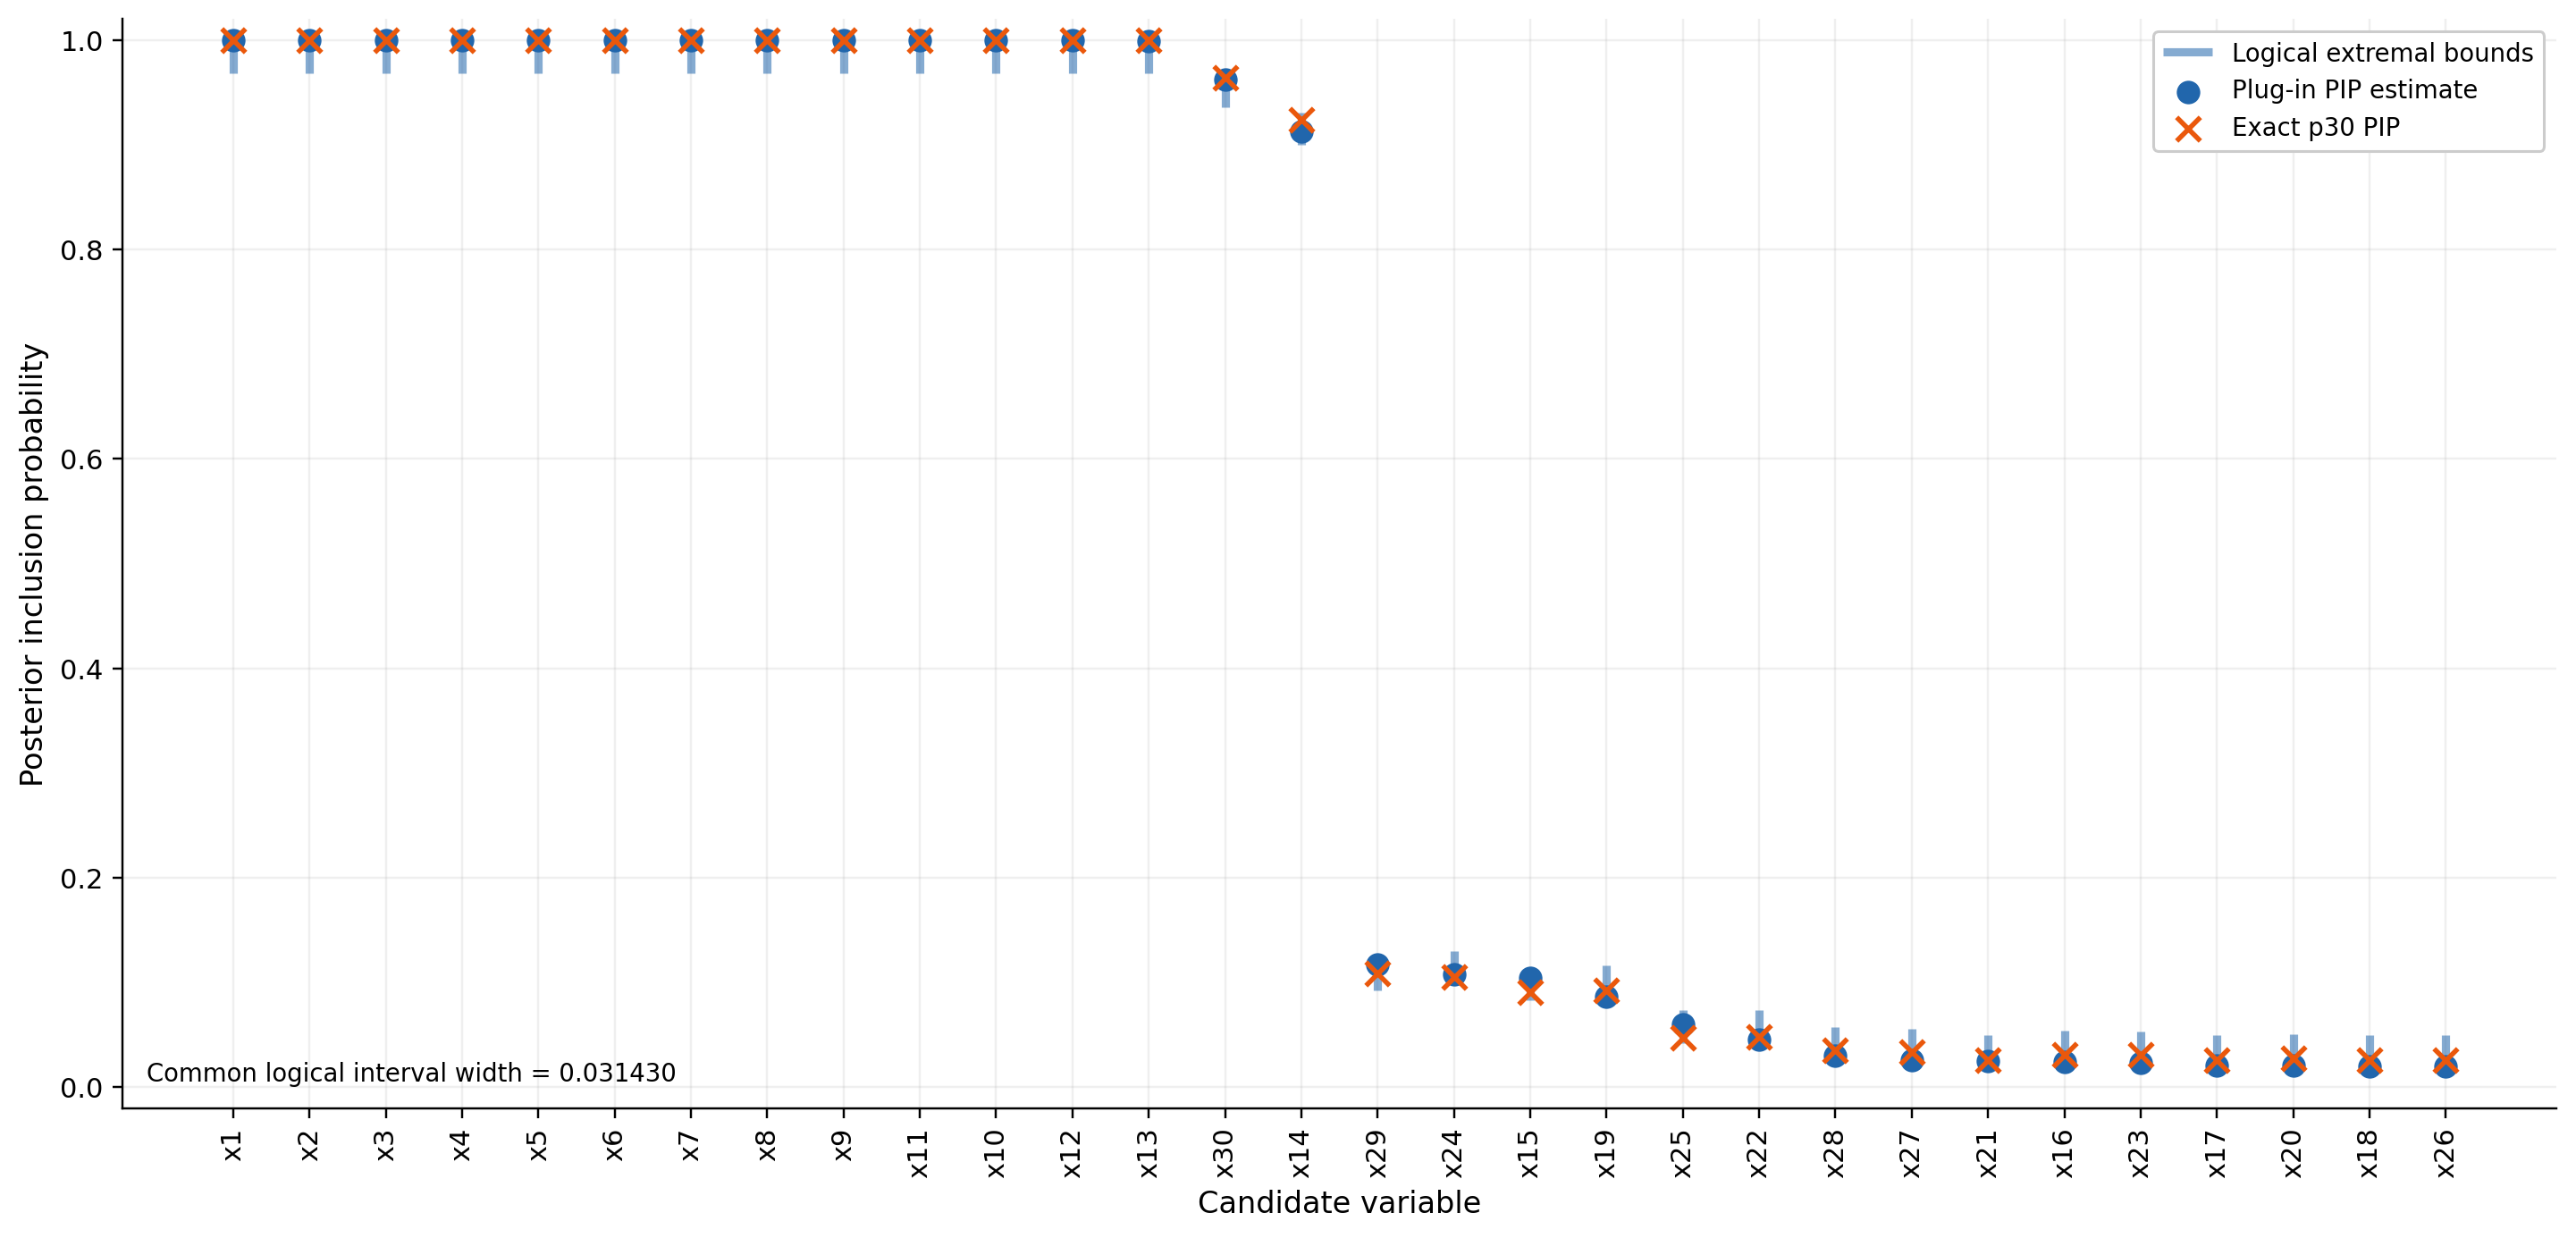

In [24]:
# ============================================================
# PIP VALIDATION FIGURE:
# PIP_PLUGIN_VS_EXACT_WITH_BOUNDS.png
#
# Correct logical extremal bounds:
#
#   PIP_min_j = Z_{j,E}^+ / Z_hat
#
#   PIP_max_j = 1 - Z_{j,E}^- / Z_hat
#
# Therefore:
#
#   PIP_max_j - PIP_min_j
#       =
#   1 - Z_E / Z_hat
#
# which is the SAME width for every candidate variable.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.special import logsumexp
from IPython.display import display, Image


# ============================================================
# Output directory
# ============================================================

PIP_PLUGIN_DIR = (
    OUTPUT_DIR
    / "pip_plugin"
)

PIP_PLUGIN_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

figure_path = (
    PIP_PLUGIN_DIR
    / "PIP_PLUGIN_VS_EXACT_WITH_BOUNDS.png"
)


# ============================================================
# Requirements
# ============================================================

required_objects = [
    "pip_plugin",
    "pip_lower",
    "pip_upper",
    "candidate_names",
    "P",
]

missing = [
    name
    for name in required_objects
    if name not in globals()
]

if missing:

    raise RuntimeError(
        "Run the corrected canonical BFG/recovery "
        "variable-map cell first. Missing objects: "
        + ", ".join(missing)
    )


# ============================================================
# Exact p30 PIPs for validation
# ============================================================

exact_pip = None

if (
    "EXACT_REF_DIR"
    in globals()
):

    exact_pip_path = (
        EXACT_REF_DIR
        / "exact_global_pips.csv"
    )

    if exact_pip_path.is_file():

        exact_df = pd.read_csv(
            exact_pip_path
        )

        exact_map = dict(
            zip(
                exact_df[
                    "predictor"
                ].astype(str),
                exact_df[
                    "exact_global_pip"
                ].astype(float),
            )
        )

        exact_pip = np.array(
            [
                exact_map[
                    name
                ]
                for name
                in candidate_names
            ],
            dtype=np.float64,
        )


# ============================================================
# Audit logical widths
# ============================================================

pip_width = (
    pip_upper
    - pip_lower
)

common_width = float(
    pip_width[0]
)

if not np.allclose(
    pip_width,
    common_width,
    rtol=0.0,
    atol=1e-10,
):

    raise RuntimeError(
        "Logical PIP bounds do not have a common width. "
        f"Observed range: "
        f"[{pip_width.min():.12f}, "
        f"{pip_width.max():.12f}]"
    )


if (
    "unexplored_mass"
    in globals()
):

    if not np.isclose(
        common_width,
        float(
            unexplored_mass
        ),
        rtol=0.0,
        atol=1e-10,
    ):

        raise RuntimeError(
            "Logical PIP width does not equal "
            "the estimated unexplored posterior mass."
        )


# ============================================================
# Plug-in estimates must lie inside bounds
# ============================================================

plugin_inside = (
    (
        pip_plugin
        >= pip_lower
        - 1e-10
    )
    &
    (
        pip_plugin
        <= pip_upper
        + 1e-10
    )
)

if not np.all(
    plugin_inside
):

    bad = np.where(
        ~plugin_inside
    )[0]

    raise RuntimeError(
        "Some plug-in PIPs fall outside logical bounds: "
        + ", ".join(
            candidate_names[j]
            for j in bad
        )
    )


# ============================================================
# Sort by plug-in PIP, descending
# ============================================================

order = np.argsort(
    -pip_plugin,
    kind="stable",
)

names_ord = [
    candidate_names[j]
    for j in order
]

plugin_ord = (
    pip_plugin[
        order
    ]
)

lower_ord = (
    pip_lower[
        order
    ]
)

upper_ord = (
    pip_upper[
        order
    ]
)

if exact_pip is not None:

    exact_ord = (
        exact_pip[
            order
        ]
    )


# ============================================================
# Figure
# ============================================================

plt.rcParams.update(
    {
        "font.family":
            "DejaVu Sans",

        "font.size":
            10,

        "axes.labelsize":
            11,

        "axes.spines.top":
            False,

        "axes.spines.right":
            False,
    }
)


fig, ax = plt.subplots(
    figsize=(
        13.2,
        6.4,
    )
)


x = np.arange(
    P
)


# ------------------------------------------------------------
# Logical intervals
# ------------------------------------------------------------

ax.vlines(
    x,
    lower_ord,
    upper_ord,
    color="#2166ac",
    linewidth=3.0,
    alpha=0.55,
    label=(
        "Logical extremal bounds"
    ),
)


# ------------------------------------------------------------
# Plug-in PIP
# ------------------------------------------------------------

ax.scatter(
    x,
    plugin_ord,
    color="#2166ac",
    s=58,
    zorder=3,
    label=(
        "Plug-in PIP estimate"
    ),
)


# ------------------------------------------------------------
# Exact p30 truth
# ------------------------------------------------------------

if exact_pip is not None:

    ax.scatter(
        x,
        exact_ord,
        marker="x",
        color="#ea580c",
        s=75,
        linewidths=1.8,
        zorder=4,
        label=(
            "Exact p30 PIP"
        ),
    )


# ============================================================
# Axes
# ============================================================

ax.set_xticks(
    x
)

ax.set_xticklabels(
    names_ord,
    rotation=90,
)

ax.set_ylim(
    -0.02,
    1.02,
)

ax.set_xlabel(
    "Candidate variable"
)

ax.set_ylabel(
    "Posterior inclusion probability"
)

ax.grid(
    True,
    alpha=0.20,
)

ax.legend(
    loc="upper right",
    framealpha=1,
)


# ============================================================
# Optional common-width annotation
# ============================================================

ax.text(
    0.01,
    0.02,
    (
        "Common logical interval width = "
        f"{common_width:.6f}"
    ),
    transform=ax.transAxes,
    fontsize=9,
    ha="left",
    va="bottom",
)


fig.tight_layout()


fig.savefig(
    figure_path,
    dpi=220,
    bbox_inches="tight",
    facecolor="white",
)


plt.close(
    fig
)


# ============================================================
# Validation against exact p30
# ============================================================

print(
    "Common logical PIP width:",
    f"{common_width:.6f}",
)

print(
    "Observed width range:",
    f"[{pip_width.min():.6f}, "
    f"{pip_width.max():.6f}]",
)

print(
    "Plug-in PIPs inside logical bounds:",
    f"{int(plugin_inside.sum())}/{P}",
)


if exact_pip is not None:

    exact_inside = (
        (
            exact_pip
            >= pip_lower
            - 1e-10
        )
        &
        (
            exact_pip
            <= pip_upper
            + 1e-10
        )
    )

    pip_error = (
        pip_plugin
        - exact_pip
    )

    rmse = float(
        np.sqrt(
            np.mean(
                pip_error ** 2
            )
        )
    )

    mae = float(
        np.mean(
            np.abs(
                pip_error
            )
        )
    )

    print(
        "Exact p30 PIPs inside logical bounds:",
        f"{int(exact_inside.sum())}/{P}",
    )

    print(
        "Plug-in PIP RMSE:",
        f"{rmse:.8f}",
    )

    print(
        "Plug-in PIP MAE:",
        f"{mae:.8f}",
    )


# ============================================================
# Display
# ============================================================

print()

print(
    "Plug-in PIP estimate with logical bounds "
    "and exact p30 benchmark"
)

display(
    Image(
        filename=str(
            figure_path
        )
    )
)


## 20. Posterior model-size distribution

The shell-recovery posterior size distribution is shown as a plug-in curve with shellwise uncertainty, alongside the exact p30 benchmark where available.


Recovery directory:
/content/outputs/shell_recovery/recovery_shell_scores
Recovery shell files: 25

Raw shell posterior-mass sum:
  1.000000000000

Posterior-size uncertainty audit:
  zero-width shells: 22/31
  sampled shells: 9/31

 k       N_k  recovery_evaluations       shell_type  posterior_size_hat  posterior_size_lower  posterior_size_upper  interval_width
 0         1                     0 fully_discovered        0.000000e+00          0.000000e+00          0.000000e+00    0.000000e+00
 1        30                     0 fully_discovered        0.000000e+00          0.000000e+00          0.000000e+00    0.000000e+00
 2       435                     0 fully_discovered       8.792916e-284         8.792916e-284         8.792916e-284    0.000000e+00
 3      4060                  3895           census       1.074484e-261         1.074484e-261         1.074484e-261    0.000000e+00
 4     27405                 27239           census       4.077382e-218         4.077382e-218         4.077

### BFG + shell-recovery posterior model-size distribution

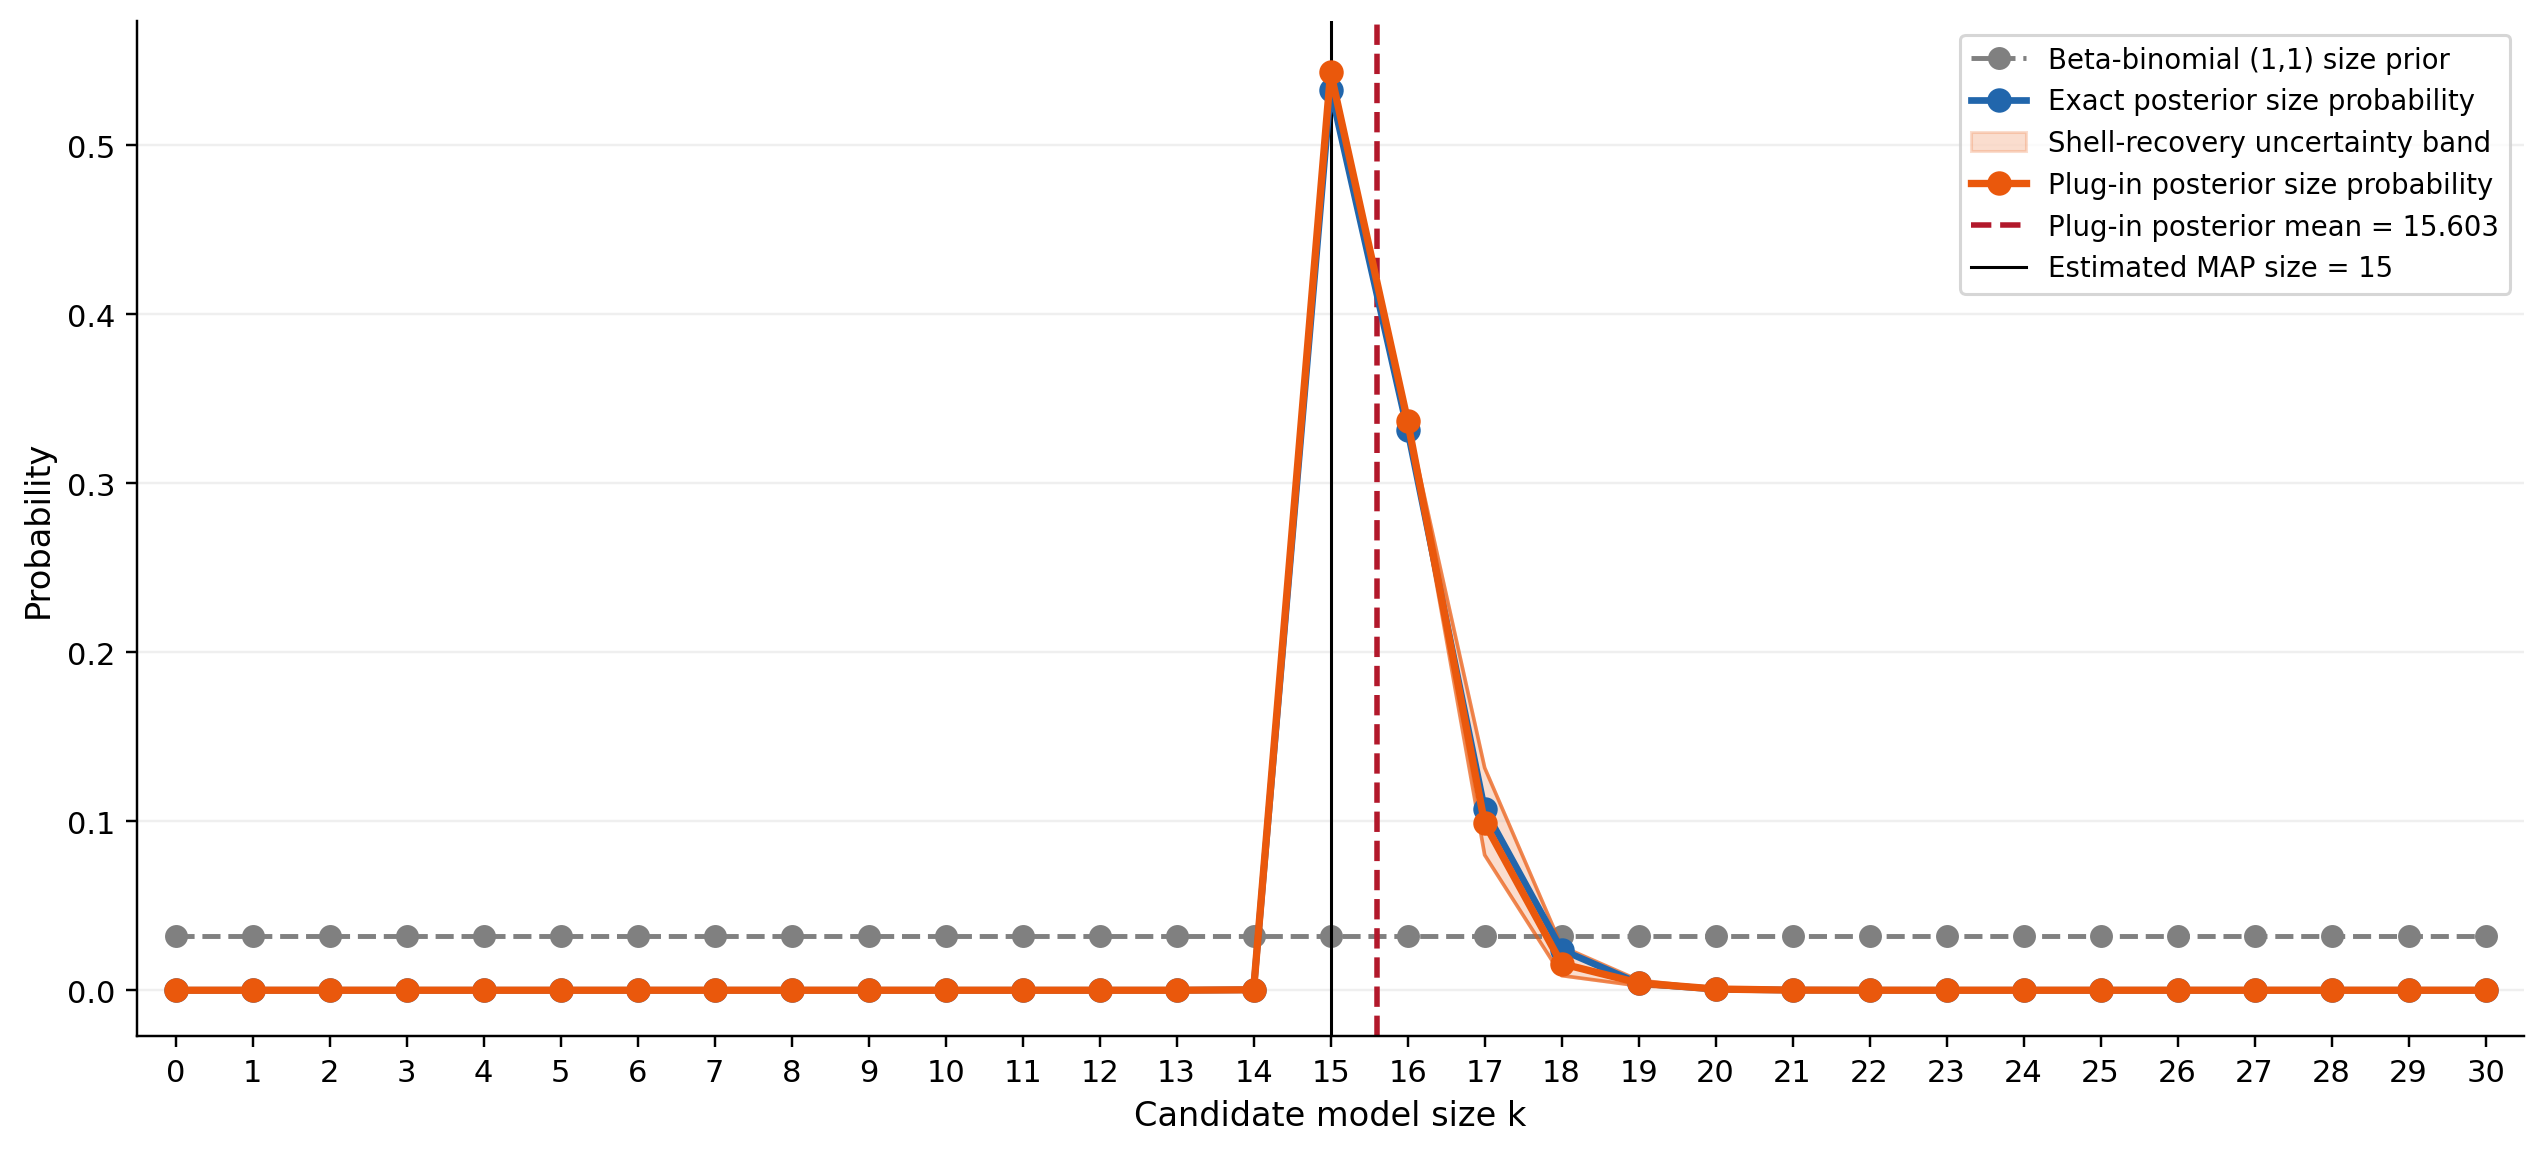

**Notes:** The orange solid line reports the plug-in posterior model-size probability implied by BFG + shell recovery. The shaded orange band represents shell-recovery uncertainty, collapsing to zero in fully discovered or censused reticula. The exact p30 posterior size distribution is overlaid in blue for benchmark validation only. The dashed red line marks the plug-in posterior mean model size, and the black vertical line marks the estimated MAP model size.


Saved figure: /content/outputs/shell_recovery/canonical_figures/10_bfg_recovery_size_posterior_with_bounds.png
Saved table: /content/outputs/shell_recovery/canonical_figures/10_bfg_recovery_size_posterior_with_bounds.csv

Recovery shell files: 25
log Z used: 1119.256485608632
Plug-in posterior mean size: 15.602745
Estimated MAP size: 15
Exact p30 posterior mean size: 15.636704
Zero-width census / fully discovered shells: 22/31
Positive-width sampled shells: 9/31


In [25]:
# ============================================================
# BFG + SHELL-RECOVERY POSTERIOR MODEL-SIZE DISTRIBUTION
#
# Point estimate + shellwise sampling uncertainty
#
#   - censused / fully discovered shells -> zero-width bars
#   - sampled shells -> uncertainty from random remainder sample
#   - exact p30 posterior size distribution overlaid if available
#
# Uses the actual shell_kXX.npz recovery artifacts.
# ============================================================

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from IPython.display import display, Image, Markdown


# ============================================================
# Canonical visual constants
# ============================================================

BLUE   = "#2166ac"
RED    = "#b2182b"
ORANGE = "#ea580c"
GRAY   = "#808080"


# ============================================================
# Configuration
# ============================================================

FIG_DIR = (
    OUTPUT_DIR
    / "canonical_figures"
)

FIG_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

FIG_PATH = (
    FIG_DIR
    / "10_bfg_recovery_size_posterior_with_bounds.png"
)

TABLE_PATH = (
    FIG_DIR
    / "10_bfg_recovery_size_posterior_with_bounds.csv"
)

P = len(
    bfg_result.candidate_names
)

K_GRID = np.arange(
    P + 1
)

LOG_Z_USED = float(
    log_Z_direct
)

# 95% normal-approximation sampling interval
Z_CRIT = 1.959963984540054


# ============================================================
# Locate recovery NPZ directory
# ============================================================

candidate_dirs = []

if "RECOVERY_RUN_DIR" in globals():

    candidate_dirs.append(
        Path(
            RECOVERY_RUN_DIR
        )
    )

candidate_dirs.extend(
    [
        OUTPUT_DIR
        / "recovery_shell_scores",

        OUTPUT_DIR
        / "random_shell_scores",

        OUTPUT_DIR
        / "shell_recovery"
        / "random_shell_scores",
    ]
)

RECOVERY_DIR = None

for candidate in candidate_dirs:

    if (
        candidate.is_dir()
        and len(
            list(
                candidate.glob(
                    "shell_k*.npz"
                )
            )
        ) > 0
    ):

        RECOVERY_DIR = candidate
        break

if RECOVERY_DIR is None:

    raise FileNotFoundError(
        "Could not locate shell_kXX.npz recovery files.\n"
        "Checked:\n"
        + "\n".join(
            str(x)
            for x in candidate_dirs
        )
    )

recovery_files = sorted(
    RECOVERY_DIR.glob(
        "shell_k*.npz"
    )
)

print(
    "Recovery directory:"
)

print(
    RECOVERY_DIR
)

print(
    "Recovery shell files:",
    len(
        recovery_files
    )
)


# ============================================================
# Shell plan
# ============================================================

if "shell_counts" not in globals():

    raise RuntimeError(
        "shell_counts is required."
    )

shell_plan = (
    shell_counts
    .copy()
    .set_index(
        "k"
    )
    .reindex(
        K_GRID
    )
)


# Accept either current or historical recovery column name
if (
    "recovery_evaluations"
    in shell_plan.columns
):

    recovery_col = (
        "recovery_evaluations"
    )

elif (
    "n_k_random"
    in shell_plan.columns
):

    recovery_col = (
        "n_k_random"
    )

else:

    raise KeyError(
        "shell_counts must contain either "
        "'recovery_evaluations' or 'n_k_random'."
    )


# ============================================================
# BFG models
# ============================================================

bfg_df = pd.DataFrame(
    bfg_result.records
).copy()

bfg_df[
    "model_size"
] = (
    bfg_df[
        "model_size"
    ]
    .astype(int)
)

bfg_df[
    "log_score"
] = (
    bfg_df[
        "log_score"
    ]
    .astype(float)
)


# Individual posterior numerator mass normalized by Z_hat
bfg_df[
    "posterior_mass"
] = np.exp(
    bfg_df[
        "log_score"
    ]
    - LOG_Z_USED
)


bfg_shell_mass = (
    bfg_df
    .groupby(
        "model_size"
    )[
        "posterior_mass"
    ]
    .sum()
    .reindex(
        K_GRID,
        fill_value=0.0,
    )
    .to_numpy(
        dtype=float
    )
)


# MAP model size
best_idx = (
    bfg_df[
        "log_score"
    ]
    .idxmax()
)

estimated_map_k = int(
    bfg_df.loc[
        best_idx,
        "model_size",
    ]
)


# ============================================================
# Exact p30 posterior model-size distribution
# ============================================================

exact_size_prob = None
exact_mean_size = None


exact_size_path = (
    EXACT_REF_DIR
    / "exact_model_size_distribution.csv"
)


if exact_size_path.is_file():

    exact_size_df = pd.read_csv(
        exact_size_path
    )

    exact_size_df = (
        exact_size_df
        .set_index(
            "k"
        )
        .reindex(
            K_GRID
        )
    )

    exact_size_prob = (
        exact_size_df[
            "exact_posterior_probability"
        ]
        .to_numpy(
            dtype=float
        )
    )

    exact_mean_size = float(
        np.sum(
            K_GRID
            * exact_size_prob
        )
    )


# ============================================================
# Load recovery shell scores
# ============================================================

recovery_stats = {
    k: {
        "n": 0,
        "sum_w": 0.0,
        "sum_w2": 0.0,
    }
    for k in K_GRID
}


for k in K_GRID:

    n_plan = int(
        shell_plan.loc[
            k,
            recovery_col,
        ]
    )

    if n_plan == 0:
        continue


    shell_path = (
        RECOVERY_DIR
        / f"shell_k{k:02d}.npz"
    )


    if not shell_path.is_file():

        raise FileNotFoundError(
            f"Missing planned recovery shell: "
            f"{shell_path}"
        )


    with np.load(
        shell_path,
        allow_pickle=False,
    ) as z:

        if (
            "scores"
            not in z.files
        ):

            raise KeyError(
                f"{shell_path.name} has no "
                "'scores' array. "
                f"Available keys: "
                f"{z.files}"
            )


        scores = np.asarray(
            z[
                "scores"
            ],
            dtype=np.float64,
        )[:n_plan]


    if (
        len(
            scores
        )
        != n_plan
    ):

        raise RuntimeError(
            f"k={k}: expected "
            f"{n_plan:,} scores, "
            f"found "
            f"{len(scores):,}."
        )


    # Individual posterior masses relative to Z_hat
    w = np.exp(
        scores
        - LOG_Z_USED
    )


    recovery_stats[k][
        "n"
    ] = int(
        len(w)
    )

    recovery_stats[k][
        "sum_w"
    ] = float(
        np.sum(
            w
        )
    )

    recovery_stats[k][
        "sum_w2"
    ] = float(
        np.sum(
            w ** 2
        )
    )


# ============================================================
# Construct shell posterior-size estimates
#
# For sampled shell:
#
#   remainder population R_k
#   observed recovery n_k
#
#   estimated remainder mass:
#
#       R_k * mean(exp(s-Zhat))
#
# equivalently:
#
#       (R_k / n_k) * sum sample weights
#
# ============================================================

rows = []


for k in K_GRID:

    N_k = int(
        shell_plan.loc[
            k,
            "N_k",
        ]
    )

    D_k = int(
        shell_plan.loc[
            k,
            "D_k",
        ]
    )

    remainder_k = int(
        shell_plan.loc[
            k,
            "remainder_k",
        ]
    )

    n_plan = int(
        shell_plan.loc[
            k,
            recovery_col,
        ]
    )

    binding_rule = str(
        shell_plan.loc[
            k,
            "binding_rule",
        ]
    )


    bfg_mass_k = float(
        bfg_shell_mass[k]
    )


    n_obs = int(
        recovery_stats[k][
            "n"
        ]
    )

    sum_w = float(
        recovery_stats[k][
            "sum_w"
        ]
    )

    sum_w2 = float(
        recovery_stats[k][
            "sum_w2"
        ]
    )


    # --------------------------------------------------------
    # Case 1:
    # BFG discovered whole shell
    # --------------------------------------------------------

    if remainder_k == 0:

        p_hat = (
            bfg_mass_k
        )

        se_hat = 0.0

        p_lo = (
            p_hat
        )

        p_hi = (
            p_hat
        )

        shell_type = (
            "fully_discovered"
        )


    # --------------------------------------------------------
    # Case 2:
    # full census of remainder
    # --------------------------------------------------------

    elif (
        n_obs
        == remainder_k
    ):

        recovery_mass_exact = (
            sum_w
        )

        p_hat = (
            bfg_mass_k
            + recovery_mass_exact
        )

        se_hat = 0.0

        p_lo = (
            p_hat
        )

        p_hi = (
            p_hat
        )

        shell_type = (
            "census"
        )


    # --------------------------------------------------------
    # Case 3:
    # random sample from remainder
    # --------------------------------------------------------

    else:

        if n_obs <= 0:

            raise RuntimeError(
                f"k={k}: positive remainder "
                f"{remainder_k:,}, but no recovery "
                "scores were loaded."
            )


        sampling_fraction = (
            n_obs
            / remainder_k
        )


        expansion = (
            remainder_k
            / n_obs
        )


        # --------------------------------------------
        # Plug-in remainder mass
        # --------------------------------------------

        remainder_mass_hat = (
            expansion
            * sum_w
        )


        p_hat = (
            bfg_mass_k
            + remainder_mass_hat
        )


        # --------------------------------------------
        # Sampling variance
        #
        # y_i = exp(score_i - Zhat)
        #
        # Total estimator:
        #
        #   R * ybar
        #
        # SRSWOR variance:
        #
        #   Var(total_hat)
        #   =
        #   R^2 (1-f) s^2 / n
        # --------------------------------------------

        if n_obs > 1:

            sample_variance = (
                sum_w2
                - (
                    sum_w ** 2
                    / n_obs
                )
            ) / (
                n_obs
                - 1
            )


            sample_variance = max(
                0.0,
                float(
                    sample_variance
                ),
            )


            variance_total = (
                remainder_k ** 2
                * (
                    1.0
                    - sampling_fraction
                )
                * sample_variance
                / n_obs
            )


            se_hat = math.sqrt(
                max(
                    0.0,
                    variance_total,
                )
            )


        else:

            se_hat = 0.0


        # --------------------------------------------
        # 95% sampling interval
        # --------------------------------------------

        p_lo = max(
            bfg_mass_k
            + sum_w,
            p_hat
            - Z_CRIT
            * se_hat,
        )


        p_hi = (
            p_hat
            + Z_CRIT
            * se_hat
        )


        shell_type = (
            "sampled"
        )


    # Posterior probabilities cannot exceed one
    p_lo = float(
        np.clip(
            p_lo,
            0.0,
            1.0,
        )
    )

    p_hat = float(
        np.clip(
            p_hat,
            0.0,
            1.0,
        )
    )

    p_hi = float(
        np.clip(
            p_hi,
            0.0,
            1.0,
        )
    )


    rows.append(
        {
            "k":
                int(k),

            "N_k":
                N_k,

            "D_k":
                D_k,

            "remainder_k":
                remainder_k,

            "recovery_evaluations":
                n_obs,

            "binding_rule":
                binding_rule,

            "shell_type":
                shell_type,

            "posterior_size_hat":
                p_hat,

            "posterior_size_se":
                se_hat,

            "posterior_size_lower":
                p_lo,

            "posterior_size_upper":
                p_hi,

            "interval_width":
                (
                    p_hi
                    - p_lo
                ),
        }
    )


size_summary = pd.DataFrame(
    rows
)


# ============================================================
# Normalize plug-in shell probabilities
#
# Numerical differences may mean the shell estimates sum to
# something microscopically different from 1.
# ============================================================

raw_total = float(
    size_summary[
        "posterior_size_hat"
    ].sum()
)


print()

print(
    "Raw shell posterior-mass sum:"
)

print(
    f"  {raw_total:.12f}"
)


# Since these came from the same Z_hat, they should already
# sum almost exactly to one.
if not np.isclose(
    raw_total,
    1.0,
    rtol=0.0,
    atol=1e-8,
):

    print(
        "WARNING: shell posterior masses "
        "do not sum to 1 within 1e-8."
    )


# ============================================================
# Posterior mean size
# ============================================================

p_hat_vec = (
    size_summary[
        "posterior_size_hat"
    ]
    .to_numpy(
        dtype=float
    )
)


posterior_mean_hat = float(
    np.sum(
        K_GRID
        * p_hat_vec
    )
    / np.sum(
        p_hat_vec
    )
)


# ============================================================
# Beta-binomial(1,1) size prior
#
# Uniform over model size:
#
#     P(k) = 1/(P+1)
# ============================================================

size_prior = np.full(
    P + 1,
    1.0
    / (
        P + 1
    ),
    dtype=float,
)


# ============================================================
# Diagnostics
# ============================================================

zero_width = np.isclose(
    size_summary[
        "interval_width"
    ],
    0.0,
    atol=1e-14,
)


print()

print(
    "Posterior-size uncertainty audit:"
)

print(
    "  zero-width shells:",
    f"{int(zero_width.sum())}/{P + 1}",
)

print(
    "  sampled shells:",
    f"{int((~zero_width).sum())}/{P + 1}",
)

print()

print(
    size_summary[
        [
            "k",
            "N_k",
            "recovery_evaluations",
            "shell_type",
            "posterior_size_hat",
            "posterior_size_lower",
            "posterior_size_upper",
            "interval_width",
        ]
    ]
    .to_string(
        index=False
    )
)


# ============================================================
# Plot
# ============================================================

plt.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "font.size": 10,
        "axes.labelsize": 11,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

fig, ax = plt.subplots(
    figsize=(14, 6.5)
)

# ------------------------------------------------------------
# Extract vectors
# ------------------------------------------------------------

p_hat = (
    size_summary["posterior_size_hat"]
    .to_numpy(dtype=float)
)

p_lo = (
    size_summary["posterior_size_lower"]
    .to_numpy(dtype=float)
)

p_hi = (
    size_summary["posterior_size_upper"]
    .to_numpy(dtype=float)
)

# ------------------------------------------------------------
# Prior
# ------------------------------------------------------------

ax.plot(
    K_GRID,
    size_prior,
    "o--",
    color=GRAY,
    lw=1.6,
    ms=6.5,
    label="Beta-binomial (1,1) size prior",
)

# ------------------------------------------------------------
# Exact p30 benchmark
# ------------------------------------------------------------

if exact_size_prob is not None:
    ax.plot(
        K_GRID,
        exact_size_prob,
        "o-",
        color=BLUE,
        lw=2.2,
        ms=7,
        label="Exact posterior size probability",
        zorder=3,
    )

# ------------------------------------------------------------
# Plug-in uncertainty band
# ------------------------------------------------------------

ax.fill_between(
    K_GRID,
    p_lo,
    p_hi,
    color=ORANGE,
    alpha=0.20,
    label="Shell-recovery uncertainty band",
    zorder=1,
)

# Optional: faint lower/upper boundary lines
ax.plot(
    K_GRID,
    p_lo,
    "-",
    color=ORANGE,
    lw=1.2,
    alpha=0.65,
    zorder=2,
)

ax.plot(
    K_GRID,
    p_hi,
    "-",
    color=ORANGE,
    lw=1.2,
    alpha=0.65,
    zorder=2,
)

# ------------------------------------------------------------
# Plug-in posterior size probability (central estimate)
# ------------------------------------------------------------

ax.plot(
    K_GRID,
    p_hat,
    "o-",
    color=ORANGE,
    lw=2.4,
    ms=7,
    label="Plug-in posterior size probability",
    zorder=4,
)

# ------------------------------------------------------------
# Posterior mean
# ------------------------------------------------------------

ax.axvline(
    posterior_mean_hat,
    color=RED,
    ls="--",
    lw=1.8,
    label=f"Plug-in posterior mean = {posterior_mean_hat:.3f}",
)

# ------------------------------------------------------------
# MAP size
# ------------------------------------------------------------

ax.axvline(
    estimated_map_k,
    color="black",
    lw=1.0,
    label=f"Estimated MAP size = {estimated_map_k}",
)

# ============================================================
# Axes
# ============================================================

ax.set(
    xlabel="Candidate model size k",
    ylabel="Probability",
    xticks=range(P + 1),
    xlim=(-0.5, P + 0.5),
)

ax.grid(
    axis="y",
    alpha=0.20,
)

ax.legend(
    fontsize=9,
    loc="upper right",
)

fig.subplots_adjust(
    bottom=0.17
)

fig.savefig(
    FIG_PATH,
    dpi=220,
    bbox_inches="tight",
    facecolor="white",
)

plt.close(fig)

# ============================================================
# Save table
# ============================================================

size_summary.to_csv(
    TABLE_PATH,
    index=False,
)

# ============================================================
# Display
# ============================================================

display(
    Markdown(
        "### BFG + shell-recovery posterior model-size distribution"
    )
)

display(
    Image(
        filename=str(FIG_PATH)
    )
)

display(
    Markdown(
        "**Notes:** The orange solid line reports the plug-in posterior "
        "model-size probability implied by BFG + shell recovery. The shaded "
        "orange band represents shell-recovery uncertainty, collapsing to zero "
        "in fully discovered or censused reticula. The exact p30 posterior size "
        "distribution is overlaid in blue for benchmark validation only. The "
        "dashed red line marks the plug-in posterior mean model size, and the "
        "black vertical line marks the estimated MAP model size."
    )
)

# ============================================================
# Final audit
# ============================================================

print()
print("Saved figure:", FIG_PATH)
print("Saved table:", TABLE_PATH)
print()
print("Recovery shell files:", len(recovery_files))
print("log Z used:", f"{LOG_Z_USED:.12f}")
print("Plug-in posterior mean size:", f"{posterior_mean_hat:.6f}")
print("Estimated MAP size:", estimated_map_k)

if exact_mean_size is not None:
    print("Exact p30 posterior mean size:", f"{exact_mean_size:.6f}")

print(
    "Zero-width census / fully discovered shells:",
    f"{int(zero_width.sum())}/{P + 1}",
)
print(
    "Positive-width sampled shells:",
    f"{int((~zero_width).sum())}/{P + 1}",
)

## 21. Pass 2: posterior coefficient reconstruction

This cell recomputes conditional coefficient posterior distributions from posterior model draws under the BFG + shell-recovery approximation, using the same Zellner g-prior moments as `gpubma`. It saves the 257-point density artifact and coefficient summary, but does not plot the canonical figure.


In [26]:
# ============================================================
# PASS 2 — BFG + SHELL-RECOVERY COEFFICIENT DISTRIBUTIONS
#
# Robust version:
#   1. Reuses BFG sufficient statistics / residualized design
#      whenever available.
#   2. Does NOT assume global `y` is the 2,000-observation vector.
#   3. Recomputes coefficient posterior distributions from the
#      BFG + weighted shell-recovery posterior approximation.
#
# Zellner g-prior Pass-2 formulas (same as gpubma):
#
#   E[beta | M,y]
#       = shrink * beta_hat
#
#   Var(beta | M,y)
#       = E[sigma^2 | M,y] * shrink * diag((X'X)^-1)
#
#   shrink = g/(1+g)
#
#   E[sigma^2 | M,y]
#       =
#       [tss_norm - shrink*(ess_always + ess_M)]
#       / (df_resid - 2)
#
# Recovery model weight:
#
#   expansion_k * exp(log_score)
#
#   expansion_k = (N_k - D_k) / n_k
#
# ============================================================

import gc
import math
import time
import inspect

import numpy as np
import pandas as pd

from pathlib import Path
from scipy.linalg import cho_factor, cho_solve
from scipy.ndimage import gaussian_filter1d
from scipy.stats import t as student_t
from scipy.integrate import trapezoid


from IPython.display import display


# ============================================================
# 0. Configuration
# ============================================================

MODEL_DRAWS = 2_000_000

MAX_COEF_DRAWS_PER_VARIABLE = 200_000

N_GRID = 257

SMOOTH_SIGMA_BINS = 2.0

RNG_SEED = 20260915

rng = np.random.default_rng(
    RNG_SEED
)


PASS2_DIR = (
    OUTPUT_DIR
    / "pass2_coefficients"
)

PASS2_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


DENSITY_PATH = (
    PASS2_DIR
    / "coefficient_densities_bfg_recovery.npz"
)


SUMMARY_PATH = (
    PASS2_DIR
    / "coefficient_summary_bfg_recovery.csv"
)


# ============================================================
# 1. Required objects
# ============================================================

required = [
    "bfg_result",
    "shell_counts",
    "log_Z_direct",
    "pip_plugin",
    "pip_lower",
    "pip_upper",
]

missing = [
    name
    for name in required
    if name not in globals()
]

if missing:

    raise RuntimeError(
        "Missing prerequisite objects: "
        + ", ".join(missing)
    )


candidate_names = list(
    bfg_result.candidate_names
)

P = len(
    candidate_names
)

LOG_Z = float(
    log_Z_direct
)


pip_plugin = np.asarray(
    pip_plugin,
    dtype=np.float64,
)

pip_lower = np.asarray(
    pip_lower,
    dtype=np.float64,
)

pip_upper = np.asarray(
    pip_upper,
    dtype=np.float64,
)


if not (
    len(pip_plugin)
    == len(pip_lower)
    == len(pip_upper)
    == P
):

    raise RuntimeError(
        "PIP arrays do not have length P."
    )


# ============================================================
# 2. Locate recovery NPZ directory
# ============================================================

candidate_dirs = []


if (
    "RECOVERY_RUN_DIR"
    in globals()
):

    candidate_dirs.append(
        Path(
            RECOVERY_RUN_DIR
        )
    )


candidate_dirs.extend(
    [
        OUTPUT_DIR
        / "recovery_shell_scores",

        OUTPUT_DIR
        / "random_shell_scores",

        OUTPUT_DIR
        / "shell_recovery"
        / "recovery_shell_scores",
    ]
)


RECOVERY_DIR = None


for candidate in candidate_dirs:

    if (
        candidate.is_dir()
        and len(
            list(
                candidate.glob(
                    "shell_k*.npz"
                )
            )
        ) > 0
    ):

        RECOVERY_DIR = candidate
        break


if RECOVERY_DIR is None:

    raise FileNotFoundError(
        "Could not locate recovery shell NPZ files.\n"
        "Checked:\n"
        + "\n".join(
            str(p)
            for p
            in candidate_dirs
        )
    )


print(
    "Recovery directory:"
)

print(
    RECOVERY_DIR
)


# ============================================================
# 3. General helpers
# ============================================================

def as_numpy64(
    obj,
):
    """
    Convert numpy / pandas / torch object to float64 numpy.
    """

    if obj is None:
        return None

    if hasattr(
        obj,
        "detach",
    ):

        obj = (
            obj
            .detach()
            .cpu()
            .numpy()
        )

    elif isinstance(
        obj,
        (
            pd.Series,
            pd.DataFrame,
        ),
    ):

        obj = obj.to_numpy()

    return np.asarray(
        obj,
        dtype=np.float64,
    )


def safe_attr(
    obj,
    names,
):

    for name in names:

        try:

            if hasattr(
                obj,
                name,
            ):

                value = getattr(
                    obj,
                    name,
                )

                if value is not None:
                    return value

        except Exception:
            pass

    return None


def detect_mask_key(
    z,
):

    candidates = [
        "masks",
        "model_ids",
        "model_id",
        "models",
        "mask",
    ]

    for key in candidates:

        if key in z.files:
            return key

    raise KeyError(
        "No model-mask array found. "
        f"Available keys: {z.files}"
    )


def detect_bfg_mask_column(
    df,
):

    for column in [
        "model_id",
        "mask",
        "model_mask",
    ]:

        if column in df.columns:
            return column

    raise KeyError(
        "Could not identify BFG model-mask column. "
        f"Available columns: {list(df.columns)}"
    )


def detect_bfg_score_column(
    df,
):

    for column in [
        "log_score",
        "log_posterior_numerator",
        "log_numerator",
        "score",
    ]:

        if column in df.columns:
            return column

    raise KeyError(
        "Could not identify BFG score column. "
        f"Available columns: {list(df.columns)}"
    )


def mask_indices(
    mask,
    p,
):

    mask = int(
        mask
    )

    return np.array(
        [
            j
            for j in range(p)
            if (
                mask
                >> j
            ) & 1
        ],
        dtype=np.intp,
    )


def valid_vector(
    obj,
    n,
):

    try:

        arr = as_numpy64(
            obj
        )

        if arr is None:
            return None

        arr = arr.reshape(
            -1
        )

        if len(
            arr
        ) == n:

            return arr

    except Exception:
        pass

    return None


def valid_matrix(
    obj,
    n=None,
    p=None,
):

    try:

        arr = as_numpy64(
            obj
        )

        if (
            arr is None
            or arr.ndim != 2
        ):

            return None

        if (
            n is not None
            and arr.shape[0] != n
        ):

            return None

        if (
            p is not None
            and arr.shape[1] != p
        ):

            return None

        return arr

    except Exception:
        return None


# ============================================================
# 4. Find a scorer / sufficient-statistics object
#
# This is now the FIRST choice.
#
# We do not need raw y if we can recover:
#
#   Zxx
#   Zxy
#   tss
#   tss_norm
#   df_resid
#   g
#
# ============================================================

def score_candidate_object(
    obj,
):

    score = 0

    cls = type(
        obj
    ).__name__.lower()

    if "scorer" in cls:
        score += 10

    attr_groups = [
        [
            "Zxx",
            "zxx",
        ],
        [
            "Zxy",
            "zxy",
        ],
        [
            "tss",
            "tss_residualized",
        ],
        [
            "tss_norm",
        ],
        [
            "df_resid",
            "df",
        ],
        [
            "g",
        ],
    ]

    for group in attr_groups:

        if any(
            hasattr(
                obj,
                x,
            )
            for x
            in group
        ):

            score += 1

    return score


scorer_candidates = []


for object_name, obj in list(
    globals().items()
):

    try:

        score = score_candidate_object(
            obj
        )

        if score >= 3:

            scorer_candidates.append(
                (
                    score,
                    object_name,
                    obj,
                )
            )

    except Exception:
        pass


scorer_candidates.sort(
    key=lambda z: (
        -z[0],
        z[1],
    )
)


SCORER_OBJ = None
SCORER_NAME = None


if scorer_candidates:

    _, SCORER_NAME, SCORER_OBJ = (
        scorer_candidates[0]
    )


print()

print(
    "Scorer-like object:",
    SCORER_NAME,
)


# ============================================================
# 5. Try to recover sufficient statistics DIRECTLY
# ============================================================

Zxx = None
Zxy = None

tss = None
tss_norm = None

df_resid = None
g = None

k_always = None


if SCORER_OBJ is not None:

    zxx_candidate = safe_attr(
        SCORER_OBJ,
        [
            "Zxx",
            "zxx",
            "gram",
            "XtX",
        ],
    )

    zxy_candidate = safe_attr(
        SCORER_OBJ,
        [
            "Zxy",
            "zxy",
            "xty",
            "Xty",
        ],
    )


    if (
        zxx_candidate is not None
        and zxy_candidate is not None
    ):

        zxx_candidate = as_numpy64(
            zxx_candidate
        )

        zxy_candidate = as_numpy64(
            zxy_candidate
        ).reshape(
            -1
        )


        if (
            zxx_candidate.shape
            == (
                P,
                P,
            )
            and zxy_candidate.shape
            == (
                P,
            )
        ):

            Zxx = (
                zxx_candidate
            )

            Zxy = (
                zxy_candidate
            )


    v = safe_attr(
        SCORER_OBJ,
        [
            "tss",
            "tss_residualized",
            "yTy",
        ],
    )

    if v is not None:

        try:
            tss = float(
                np.asarray(
                    v
                )
            )
        except Exception:
            pass


    v = safe_attr(
        SCORER_OBJ,
        [
            "tss_norm",
            "normalization_tss",
        ],
    )

    if v is not None:

        try:
            tss_norm = float(
                np.asarray(
                    v
                )
            )
        except Exception:
            pass


    v = safe_attr(
        SCORER_OBJ,
        [
            "df_resid",
            "df",
        ],
    )

    if v is not None:

        try:
            df_resid = int(
                v
            )
        except Exception:
            pass


    v = safe_attr(
        SCORER_OBJ,
        [
            "g",
        ],
    )

    if v is not None:

        try:
            g = float(
                v
            )
        except Exception:
            pass


    v = safe_attr(
        SCORER_OBJ,
        [
            "k_always",
        ],
    )

    if v is not None:

        try:
            k_always = int(
                v
            )
        except Exception:
            pass


# ============================================================
# 6. Look for already-existing residualized X_r and y_r
# ============================================================

X_r = None
y_r = None


for name in [
    "X_r",
    "X_resid",
    "X_residualized",
]:

    if name in globals():

        candidate = valid_matrix(
            globals()[
                name
            ],
            p=P,
        )

        if candidate is not None:

            X_r = (
                candidate
            )

            print(
                "Resolved residualized X from:",
                name,
            )

            break


if X_r is None and SCORER_OBJ is not None:

    candidate = safe_attr(
        SCORER_OBJ,
        [
            "X_r",
            "X",
            "x",
        ],
    )

    candidate = valid_matrix(
        candidate,
        p=P,
    )

    if candidate is not None:

        X_r = candidate

        print(
            "Resolved residualized X from scorer."
        )


if X_r is not None:

    n = int(
        X_r.shape[0]
    )

else:

    n = None


if n is not None:

    for name in [
        "y_r",
        "y_resid",
        "y_residualized",
    ]:

        if name in globals():

            candidate = valid_vector(
                globals()[
                    name
                ],
                n,
            )

            if candidate is not None:

                y_r = (
                    candidate
                )

                print(
                    "Resolved residualized y from:",
                    name,
                )

                break


    if (
        y_r is None
        and SCORER_OBJ is not None
    ):

        candidate = safe_attr(
            SCORER_OBJ,
            [
                "y_r",
                "y",
            ],
        )

        candidate = valid_vector(
            candidate,
            n,
        )

        if candidate is not None:

            y_r = candidate

            print(
                "Resolved residualized y from scorer."
            )


# ============================================================
# 7. If sufficient statistics were NOT available,
# derive them from residualized X_r, y_r.
# ============================================================

if (
    Zxx is None
    or Zxy is None
):

    if (
        X_r is not None
        and y_r is not None
    ):

        Zxx = (
            X_r.T
            @ X_r
        )

        Zxy = (
            X_r.T
            @ y_r
        )

        if tss is None:

            tss = float(
                y_r
                @ y_r
            )


# ============================================================
# 8. If we STILL do not have sufficient statistics,
# reconstruct from a complete DataFrame.
#
# Important:
# we explicitly IGNORE scalar / length-1 global `y`.
# ============================================================

source_df = None

outcome_name = None

control_names = [
    "w1",
    "w2",
]


# ------------------------------------------------------------
# Outcome name
# ------------------------------------------------------------

if hasattr(
    bfg_result,
    "outcome",
):

    candidate = getattr(
        bfg_result,
        "outcome",
    )

    if isinstance(
        candidate,
        str,
    ):

        outcome_name = (
            candidate
        )


if outcome_name is None:

    outcome_name = "y"


# ------------------------------------------------------------
# Search all current DataFrames.
#
# Need:
#
#   x1...x30
#   y
#   w1,w2
# ------------------------------------------------------------

needed_columns = set(
    candidate_names
    + [
        outcome_name,
    ]
    + control_names
)


for object_name, obj in list(
    globals().items()
):

    if not isinstance(
        obj,
        pd.DataFrame,
    ):

        continue

    if not needed_columns.issubset(
        obj.columns
    ):

        continue

    if len(
        obj
    ) <= 1:

        continue

    source_df = obj

    print(
        "Resolved complete source DataFrame:",
        object_name,
    )

    break


# ------------------------------------------------------------
# Only reconstruct if necessary
# ------------------------------------------------------------

if (
    Zxx is None
    or Zxy is None
    or tss is None
    or tss_norm is None
):

    if source_df is not None:

        X_raw = (
            source_df[
                candidate_names
            ]
            .to_numpy(
                dtype=np.float64
            )
        )

        y_raw = (
            source_df[
                outcome_name
            ]
            .to_numpy(
                dtype=np.float64
            )
            .reshape(
                -1
            )
        )

        C_raw = (
            source_df[
                control_names
            ]
            .to_numpy(
                dtype=np.float64
            )
        )


        n_raw = len(
            source_df
        )


        print()

        print(
            "Raw source design:"
        )

        print(
            "  X:",
            X_raw.shape,
        )

        print(
            "  y:",
            y_raw.shape,
        )

        print(
            "  controls:",
            C_raw.shape,
        )


        if not (
            len(y_raw)
            == X_raw.shape[0]
            == C_raw.shape[0]
            == n_raw
        ):

            raise RuntimeError(
                "Source DataFrame dimensions are inconsistent."
            )


        # ----------------------------------------------------
        # Reproduce API always-in block:
        #
        # intercept + w1 + w2
        # ----------------------------------------------------

        A = np.column_stack(
            [
                np.ones(
                    n_raw,
                    dtype=np.float64,
                ),
                C_raw,
            ]
        )


        Q, _ = np.linalg.qr(
            A,
            mode="reduced",
        )


        X_r_rebuilt = (
            X_raw
            - Q
            @ (
                Q.T
                @ X_raw
            )
        )


        y_r_rebuilt = (
            y_raw
            - Q
            @ (
                Q.T
                @ y_raw
            )
        )


        # Prefer rebuilt design if no residual design existed
        if X_r is None:

            X_r = (
                X_r_rebuilt
            )

        if y_r is None:

            y_r = (
                y_r_rebuilt
            )


        if Zxx is None:

            Zxx = (
                X_r_rebuilt.T
                @ X_r_rebuilt
            )


        if Zxy is None:

            Zxy = (
                X_r_rebuilt.T
                @ y_r_rebuilt
            )


        if tss is None:

            tss = float(
                y_r_rebuilt
                @ y_r_rebuilt
            )


        if tss_norm is None:

            yc = (
                y_raw
                - y_raw.mean()
            )

            tss_norm = float(
                yc
                @ yc
            )


        if n is None:

            n = (
                n_raw
            )


        if k_always is None:

            k_always = (
                len(
                    control_names
                )
            )


# ============================================================
# 9. Last-resort scalar metadata from globals / result
# ============================================================

if n is None:

    if (
        X_r is not None
    ):

        n = int(
            X_r.shape[0]
        )

    elif source_df is not None:

        n = int(
            len(
                source_df
            )
        )

    elif hasattr(
        bfg_result,
        "n_obs",
    ):

        n = int(
            bfg_result.n_obs
        )


# ------------------------------------------------------------
# g
# ------------------------------------------------------------

if g is None:

    if hasattr(
        bfg_result,
        "g_spec",
    ):

        gs = getattr(
            bfg_result,
            "g_spec",
        )

        if hasattr(
            gs,
            "g",
        ):

            g = float(
                gs.g
            )


if g is None:

    # Canonical benchmark default
    g = float(
        max(
            n,
            P ** 2,
        )
    )


# ------------------------------------------------------------
# df
# ------------------------------------------------------------

if df_resid is None:

    if hasattr(
        bfg_result,
        "df_resid",
    ):

        try:

            df_resid = int(
                bfg_result.df_resid
            )

        except Exception:
            pass


if df_resid is None:

    # Canonical always_prior="shrink"
    df_resid = int(
        n - 1
    )


# ------------------------------------------------------------
# tss_norm globals
# ------------------------------------------------------------

if tss_norm is None:

    for name in [
        "tss_norm",
        "TSS_NORM",
    ]:

        if name in globals():

            try:

                tss_norm = float(
                    globals()[
                        name
                    ]
                )

                break

            except Exception:
                pass


# ------------------------------------------------------------
# tss
# ------------------------------------------------------------

if (
    tss is None
    and y_r is not None
):

    tss = float(
        y_r
        @ y_r
    )


# ------------------------------------------------------------
# k_always
# ------------------------------------------------------------

if k_always is None:

    k_always = 2


# ============================================================
# 10. Hard audit of sufficient statistics
# ============================================================

if Zxx is None:

    raise RuntimeError(
        "Could not recover Zxx = X_r'X_r."
    )


if Zxy is None:

    raise RuntimeError(
        "Could not recover Zxy = X_r'y_r."
    )


if tss is None:

    raise RuntimeError(
        "Could not recover residualized TSS."
    )


if tss_norm is None:

    raise RuntimeError(
        "Could not recover normalization TSS.\n"
        "The BFG scorer or original DataFrame must provide it."
    )


if n is None:

    raise RuntimeError(
        "Could not determine n."
    )


Zxx = np.asarray(
    Zxx,
    dtype=np.float64,
)


Zxy = np.asarray(
    Zxy,
    dtype=np.float64,
).reshape(
    -1
)


if Zxx.shape != (
    P,
    P,
):

    raise RuntimeError(
        f"Zxx has shape {Zxx.shape}, expected {(P, P)}."
    )


if Zxy.shape != (
    P,
):

    raise RuntimeError(
        f"Zxy has shape {Zxy.shape}, expected {(P,)}."
    )


if not np.all(
    np.isfinite(
        Zxx
    )
):

    raise RuntimeError(
        "Zxx contains non-finite values."
    )


if not np.all(
    np.isfinite(
        Zxy
    )
):

    raise RuntimeError(
        "Zxy contains non-finite values."
    )


if tss_norm < tss:

    if (
        tss - tss_norm
        <= 1e-9
        * max(
            1.0,
            abs(
                tss_norm
            ),
        )
    ):

        tss_norm = (
            tss
        )

    else:

        raise RuntimeError(
            "tss_norm < residualized tss by more than "
            "numerical tolerance."
        )


shrink = (
    g
    / (
        1.0
        + g
    )
)


ess_always = (
    tss_norm
    - tss
)


print()

print(
    "PASS-2 sufficient-statistics audit"
)

print(
    "  n:",
    n,
)

print(
    "  P:",
    P,
)

print(
    "  Zxx:",
    Zxx.shape,
)

print(
    "  Zxy:",
    Zxy.shape,
)

print(
    "  tss:",
    f"{tss:.12f}",
)

print(
    "  tss_norm:",
    f"{tss_norm:.12f}",
)

print(
    "  ess_always:",
    f"{ess_always:.12f}",
)

print(
    "  df_resid:",
    df_resid,
)

print(
    "  g:",
    f"{g:.12f}",
)

print(
    "  shrink:",
    f"{shrink:.12f}",
)

print(
    "  k_always:",
    k_always,
)


assert df_resid > 2

assert g > 0

assert ess_always >= -1e-8 * max(
    1.0,
    abs(
        tss_norm
    ),
)


print()

print(
    "PASS: sufficient statistics are internally consistent."
)


# ============================================================
# 11. Shell plan
# ============================================================

shell_plan = (
    shell_counts
    .copy()
    .set_index(
        "k"
    )
)


if (
    "recovery_evaluations"
    in shell_plan.columns
):

    recovery_col = (
        "recovery_evaluations"
    )

elif (
    "n_k_random"
    in shell_plan.columns
):

    recovery_col = (
        "n_k_random"
    )

else:

    raise KeyError(
        "shell_counts must contain either "
        "'recovery_evaluations' or 'n_k_random'."
    )


# ============================================================
# 12. Build BFG + recovery pseudo-population
# ============================================================

support_masks = []

support_logmass = []


# ------------------------------------------------------------
# BFG
# ------------------------------------------------------------

bfg_df = pd.DataFrame(
    bfg_result.records
).copy()


bfg_mask_col = (
    detect_bfg_mask_column(
        bfg_df
    )
)


bfg_score_col = (
    detect_bfg_score_column(
        bfg_df
    )
)


bfg_masks = (
    bfg_df[
        bfg_mask_col
    ]
    .to_numpy(
        dtype=np.uint64
    )
)


bfg_scores = (
    bfg_df[
        bfg_score_col
    ]
    .to_numpy(
        dtype=np.float64
    )
)


support_masks.append(
    bfg_masks
)


support_logmass.append(
    bfg_scores
)


print()

print(
    "BFG support:",
    f"{len(bfg_masks):,}",
)


# ------------------------------------------------------------
# Recovery shells
# ------------------------------------------------------------

recovery_models_loaded = 0


for k in range(
    P + 1
):

    if k not in shell_plan.index:
        continue


    n_k = int(
        shell_plan.loc[
            k,
            recovery_col,
        ]
    )


    if n_k <= 0:
        continue


    remainder_k = int(
        shell_plan.loc[
            k,
            "remainder_k",
        ]
    )


    if remainder_k <= 0:
        continue


    shell_path = (
        RECOVERY_DIR
        / f"shell_k{k:02d}.npz"
    )


    if not shell_path.is_file():

        raise FileNotFoundError(
            shell_path
        )


    with np.load(
        shell_path,
        allow_pickle=False,
    ) as z:

        if (
            "scores"
            not in z.files
        ):

            raise KeyError(
                f"{shell_path.name}: missing scores."
            )


        mask_key = (
            detect_mask_key(
                z
            )
        )


        masks_k = np.asarray(
            z[
                mask_key
            ],
            dtype=np.uint64,
        )[:n_k]


        scores_k = np.asarray(
            z[
                "scores"
            ],
            dtype=np.float64,
        )[:n_k]


    if (
        len(masks_k)
        != n_k
        or len(scores_k)
        != n_k
    ):

        raise RuntimeError(
            f"k={k}: expected {n_k:,} recovery rows "
            f"but found masks={len(masks_k):,}, "
            f"scores={len(scores_k):,}."
        )


    expansion = (
        remainder_k
        / n_k
    )


    support_masks.append(
        masks_k
    )


    support_logmass.append(
        scores_k
        + math.log(
            expansion
        )
    )


    recovery_models_loaded += (
        n_k
    )


print(
    "Recovery support:",
    f"{recovery_models_loaded:,}",
)


# ============================================================
# 13. Combine pseudo-population
# ============================================================

support_masks = np.concatenate(
    support_masks
)


support_logmass = np.concatenate(
    support_logmass
)


print(
    "Total pseudo-population support:",
    f"{len(support_masks):,}",
)


# ============================================================
# 14. Global posterior weights
# ============================================================

support_p = np.exp(
    support_logmass
    - LOG_Z
)


posterior_mass_sum = float(
    support_p.sum()
)


print()

print(
    "Posterior mass represented before normalization:",
    f"{posterior_mass_sum:.12f}",
)


# Direct estimator should make this extremely close to 1.
if not np.isclose(
    posterior_mass_sum,
    1.0,
    rtol=0.0,
    atol=5e-8,
):

    print(
        "WARNING: pseudo-population posterior mass "
        "is not exactly 1 under log_Z_direct."
    )


# For sampling only, normalize exactly.
support_p /= (
    support_p.sum()
)


# ============================================================
# 15. Draw model states from approximate global posterior
# ============================================================

print()

print(
    "Drawing posterior models:",
    f"{MODEL_DRAWS:,}",
)


cdf = np.cumsum(
    support_p,
    dtype=np.float64,
)


cdf[-1] = 1.0


u = rng.random(
    MODEL_DRAWS
)


sample_index = np.searchsorted(
    cdf,
    u,
    side="right",
)


sampled_masks = np.asarray(
    support_masks[
        sample_index
    ],
    dtype=np.uint64,
)


# Cleanup
del cdf
del u
del sample_index
del support_p
del support_logmass

gc.collect()


# ============================================================
# 16. Select posterior model draws conditional on inclusion
# ============================================================

selected_masks_by_j = {}

all_required_masks = set()


for j in range(
    P
):

    bit = (
        np.uint64(1)
        << np.uint64(j)
    )


    included_positions = np.flatnonzero(
        (
            sampled_masks
            & bit
        )
        != 0
    )


    if len(
        included_positions
    ) == 0:

        selected_masks_by_j[
            j
        ] = np.empty(
            0,
            dtype=np.uint64,
        )

        continue


    if (
        len(
            included_positions
        )
        > MAX_COEF_DRAWS_PER_VARIABLE
    ):

        chosen_positions = (
            rng.choice(
                included_positions,
                size=MAX_COEF_DRAWS_PER_VARIABLE,
                replace=False,
            )
        )

    else:

        chosen_positions = (
            included_positions
        )


    masks_j = np.asarray(
        sampled_masks[
            chosen_positions
        ],
        dtype=np.uint64,
    )


    selected_masks_by_j[
        j
    ] = masks_j


    unique_j = np.unique(
        masks_j
    )


    all_required_masks.update(
        int(mask)
        for mask
        in unique_j
    )


unique_masks = np.array(
    sorted(
        all_required_masks
    ),
    dtype=np.uint64,
)


print()

print(
    "Unique models requiring coefficient Pass 2:",
    f"{len(unique_masks):,}",
)


# ============================================================
# 17. Recompute per-model coefficient posterior parameters
#
# EXACT gpubma Pass-2 formulas.
# ============================================================

model_params = {}


t_pass2 = time.perf_counter()


for count, mask in enumerate(
    unique_masks,
    start=1,
):

    idx = mask_indices(
        mask,
        P,
    )


    if len(
        idx
    ) == 0:

        model_params[
            int(mask)
        ] = {}

        continue


    Z = (
        Zxx[
            np.ix_(
                idx,
                idx,
            )
        ]
    )


    b = (
        Zxy[
            idx
        ]
    )


    # Cholesky factorization
    c, low = cho_factor(
        Z,
        lower=True,
        check_finite=False,
    )


    # OLS conditional on model M
    beta_hat = cho_solve(
        (
            c,
            low,
        ),
        b,
        check_finite=False,
    )


    # diagonal of Z^{-1}
    Zinv_diag = np.diag(
        cho_solve(
            (
                c,
                low,
            ),
            np.eye(
                len(
                    idx
                ),
                dtype=np.float64,
            ),
            check_finite=False,
        )
    )


    # ESS_M = b' Z^{-1} b
    ess = float(
        b
        @ beta_hat
    )


    # --------------------------------------------------------
    # SAME AS gpubma
    # --------------------------------------------------------

    cond_mean = (
        shrink
        * beta_hat
    )


    e_sigma2 = (
        tss_norm
        - shrink
        * (
            ess_always
            + ess
        )
    ) / (
        df_resid
        - 2
    )


    if e_sigma2 <= 0:

        if e_sigma2 > -1e-12:

            e_sigma2 = (
                np.finfo(
                    np.float64
                ).tiny
            )

        else:

            raise RuntimeError(
                f"Negative E[sigma^2] for mask={int(mask)}: "
                f"{e_sigma2}"
            )


    cond_var = (
        e_sigma2
        * shrink
        * Zinv_diag
    )


    # --------------------------------------------------------
    # Student-t representation
    #
    # For t_nu(loc, scale):
    #
    # Var = scale^2 * nu/(nu-2)
    #
    # We need the t distribution to reproduce cond_var.
    # --------------------------------------------------------

    t_scale = np.sqrt(
        np.maximum(
            cond_var
            * (
                df_resid
                - 2
            )
            / df_resid,
            0.0,
        )
    )


    model_params[
        int(
            mask
        )
    ] = {
        int(
            predictor
        ): (
            float(
                mu
            ),
            float(
                scale
            ),
        )
        for (
            predictor,
            mu,
            scale,
        )
        in zip(
            idx,
            cond_mean,
            t_scale,
        )
    }


    if (
        count % 5000
        == 0
    ):

        elapsed = (
            time.perf_counter()
            - t_pass2
        )

        rate = (
            count
            / max(
                elapsed,
                1e-12,
            )
        )

        print(
            f"  {count:,}/"
            f"{len(unique_masks):,} models "
            f"| {elapsed:.1f} s "
            f"| {rate:,.0f} models/s"
        )


pass2_seconds = (
    time.perf_counter()
    - t_pass2
)


print()

print(
    "Coefficient parameter Pass-2 time:",
    f"{pass2_seconds:.2f} s",
)


# ============================================================
# 18. Draw coefficient posterior samples
#
# CONDITIONAL ON VARIABLE INCLUSION.
#
# Exclusion atom beta=0 deliberately omitted,
# matching the canonical exact figure.
# ============================================================

coef_draws = []


for j in range(
    P
):

    masks_j = (
        selected_masks_by_j[
            j
        ]
    )


    if len(
        masks_j
    ) == 0:

        raise RuntimeError(
            f"No posterior inclusion draws for "
            f"{candidate_names[j]}."
        )


    draws_j = np.empty(
        len(
            masks_j
        ),
        dtype=np.float64,
    )


    unique_j, inverse_j = np.unique(
        masks_j,
        return_inverse=True,
    )


    for model_position, mask in enumerate(
        unique_j
    ):

        positions = np.flatnonzero(
            inverse_j
            == model_position
        )


        mu, scale = (
            model_params[
                int(
                    mask
                )
            ][
                j
            ]
        )


        if scale <= 0:

            draws_j[
                positions
            ] = (
                mu
            )

        else:

            draws_j[
                positions
            ] = (
                student_t.rvs(
                    df=df_resid,
                    loc=mu,
                    scale=scale,
                    size=len(
                        positions
                    ),
                    random_state=rng,
                )
            )


    coef_draws.append(
        draws_j
    )


# ============================================================
# 19. Build 257-point coefficient density curves
#
# Same display size as exact artifact.
#
# Smoothing is only for rendering.
# ============================================================

grids = np.zeros(
    (
        P,
        N_GRID,
    ),
    dtype=np.float64,
)


densities = np.zeros(
    (
        P,
        N_GRID,
    ),
    dtype=np.float64,
)


conditional_mean = np.zeros(
    P,
    dtype=np.float64,
)


conditional_sd = np.zeros(
    P,
    dtype=np.float64,
)


for j in range(
    P
):

    d = np.asarray(
        coef_draws[
            j
        ],
        dtype=np.float64,
    )


    conditional_mean[
        j
    ] = float(
        np.mean(
            d
        )
    )


    conditional_sd[
        j
    ] = float(
        np.std(
            d,
            ddof=1,
        )
    )


    q_lo, q_hi = np.quantile(
        d,
        [
            0.001,
            0.999,
        ],
    )


    span = (
        q_hi
        - q_lo
    )


    if (
        not np.isfinite(
            span
        )
        or span <= 0
    ):

        span = max(
            abs(
                conditional_mean[
                    j
                ]
            )
            * 0.10,
            1e-6,
        )


    lo = (
        q_lo
        - 0.08
        * span
    )


    hi = (
        q_hi
        + 0.08
        * span
    )


    edges_j = np.linspace(
        lo,
        hi,
        N_GRID + 1,
    )


    grid_j = (
        edges_j[:-1]
        + edges_j[1:]
    ) / 2


    hist_j, _ = np.histogram(
        d,
        bins=edges_j,
        density=True,
    )


    smooth_j = gaussian_filter1d(
        hist_j.astype(
            np.float64
        ),
        sigma=SMOOTH_SIGMA_BINS,
    )


    integral = trapezoid(
        smooth_j,
        grid_j,
    )


    if integral > 0:

        smooth_j /= (
            integral
        )


    grids[
        j
    ] = grid_j


    densities[
        j
    ] = smooth_j


# ============================================================
# 20. Save new Pass-2 coefficient artifact
# ============================================================

np.savez_compressed(
    DENSITY_PATH,

    grid=grids,

    conditional_density=densities,

    conditional_mean=conditional_mean,

    conditional_sd=conditional_sd,

    pip_plugin=pip_plugin,

    pip_lower=pip_lower,

    pip_upper=pip_upper,

    df_resid=np.int64(
        df_resid
    ),

    g=np.float64(
        g
    ),

    shrink=np.float64(
        shrink
    ),

    tss=np.float64(
        tss
    ),

    tss_norm=np.float64(
        tss_norm
    ),

    ess_always=np.float64(
        ess_always
    ),

    model_draws=np.int64(
        MODEL_DRAWS
    ),

    max_coefficient_draws=np.int64(
        MAX_COEF_DRAWS_PER_VARIABLE
    ),
)


summary = pd.DataFrame(
    {
        "predictor":
            candidate_names,

        "PIP_min":
            pip_lower,

        "PIP_plugin":
            pip_plugin,

        "PIP_max":
            pip_upper,

        "conditional_coef_mean":
            conditional_mean,

        "conditional_coef_sd":
            conditional_sd,

        "coefficient_draws":
            [
                len(
                    d
                )
                for d
                in coef_draws
            ],
    }
)


summary.to_csv(
    SUMMARY_PATH,
    index=False,
)

# ============================================================
# 21. Pass-2 audit (computation only)
# ============================================================

print()
print("Saved coefficient-density artifact:")
print(DENSITY_PATH)
print()
print("Saved coefficient summary:")
print(SUMMARY_PATH)
print()
print("Posterior model draws:", f"{MODEL_DRAWS:,}")
print("Unique models recomputed in Pass 2:", f"{len(unique_masks):,}")
print("Pass-2 parameter runtime:", f"{pass2_seconds:.2f} s")
print(
    "Coefficient draws per variable:",
    f"min={min(len(x) for x in coef_draws):,},",
    f"max={max(len(x) for x in coef_draws):,}",
)

display(
    summary[
        [
            "predictor",
            "PIP_plugin",
            "conditional_coef_mean",
            "conditional_coef_sd",
            "coefficient_draws",
        ]
    ]
    .sort_values("PIP_plugin", ascending=False)
    .reset_index(drop=True)
)


Recovery directory:
/content/outputs/shell_recovery/recovery_shell_scores

Scorer-like object: recovery_base_scorer

PASS-2 sufficient-statistics audit
  n: 2000
  P: 30
  Zxx: (30, 30)
  Zxy: (30,)
  tss: 13892.687562075047
  tss_norm: 16449.191993028828
  ess_always: 2556.504430953781
  df_resid: 1999
  g: 2000.000000000000
  shrink: 0.999500249875
  k_always: 2

PASS: sufficient statistics are internally consistent.

BFG support: 5,000
Recovery support: 16,736,486
Total pseudo-population support: 16,741,486

Posterior mass represented before normalization: 1.000000000000

Drawing posterior models: 2,000,000

Unique models requiring coefficient Pass 2: 698

Coefficient parameter Pass-2 time: 0.08 s

Saved coefficient-density artifact:
/content/outputs/shell_recovery/pass2_coefficients/coefficient_densities_bfg_recovery.npz

Saved coefficient summary:
/content/outputs/shell_recovery/pass2_coefficients/coefficient_summary_bfg_recovery.csv

Posterior model draws: 2,000,000
Unique models

,predictor,PIP_plugin,conditional_coef_mean,conditional_coef_sd,coefficient_draws
0,x1,1.000000,1.127319,0.055534,200000
1,x2,1.000000,-0.991672,0.047332,200000
2,x3,1.000000,1.043866,0.045554,200000
3,x4,1.000000,-0.917351,0.055064,200000
4,x5,1.000000,0.738395,0.044959,200000
5,x6,1.000000,0.670512,0.054634,200000
6,x7,1.000000,-0.627294,0.047256,200000
7,x8,1.000000,0.755252,0.050235,200000
8,x9,1.000000,-0.662364,0.058480,200000
9,x11,1.000000,0.516167,0.047370,200000


## 22. Canonical posterior coefficient structure

This cell renders the single canonical coefficient-structure figure from the Pass-2 BFG + shell-recovery density artifact. Exact p30 information enters only as orange PIP benchmark markers; exact coefficient-density curves are not reused.


Pass-2 artifact:
/content/outputs/shell_recovery/pass2_coefficients/coefficient_densities_bfg_recovery.npz

Coefficient-density audit:
  grid shape: (30, 257)
  curve shape: (30, 257)
  density integral range: [1.000000, 1.000000]
  max |curve mean - MC mean|: 7.926663e-05
  Pass-2 model draws: 2,000,000
  df_resid: 1999
  g: 2000.000000

Estimated coefficient blocks:
  blue: ['x1', 'x3', 'x8', 'x5', 'x6', 'x10', 'x11', 'x13', 'x30']
  red: ['x2', 'x4', 'x9', 'x7', 'x12', 'x14']
  gray: ['x29', 'x24', 'x15', 'x19', 'x25', 'x22', 'x28', 'x27', 'x21', 'x16', 'x23', 'x17', 'x20', 'x18', 'x26']


### BFG + shell-recovery coefficient structure

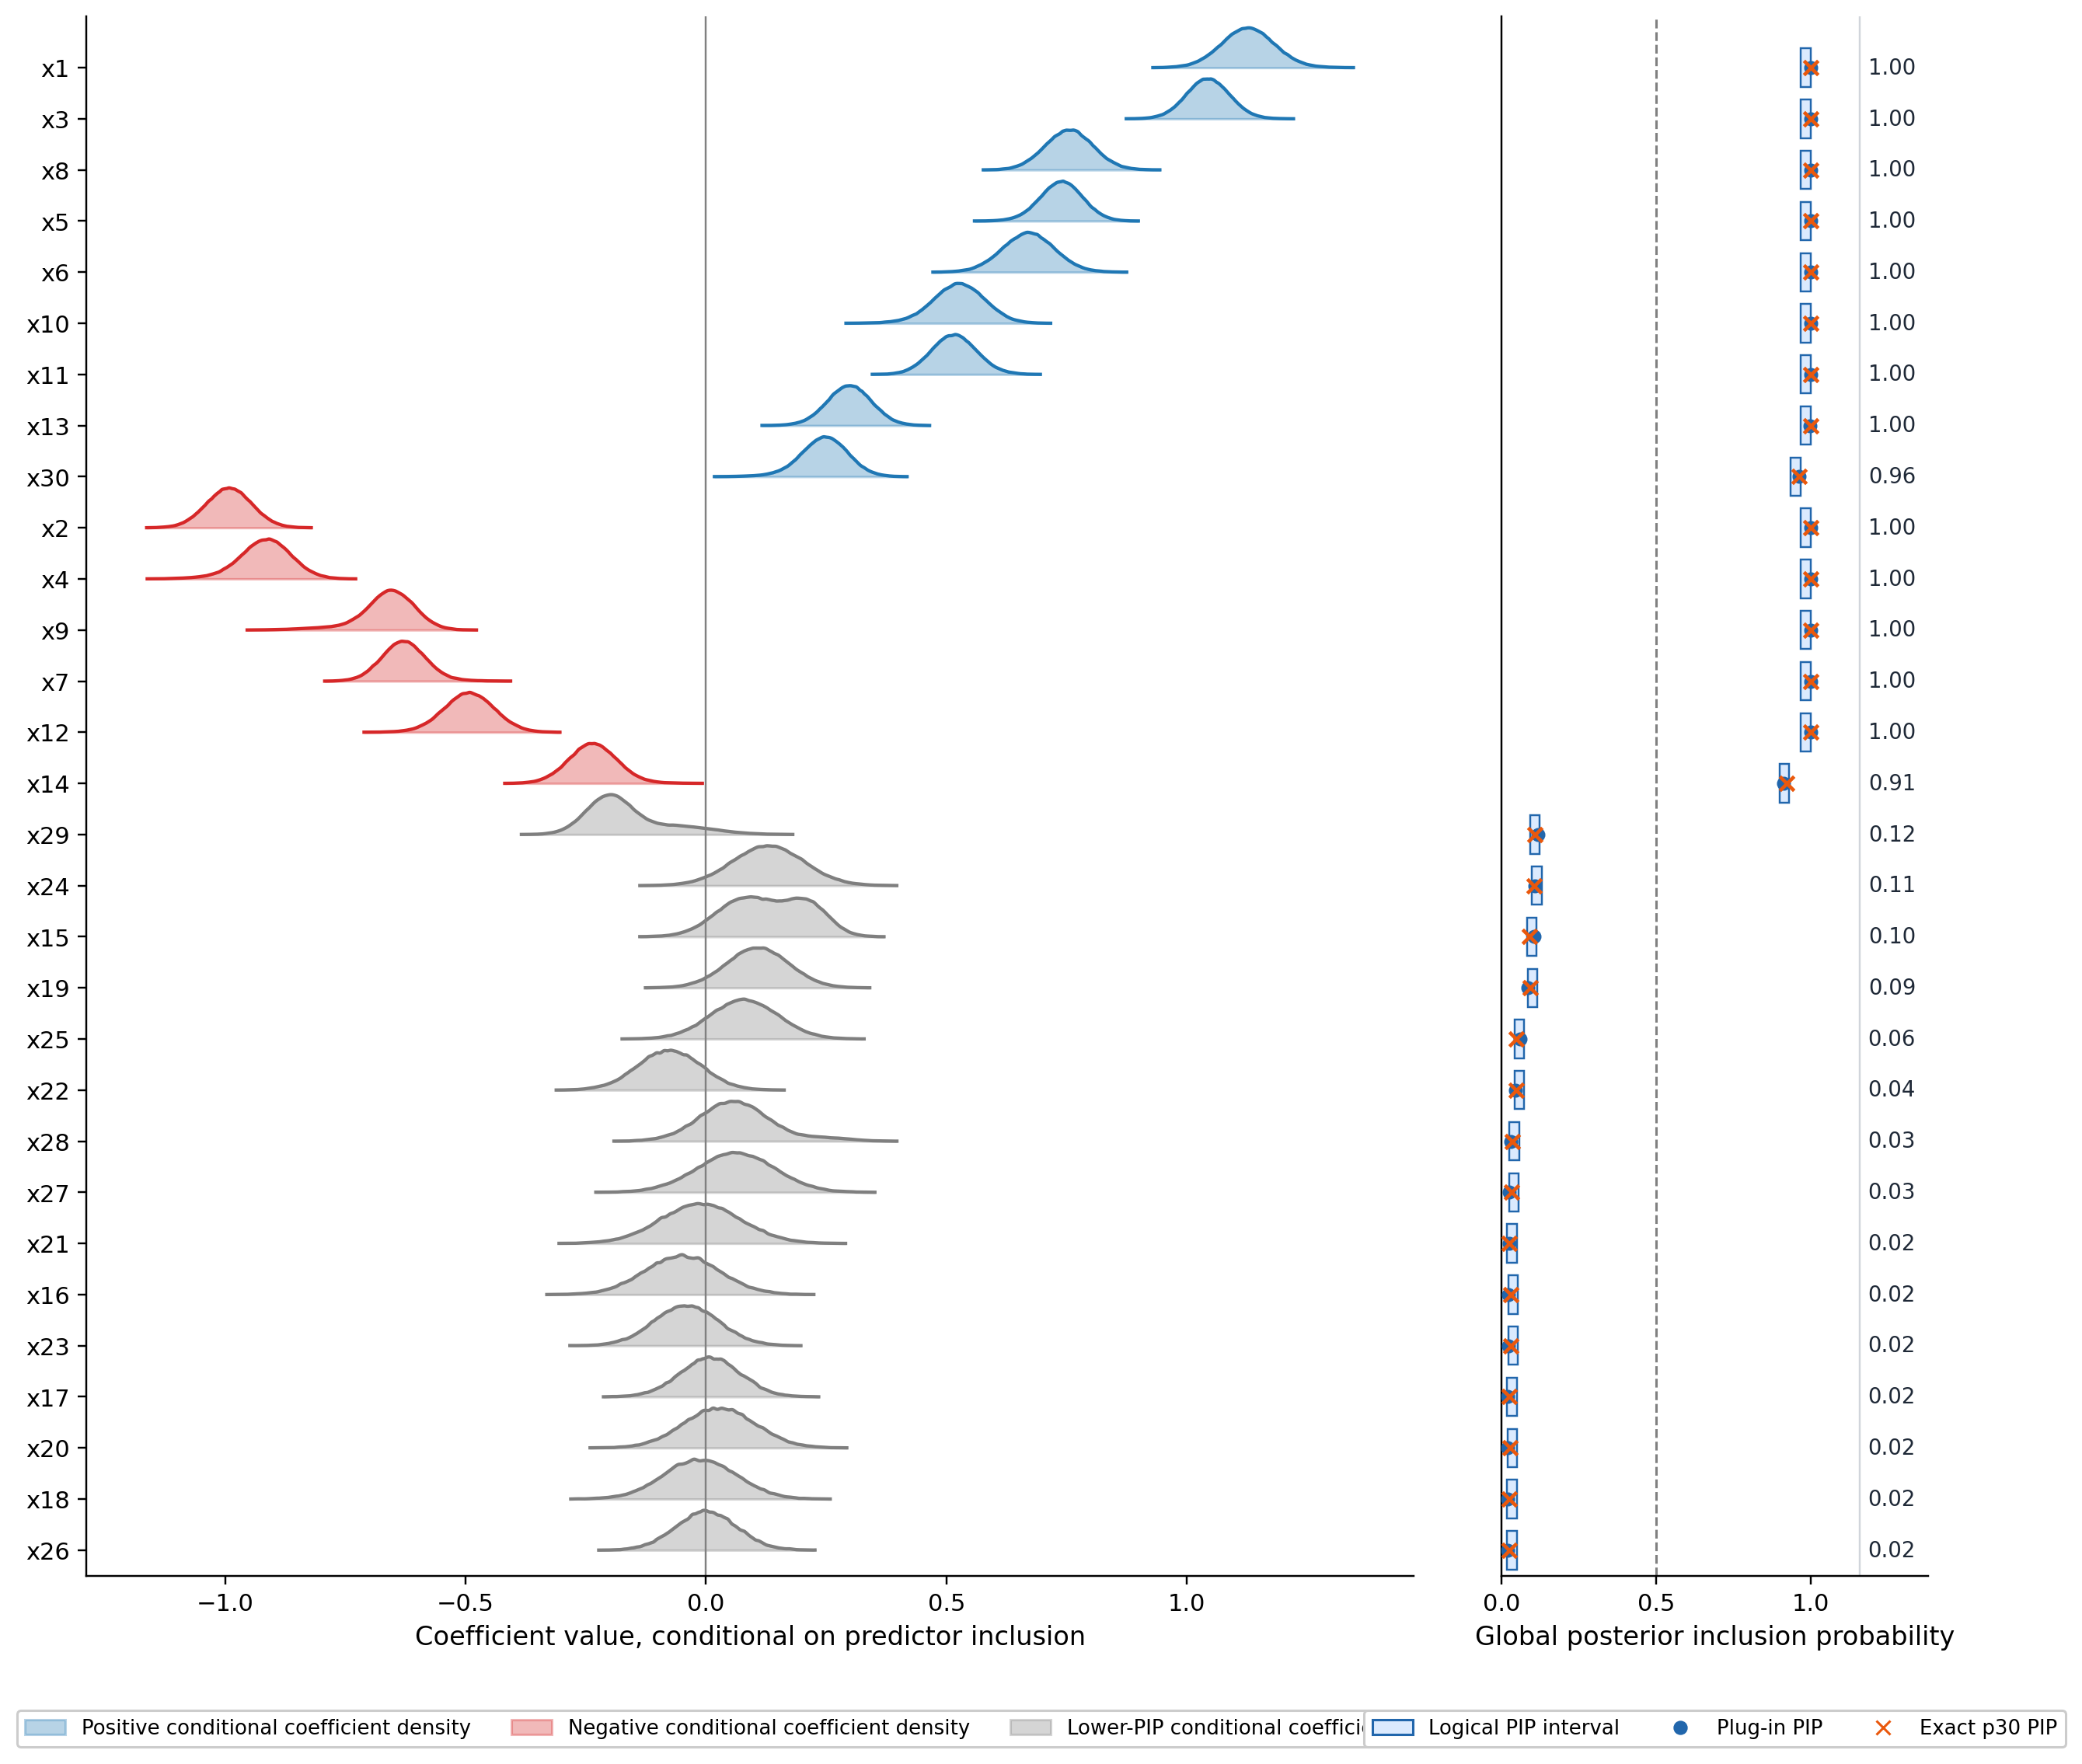

**Notes:** Conditional coefficient distributions in the left panel are reconstructed from the BFG + shell-recovery posterior approximation using the same Zellner g-prior Pass-2 moments as gpubma. Curves condition on predictor inclusion; exclusion atoms at zero are omitted. Ridge heights are normalized to unit peak for display, as in the canonical exact figure. The right sidebar reports logical minimum/maximum PIP intervals together with shell-weighted plug-in PIPs. Exact p30 PIPs are shown only as orange benchmark markers; no exact coefficient-density artifact is used.


Saved figure:
/content/outputs/shell_recovery/canonical_figures/11_bfg_recovery_coefficient_structure.png

Saved table:
/content/outputs/shell_recovery/canonical_figures/11_bfg_recovery_coefficient_structure.csv

Pass-2 coefficient artifact:
/content/outputs/shell_recovery/pass2_coefficients/coefficient_densities_bfg_recovery.npz

Pass-2 reconstruction:
  posterior model draws: 2,000,000
  df_resid: 1999
  g: 2000.000000

Density validation:
  integral range: [1.000000, 1.000000]
  max |curve mean - MC mean|: 0.00007927

PIP display formatting:
  labels rounded to 2 decimals
  separator retained at x = 1.16
  numeric column moved to x = 1.34
  right-panel legend placed below the panel


In [27]:
# ============================================================
# BFG + SHELL-RECOVERY COEFFICIENT STRUCTURE
#
# Updated design:
#   - right-panel PIP numbers rounded to 2 decimals
#   - numbers shown in a fixed right-hand vertical column
#   - separator line retained
#   - numeric column moved farther right
#   - right-panel legend moved below the panel
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from scipy.integrate import trapezoid

from matplotlib.patches import Patch
from matplotlib.lines import Line2D

from IPython.display import (
    display,
    Markdown,
    Image,
)


# ============================================================
# Canonical colors
# ============================================================

BLUE = "#2166ac"
RED = "#b2182b"
ORANGE = "#ea580c"

POSITIVE_COLOR = "#1f77b4"
NEGATIVE_COLOR = "#d62728"
GRAY_COLOR = "#7f7f7f"


# ============================================================
# Paths
# ============================================================

FIG_DIR = (
    OUTPUT_DIR
    / "canonical_figures"
)

FIG_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


PASS2_DIR = (
    OUTPUT_DIR
    / "pass2_coefficients"
)


DENSITY_PATH = (
    PASS2_DIR
    / "coefficient_densities_bfg_recovery.npz"
)


SUMMARY_PATH = (
    PASS2_DIR
    / "coefficient_summary_bfg_recovery.csv"
)


FIG_PATH = (
    FIG_DIR
    / "11_bfg_recovery_coefficient_structure.png"
)


TABLE_PATH = (
    FIG_DIR
    / "11_bfg_recovery_coefficient_structure.csv"
)


# ============================================================
# Requirements
# ============================================================

required_objects = [
    "pip_plugin",
    "pip_lower",
    "pip_upper",
    "candidate_names",
]


missing = [
    name
    for name in required_objects
    if name not in globals()
]


if missing:

    raise RuntimeError(
        "Run the corrected BFG/recovery PIP cell first. "
        "Missing objects: "
        + ", ".join(
            missing
        )
    )


candidate_names = list(
    candidate_names
)


P = len(
    candidate_names
)


pip_plugin = np.asarray(
    pip_plugin,
    dtype=np.float64,
)


pip_lower = np.asarray(
    pip_lower,
    dtype=np.float64,
)


pip_upper = np.asarray(
    pip_upper,
    dtype=np.float64,
)


if not (
    len(pip_plugin)
    == len(pip_lower)
    == len(pip_upper)
    == P
):

    raise RuntimeError(
        "PIP vectors do not all have length P."
    )


# ============================================================
# 1. Load BFG + recovery Pass-2 coefficient artifact
# ============================================================

if not DENSITY_PATH.is_file():

    raise FileNotFoundError(
        "Pass-2 coefficient artifact not found:\n"
        f"{DENSITY_PATH}\n\n"
        "Run the BFG + shell-recovery coefficient Pass-2 cell first."
    )


with np.load(
    DENSITY_PATH,
    allow_pickle=False,
) as density:

    grid = np.asarray(
        density[
            "grid"
        ],
        dtype=np.float64,
    )


    curves = np.asarray(
        density[
            "conditional_density"
        ],
        dtype=np.float64,
    )


    conditional_mean_saved = np.asarray(
        density[
            "conditional_mean"
        ],
        dtype=np.float64,
    )


    conditional_sd_saved = np.asarray(
        density[
            "conditional_sd"
        ],
        dtype=np.float64,
    )


    pip_plugin_saved = np.asarray(
        density[
            "pip_plugin"
        ],
        dtype=np.float64,
    )


    pip_lower_saved = np.asarray(
        density[
            "pip_lower"
        ],
        dtype=np.float64,
    )


    pip_upper_saved = np.asarray(
        density[
            "pip_upper"
        ],
        dtype=np.float64,
    )


    df_resid_pass2 = int(
        density[
            "df_resid"
        ]
    )


    g_pass2 = float(
        density[
            "g"
        ]
    )


    model_draws_pass2 = int(
        density[
            "model_draws"
        ]
    )


# ============================================================
# 2. Artifact audit
# ============================================================

if grid.shape != (
    P,
    257,
):

    raise RuntimeError(
        f"Unexpected Pass-2 grid shape: {grid.shape}. "
        f"Expected {(P, 257)}."
    )


if curves.shape != (
    P,
    257,
):

    raise RuntimeError(
        f"Unexpected Pass-2 density shape: {curves.shape}. "
        f"Expected {(P, 257)}."
    )


np.testing.assert_allclose(
    pip_plugin_saved,
    pip_plugin,
    rtol=0.0,
    atol=1e-12,
)


np.testing.assert_allclose(
    pip_lower_saved,
    pip_lower,
    rtol=0.0,
    atol=1e-12,
)


np.testing.assert_allclose(
    pip_upper_saved,
    pip_upper,
    rtol=0.0,
    atol=1e-12,
)


density_integrals = np.array(
    [
        trapezoid(
            curves[j],
            grid[j],
        )
        for j in range(
            P
        )
    ],
    dtype=np.float64,
)


if not np.allclose(
    density_integrals,
    1.0,
    rtol=0.0,
    atol=0.02,
):

    raise RuntimeError(
        "Some Pass-2 conditional coefficient densities "
        "do not integrate approximately to one."
    )


signed = trapezoid(
    grid
    * curves,
    grid,
    axis=1,
)


mean_curve_difference = (
    signed
    - conditional_mean_saved
)


print(
    "Pass-2 artifact:"
)

print(
    DENSITY_PATH
)

print()

print(
    "Coefficient-density audit:"
)

print(
    "  grid shape:",
    grid.shape,
)

print(
    "  curve shape:",
    curves.shape,
)

print(
    "  density integral range:",
    f"[{density_integrals.min():.6f}, "
    f"{density_integrals.max():.6f}]",
)

print(
    "  max |curve mean - MC mean|:",
    f"{np.max(np.abs(mean_curve_difference)):.6e}",
)

print(
    "  Pass-2 model draws:",
    f"{model_draws_pass2:,}",
)

print(
    "  df_resid:",
    df_resid_pass2,
)

print(
    "  g:",
    f"{g_pass2:.6f}",
)


# ============================================================
# 3. Exact p30 PIP benchmark
# ============================================================

exact_pip = None


exact_pip_path = (
    EXACT_REF_DIR
    / "exact_global_pips.csv"
)


if exact_pip_path.is_file():

    exact_pip_df = pd.read_csv(
        exact_pip_path
    )


    name_col = None

    for candidate in [
        "predictor",
        "variable",
        "name",
    ]:

        if candidate in exact_pip_df.columns:

            name_col = candidate
            break


    pip_col = None

    for candidate in [
        "exact_global_pip",
        "exact_pip",
        "pip",
    ]:

        if candidate in exact_pip_df.columns:

            pip_col = candidate
            break


    if (
        name_col is not None
        and pip_col is not None
    ):

        exact_pip_map = dict(
            zip(
                exact_pip_df[
                    name_col
                ].astype(
                    str
                ),

                exact_pip_df[
                    pip_col
                ].astype(
                    float
                ),
            )
        )


        exact_pip = np.array(
            [
                exact_pip_map[
                    name
                ]
                for name
                in candidate_names
            ],
            dtype=np.float64,
        )


# ============================================================
# 4. Estimated coefficient ordering
# ============================================================

positive = sorted(
    [
        j
        for j in range(
            P
        )
        if (
            pip_plugin[
                j
            ] >= 0.5
            and signed[
                j
            ] >= 0
        )
    ],
    key=lambda j: (
        -signed[
            j
        ],
        j,
    ),
)


negative = sorted(
    [
        j
        for j in range(
            P
        )
        if (
            pip_plugin[
                j
            ] >= 0.5
            and signed[
                j
            ] < 0
        )
    ],
    key=lambda j: (
        signed[
            j
        ],
        j,
    ),
)


gray = sorted(
    [
        j
        for j in range(
            P
        )
        if pip_plugin[
            j
        ] < 0.5
    ],
    key=lambda j: (
        -pip_plugin[
            j
        ],
        j,
    ),
)


coefficient_order = (
    positive
    + negative
    + gray
)


assert len(
    coefficient_order
) == P


assert len(
    set(
        coefficient_order
    )
) == P


print()

print(
    "Estimated coefficient blocks:"
)

print(
    "  blue:",
    [
        candidate_names[
            j
        ]
        for j
        in positive
    ],
)

print(
    "  red:",
    [
        candidate_names[
            j
        ]
        for j
        in negative
    ],
)

print(
    "  gray:",
    [
        candidate_names[
            j
        ]
        for j
        in gray
    ],
)


# ============================================================
# 5. Validate logical PIP intervals
# ============================================================

pip_width = (
    pip_upper
    - pip_lower
)


if not np.allclose(
    pip_width,
    pip_width[
        0
    ],
    rtol=0.0,
    atol=1e-10,
):

    raise RuntimeError(
        "Logical PIP intervals do not share "
        "a common width."
    )


plugin_inside = (
    (
        pip_plugin
        >= pip_lower
        - 1e-10
    )
    &
    (
        pip_plugin
        <= pip_upper
        + 1e-10
    )
)


if not np.all(
    plugin_inside
):

    raise RuntimeError(
        "Some plug-in PIPs lie outside "
        "their logical bounds."
    )


if exact_pip is not None:

    exact_inside = (
        (
            exact_pip
            >= pip_lower
            - 1e-10
        )
        &
        (
            exact_pip
            <= pip_upper
            + 1e-10
        )
    )

else:

    exact_inside = None


# ============================================================
# 6. Save supporting table
# ============================================================

table_dict = {
    "predictor":
        [
            candidate_names[
                j
            ]
            for j
            in coefficient_order
        ],

    "conditional_mean_from_curve":
        signed[
            coefficient_order
        ],

    "conditional_mean_MC":
        conditional_mean_saved[
            coefficient_order
        ],

    "conditional_sd_MC":
        conditional_sd_saved[
            coefficient_order
        ],

    "PIP_logical_min":
        pip_lower[
            coefficient_order
        ],

    "PIP_plugin":
        pip_plugin[
            coefficient_order
        ],

    "PIP_logical_max":
        pip_upper[
            coefficient_order
        ],
}


if exact_pip is not None:

    table_dict[
        "PIP_exact_p30"
    ] = (
        exact_pip[
            coefficient_order
        ]
    )


coef_table = pd.DataFrame(
    table_dict
)


coef_table.to_csv(
    TABLE_PATH,
    index=False,
)


# ============================================================
# 7. Plot
# ============================================================

plt.rcParams.update(
    {
        "font.family":
            "DejaVu Sans",

        "font.size":
            10,

        "axes.titlesize":
            13,

        "axes.labelsize":
            11,

        "axes.spines.top":
            False,

        "axes.spines.right":
            False,
    }
)


fig, (
    ax,
    side,
) = plt.subplots(
    1,
    2,
    figsize=(
        13.9,
        12,
    ),
    sharey=True,
    gridspec_kw={
        "width_ratios":
            [
                5.6,
                1.8,
            ],

        "wspace":
            0.10,
    },
)


# ============================================================
# LEFT PANEL
# ============================================================

for row, j in enumerate(
    coefficient_order
):

    y = (
        P - 1 - row
    )


    x = (
        grid[
            j
        ]
    )


    d = (
        curves[
            j
        ]
        .copy()
    )


    if d.max() > 0:

        d_display = (
            d
            / d.max()
            * 0.78
        )

    else:

        d_display = (
            d
        )


    if pip_plugin[
        j
    ] < 0.5:

        color = (
            GRAY_COLOR
        )

    elif signed[
        j
    ] >= 0:

        color = (
            POSITIVE_COLOR
        )

    else:

        color = (
            NEGATIVE_COLOR
        )


    ax.fill_between(
        x,
        y,
        y
        + d_display,
        color=color,
        alpha=0.32,
    )


    ax.plot(
        x,
        y
        + d_display,
        color=color,
        lw=1.4,
    )


ax.axvline(
    0,
    color="gray",
    lw=0.8,
)


ax.set(
    yticks=range(
        P
    ),

    yticklabels=[
        candidate_names[
            j
        ]
        for j
        in coefficient_order[
            ::-1
        ]
    ],

    xlabel=(
        "Coefficient value, "
        "conditional on predictor inclusion"
    ),

    ylim=(
        -0.5,
        P,
    ),
)


# ============================================================
# RIGHT PANEL
# ============================================================

y_positions = np.arange(
    P - 1,
    -1,
    -1,
)


lower_ord = (
    pip_lower[
        coefficient_order
    ]
)


plugin_ord = (
    pip_plugin[
        coefficient_order
    ]
)


upper_ord = (
    pip_upper[
        coefficient_order
    ]
)


# Logical PIP interval
side.barh(
    y_positions,
    upper_ord
    - lower_ord,
    left=lower_ord,
    height=0.75,
    facecolor="#dbeafe",
    edgecolor=BLUE,
    linewidth=0.8,
)


# Plug-in PIP
side.scatter(
    plugin_ord,
    y_positions,
    color=BLUE,
    s=24,
    zorder=3,
)


# Exact p30 benchmark
if exact_pip is not None:

    exact_ord = (
        exact_pip[
            coefficient_order
        ]
    )


    side.scatter(
        exact_ord,
        y_positions,
        marker="x",
        color=ORANGE,
        s=36,
        linewidths=1.5,
        zorder=4,
    )


# ------------------------------------------------------------
# Axis + reserved numerical column
# ------------------------------------------------------------

side.set(
    xlim=(
        0,
        1.38,
    ),

    xlabel=(
        "Global posterior inclusion probability"
    ),
)


side.set_xticks(
    [
        0.0,
        0.5,
        1.0,
    ]
)


side.axvline(
    0.5,
    color="gray",
    ls="--",
    lw=1,
)


# Separator between probability graph and numeric PIP column
PIP_SEPARATOR_X = 1.16

side.axvline(
    PIP_SEPARATOR_X,
    color="#d1d5db",
    lw=0.8,
)


side.tick_params(
    axis="y",
    left=False,
    labelleft=False,
)


# ============================================================
# Fixed right-side numeric PIP column
#
# Keep the separator, but move the numbers farther right.
# ============================================================

PIP_LABEL_X = 1.34


for y, value in zip(
    y_positions,
    plugin_ord,
):

    side.text(
        PIP_LABEL_X,
        y,
        f"{value:.2f}",
        va="center",
        ha="right",
        fontsize=9,
        color="#1f2937",
        clip_on=False,
    )


# ============================================================
# Bottom legends
# ============================================================

left_legend_handles = [
    Patch(
        facecolor=POSITIVE_COLOR,
        edgecolor=POSITIVE_COLOR,
        alpha=0.32,
        label=(
            "Positive conditional coefficient density"
        ),
    ),

    Patch(
        facecolor=NEGATIVE_COLOR,
        edgecolor=NEGATIVE_COLOR,
        alpha=0.32,
        label=(
            "Negative conditional coefficient density"
        ),
    ),

    Patch(
        facecolor=GRAY_COLOR,
        edgecolor=GRAY_COLOR,
        alpha=0.32,
        label=(
            "Lower-PIP conditional coefficient density"
        ),
    ),
]


right_legend_handles = [
    Patch(
        facecolor="#dbeafe",
        edgecolor=BLUE,
        label=(
            "Logical PIP interval"
        ),
    ),

    Line2D(
        [],
        [],
        marker="o",
        color=BLUE,
        linestyle="None",
        markersize=5,
        label=(
            "Plug-in PIP"
        ),
    ),
]


if exact_pip is not None:

    right_legend_handles.append(
        Line2D(
            [],
            [],
            marker="x",
            color=ORANGE,
            linestyle="None",
            markersize=6,
            label=(
                "Exact p30 PIP"
            ),
        )
    )


ax.legend(
    handles=left_legend_handles,
    loc="upper center",
    bbox_to_anchor=(
        0.50,
        -0.08,
    ),
    ncol=3,
    fontsize=8.5,
    framealpha=1,
)


side.legend(
    handles=right_legend_handles,
    loc="upper center",
    bbox_to_anchor=(
        0.50,
        -0.08,
    ),
    ncol=len(
        right_legend_handles
    ),
    fontsize=8.5,
    framealpha=1,
)


fig.subplots_adjust(
    bottom=0.12
)


# ============================================================
# Save
# ============================================================

fig.savefig(
    FIG_PATH,
    dpi=220,
    bbox_inches="tight",
    facecolor="white",
)


plt.close(
    fig
)


# ============================================================
# Display
# ============================================================

display(
    Markdown(
        "### BFG + shell-recovery coefficient structure"
    )
)


display(
    Image(
        filename=str(
            FIG_PATH
        )
    )
)


display(
    Markdown(
        "**Notes:** Conditional coefficient distributions in the "
        "left panel are reconstructed from the BFG + shell-recovery "
        "posterior approximation using the same Zellner g-prior "
        "Pass-2 moments as gpubma. Curves condition on predictor "
        "inclusion; exclusion atoms at zero are omitted. Ridge heights "
        "are normalized to unit peak for display, as in the canonical "
        "exact figure. The right sidebar reports logical minimum/maximum "
        "PIP intervals together with shell-weighted plug-in PIPs. "
        "Exact p30 PIPs are shown only as orange benchmark markers; "
        "no exact coefficient-density artifact is used."
    )
)


# ============================================================
# Final audit
# ============================================================

print()

print(
    "Saved figure:"
)

print(
    FIG_PATH
)


print()

print(
    "Saved table:"
)

print(
    TABLE_PATH
)


print()

print(
    "Pass-2 coefficient artifact:"
)

print(
    DENSITY_PATH
)


print()

print(
    "Pass-2 reconstruction:"
)

print(
    "  posterior model draws:",
    f"{model_draws_pass2:,}",
)

print(
    "  df_resid:",
    df_resid_pass2,
)

print(
    "  g:",
    f"{g_pass2:.6f}",
)


print()

print(
    "Density validation:"
)

print(
    "  integral range:",
    f"[{density_integrals.min():.6f}, "
    f"{density_integrals.max():.6f}]",
)

print(
    "  max |curve mean - MC mean|:",
    f"{np.max(np.abs(mean_curve_difference)):.8f}",
)


print()

print(
    "PIP display formatting:"
)

print(
    "  labels rounded to 2 decimals"
)

print(
    "  separator retained at x =",
    f"{PIP_SEPARATOR_X:.2f}",
)

print(
    "  numeric column moved to x =",
    f"{PIP_LABEL_X:.2f}",
)

print(
    "  right-panel legend placed below the panel"
)

## 23. GPU cleanup

Release cached CUDA memory after all benchmark outputs have been generated.


In [28]:
# ============================================================
# GPU CLEANUP / VRAM FLUSH
# ============================================================

import gc

# ------------------------------------------------------------
# 1. Delete large GPU-side objects that are no longer needed
# ------------------------------------------------------------

for name in [
    # scorers / engines
    "recovery_base_scorer",
    "scorer",
    "bfg_scorer",

    # possible torch tensors / GPU workspaces
    "Zxx_gpu",
    "Zxy_gpu",
    "X_gpu",
    "y_gpu",
    "scores_gpu",
    "masks_gpu",
    "idx_gpu",

    # temporary model-space objects
    "support_masks_gpu",
    "support_scores_gpu",
]:
    if name in globals():
        try:
            del globals()[name]
            print("Deleted:", name)
        except Exception as e:
            print("Could not delete", name, ":", e)


# ------------------------------------------------------------
# 2. Python garbage collection
# ------------------------------------------------------------

collected = gc.collect()

print()
print("Python objects collected:", collected)


# ------------------------------------------------------------
# 3. Flush PyTorch CUDA cache
# ------------------------------------------------------------

try:
    import torch

    if torch.cuda.is_available():

        torch.cuda.synchronize()

        allocated_before = torch.cuda.memory_allocated()
        reserved_before = torch.cuda.memory_reserved()

        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

        torch.cuda.synchronize()

        allocated_after = torch.cuda.memory_allocated()
        reserved_after = torch.cuda.memory_reserved()

        print()
        print("CUDA memory:")
        print(
            "  allocated before:",
            f"{allocated_before / 2**30:.3f} GiB"
        )
        print(
            "  reserved before :",
            f"{reserved_before / 2**30:.3f} GiB"
        )
        print(
            "  allocated after :",
            f"{allocated_after / 2**30:.3f} GiB"
        )
        print(
            "  reserved after  :",
            f"{reserved_after / 2**30:.3f} GiB"
        )

        print()
        print(torch.cuda.memory_summary(abbreviated=True))

    else:
        print("CUDA is not available.")

except ImportError:
    print("PyTorch is not loaded.")

Deleted: recovery_base_scorer

Python objects collected: 6785

CUDA memory:
  allocated before: 0.008 GiB
  reserved before : 13.521 GiB
  allocated after : 0.008 GiB
  reserved after  : 0.021 GiB

|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 0            |        cudaMalloc retries: 0         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      |   8336 KiB |   1610 MiB |    881 GiB |    881 GiB |
|---------------------------------------------------------------------------|
| Active memory         |   8336 KiB |   1610 MiB |    881 GiB |    881 GiB |
|---------------------

In [29]:
import importlib.metadata as md
import json
from pathlib import Path

dist = md.distribution("gpubma")

direct_url = dist.read_text("direct_url.json")

print(direct_url)

info = json.loads(direct_url)

commit_sha = (
    info
    .get("vcs_info", {})
    .get("commit_id")
)

print()
print("Installed gpubma commit:")
print(commit_sha)

{"url": "https://github.com/Favioleiva/gpubma.git", "vcs_info": {"commit_id": "be6437911f35964bfe56b0974008d12ae366c7c6", "requested_revision": "be6437911f35964bfe56b0974008d12ae366c7c6", "vcs": "git"}}

Installed gpubma commit:
be6437911f35964bfe56b0974008d12ae366c7c6
